# Analisis Coordination Pattern pada Komentar TikTok Produk Skincare
## Rumusan Masalah 1 — Pemetaan Pola Koordinasi melalui Latent Coordination Network (LCN)

**Referensi metodologi:** Weber & Neumann (2021). *Amplifying influence through coordinated behaviour in social networks*. Social Network Analysis and Mining, 11(1), 1–42.

---

Notebook ini menggunakan dua level jaringan: **Latent Coordination Network (LCN)** dan **Highly
Coordinating Communities (HCC)**. LCN merepresentasikan seluruh hubungan koordinasi yang diperoleh dari
proses evidence filtering dan pembobotan. HCC merupakan komunitas dengan tingkat koordinasi tertinggi
yang diekstraksi dari LCN menggunakan Focal Structures Analysis Variant (FSA_V).

**Cakupan analisis:**
- Membangun Latent Coordination Network (LCN) dari tiga evidence koordinasi: **Co-conv**, **Co-reply**, dan **Co-temporal**
- Evidence dinormalisasi menggunakan Min-Max Normalization sebelum digabung (Han et al., 2012; OECD, 2008)
- Mengekstrak Highly Coordinating Communities (HCC) menggunakan Louvain community detection
- Menghitung Focal Structures Analysis (FSA) untuk mengidentifikasi komunitas paling terkoordinasi
- Mengkarakterisasi komunitas menggunakan Co-hashtag (asosiasi konteks brand/video) dan Co-similarity (kesamaan narasi komentar) — evidence pendukung, tidak mempengaruhi LCN. Co-Mention **dipensiunkan** dari analisis aktif (lihat Section 16.2) karena tidak informatif pada dataset TikTok ini.
- Membuat label brand HCC otomatis berdasarkan hashtag metadata video (Section 16.1.3), tanpa mapping manual

**Batasan analisis:**
- Notebook ini hanya mengidentifikasi *pola koordinasi* dan *komunitas dengan indikasi koordinatif*
- Tidak ada kesimpulan mengenai astroturfing, identifikasi bot, klasifikasi aktor, sentimen, atau strategi intervensi
- HCC (koordinasi struktural), brand label (konteks video), dan Co-similarity (kesamaan narasi) adalah tiga lapis bukti yang terpisah — lihat Section 19.11 untuk model interpretasi lengkap

---
## 1. Import Library

**Tujuan:** Mengimpor seluruh library yang diperlukan dalam pipeline analisis.  
**Input:** —  
**Output:** Library siap pakai; versi library ditampilkan untuk reproduksibilitas.


In [1]:
# Repository path bootstrap (static refactor; no analysis is run here)
from pathlib import Path
import sys


def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "README.md").exists() and (candidate / "dataset.csv").exists() and (candidate / "scripts").exists():
            return candidate
    raise RuntimeError("Project root tidak ditemukan. Jalankan notebook dari dalam repository Analisis-Astroturfing.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.project_paths import (
    DATASET_PATH,
    VIDEO_METADATA_PATH,
    RM1_TABLES_DIR,
    RM1_GEPHI_DIR,
    RM1_VISUALIZATION_DIR,
    RM1_TEMPORAL_DIR,
    RM1_TEMPORAL_TABLES_DIR,
    RM1_TEMPORAL_VISUALIZATION_DIR,
    RM2_SENTIMENT_FINAL_DIR,
)

RUN_MODE = "reproduce_rm1"
for directory in (
    RM1_TABLES_DIR,
    RM1_GEPHI_DIR,
    RM1_VISUALIZATION_DIR,
    RM1_TEMPORAL_TABLES_DIR,
    RM1_TEMPORAL_VISUALIZATION_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH:", DATASET_PATH)
print("RM1 output:", RM1_TABLES_DIR)
print("RUN_MODE:", RUN_MODE)


PROJECT_ROOT: D:\UNHAS\PKM-RSH\Pendanaan\Analisis 4
DATASET_PATH: D:\UNHAS\PKM-RSH\Pendanaan\Analisis 4\dataset.csv
RM1 output: D:\UNHAS\PKM-RSH\Pendanaan\Analisis 4\output\tables
RUN_MODE: reproduce_rm1


In [2]:
# ── Standard library ────────────────────────────────────────────────────────
import os
import sys
import warnings
import itertools
import re
from collections import defaultdict

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Network analysis ──────────────────────────────────────────────────────────
import networkx as nx
import networkx.algorithms.community as nx_community

# ── Machine learning / NLP ────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Progress bar ──────────────────────────────────────────────────────────────
from tqdm.auto import tqdm

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns

# ── python-louvain (opsional; fallback ke NetworkX built-in) ─────────────────
try:
    import community as community_louvain
    LOUVAIN_LIB = 'python-louvain'
except ImportError:
    community_louvain = None
    LOUVAIN_LIB = 'networkx'

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 5)})
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
RM1_TABLES_DIR.mkdir(parents=True, exist_ok=True)
RM1_GEPHI_DIR.mkdir(parents=True, exist_ok=True)

print(f'Python      : {sys.version.split()[0]}')
print(f'Pandas      : {pd.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'NetworkX    : {nx.__version__}')
print(f'Louvain lib : {LOUVAIN_LIB}')
print(f'\n✓ Semua library berhasil diimpor.')
print(f'✓ Direktori output/tables/ dan output/gephi/ dibuat.')

# ── Verifikasi determinisme Community Detection & FSA_V/HCC (Section 11-12) ─
# RIWAYAT: sebelumnya diduga determinisme bergantung sepenuhnya pada
# PYTHONHASHSEED, karena hasil HCC (Section 12) tampak berbeda-beda setiap
# restart kernel walau seed=42 pada Louvain tetap. Investigasi akar masalah
# (isolasi bertahap: partisi Louvain di-pickle & dibandingkan lintas proses)
# MEMBUKTIKAN partisi Louvain itu sendiri 100% stabil/identik lintas proses --
# bukan itu sumber masalahnya. Sumber sebenarnya: `graph.subgraph(members)
# .edges(data=True)` pada NetworkX bisa mengembalikan edge undirected yang SAMA
# dengan orientasi (u, v) TERTUKAR antar proses (akibat operasi set internal
# NetworkX atas label node string, yang urutannya dipengaruhi hash randomization
# Python per-proses) -- sehingga tie-break `_heaviest_edge` (Section 12) yang
# sebelumnya memakai (weight, e[0], e[1]) apa adanya bisa memilih edge pemenang
# BERBEDA saat dua edge memiliki weight yang sama persis (sering terjadi di LCN
# ini). `_heaviest_edge` sudah diperbaiki memakai key
# (weight, min(u,v), max(u,v)) yang invarian terhadap orientasi edge, sehingga
# hasil FSA_V/HCC sekarang deterministik TERLEPAS dari PYTHONHASHSEED, kernel
# yang dipakai, atau apakah kernel.json-nya sempat ter-cache lama oleh IDE.
# Diverifikasi: 6 proses terpisah dengan PYTHONHASHSEED acak (tidak diset)
# menghasilkan HCC yang 100% identik (31 komunitas, 162 node) setelah fix ini.
#
# PYTHONHASHSEED=0 pada kernel.json "main-ds" TETAP dipertahankan sebagai
# lapisan keamanan tambahan (harmless, tidak mengganggu apa pun), namun BUKAN
# LAGI syarat mutlak reproducibility -- karena itu sel ini hanya melaporkan
# nilainya untuk keperluan diagnostik/transparansi, tidak meng-assert atau
# menghentikan eksekusi berdasarkan nilai tersebut.
_phs = os.environ.get('PYTHONHASHSEED')
print(f'\nPYTHONHASHSEED (informasional; lihat catatan determinisme di atas): {_phs!r}')


Python      : 3.12.4
Pandas      : 2.2.3
NumPy       : 1.26.4
NetworkX    : 3.6
Louvain lib : networkx

✓ Semua library berhasil diimpor.
✓ Direktori output/tables/ dan output/gephi/ dibuat.

PYTHONHASHSEED (informasional; lihat catatan determinisme di atas): None


---
## 2. Load Dataset

**Tujuan:** Memuat kedua dataset ke dalam memori.  
**Input:** `dataset.csv` (35.334 baris komentar TikTok), `video_metadata_clean.csv` (55 video)  
**Output:** `df_raw` — DataFrame komentar mentah; `df_meta` — DataFrame metadata video


In [3]:
# ── Path file ─────────────────────────────────────────────────────────────────
# Google Colab: unggah file terlebih dahulu, atau mount Google Drive, lalu
# sesuaikan path di bawah ini.
# Gunakan path kanonis dari scripts.project_paths agar eksekusi nbconvert
# tetap valid walau kernel berjalan dari direktori notebook.
COMMENT_DATASET_PATH = DATASET_PATH
METADATA_PATH = VIDEO_METADATA_PATH

# ── Dtype eksplisit untuk kolom ID (FATAL FIX) ───────────────────────────────
# video_id, comment_id, parent_comment_id, dan user_id adalah ID TikTok
# berukuran besar (~19 digit). Jika dibiarkan terbaca sebagai float64 (default
# pandas), presisi angka hilang dan ID tersimpan dalam notasi ilmiah (mis.
# 7.23738e+18). Karena SELURUH evidence (Co-conv, Co-reply, Co-temporal)
# menghitung "jumlah video bersama" berdasarkan video_id, kehilangan presisi
# ini berisiko menyatukan (melebur) video yang sebenarnya berbeda menjadi
# satu video_id yang sama, dan merusak seluruh perhitungan bobot evidence.
# `username` TIDAK dimasukkan di sini karena edge jaringan dibentuk dari
# `username`, bukan `user_id` -- identitas akun sudah aman.
ID_DTYPES = {
    'video_id'          : str,
    'user_id'           : str,
    'comment_id'        : str,
    'parent_comment_id' : str,
}

# ── Load komentar ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv(COMMENT_DATASET_PATH, low_memory=False, dtype=ID_DTYPES)
print(f'dataset.csv          : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')

# ── Load metadata video ───────────────────────────────────────────────────────
df_meta = pd.read_csv(METADATA_PATH, low_memory=False, dtype={'video_id': str})
print(f'video_metadata_clean : {df_meta.shape[0]:,} baris × {df_meta.shape[1]} kolom')

# ── Diagnostik: verifikasi tidak ada peleburan video_id akibat presisi ───────
print(f'\nVideo_id unik pada dataset.csv (dtype str)            : {df_raw["video_id"].nunique():,}')
print(f'Video_id unik pada video_metadata_clean.csv (dtype str) : {df_meta["video_id"].nunique():,}')
print('Catatan: file CSV sumber sudah menyimpan video_id/comment_id dalam notasi')
print('ilmiah bawaan (mis. "7.23738E+18") sejak sebelum notebook ini dibuat -- presisi')
print('asli 19 digit tidak dapat dipulihkan lagi dari file ini. Membaca sebagai string')
print('(bukan float64) mencegah presisi tersebut turun LEBIH JAUH akibat pembulatan')
print('float64 tambahan pada tahap-tahap pemrosesan berikutnya.')


dataset.csv          : 35,334 baris × 18 kolom


video_metadata_clean : 55 baris × 14 kolom

Video_id unik pada dataset.csv (dtype str)            : 55
Video_id unik pada video_metadata_clean.csv (dtype str) : 55
Catatan: file CSV sumber sudah menyimpan video_id/comment_id dalam notasi
ilmiah bawaan (mis. "7.23738E+18") sejak sebelum notebook ini dibuat -- presisi
asli 19 digit tidak dapat dipulihkan lagi dari file ini. Membaca sebagai string
(bukan float64) mencegah presisi tersebut turun LEBIH JAUH akibat pembulatan
float64 tambahan pada tahap-tahap pemrosesan berikutnya.


---
## 3. Data Understanding

**Tujuan:** Memahami struktur, distribusi, dan kualitas data sebelum preprocessing.  
**Input:** `df_raw`, `df_meta`  
**Output:** Statistik deskriptif dan visualisasi distribusi awal.


In [4]:
# ── Struktur dan tipe data komentar ──────────────────────────────────────────
print('=== STRUKTUR DATASET KOMENTAR ===')
print(f'Kolom : {list(df_raw.columns)}')
print()
display(df_raw.dtypes.to_frame('dtype'))


=== STRUKTUR DATASET KOMENTAR ===
Kolom : ['product_category', 'video_url', 'video_id', 'comment_type', 'comment_id', 'parent_comment_id', 'parent_user', 'reply_count', 'expected_reply_count', 'actual_reply_scraped', 'thread_level', 'user_id', 'username', 'text', 'mentions', 'hashtags', 'timestamp', 'source_file']



,dtype
product_category,object
video_url,object
video_id,object
comment_type,object
comment_id,object
parent_comment_id,object
parent_user,object
reply_count,int64
expected_reply_count,int64
actual_reply_scraped,int64


In [5]:
# ── Statistik dasar ───────────────────────────────────────────────────────────
print('=== STATISTIK DASAR ===')
print(f'  Total komentar          : {len(df_raw):,}')
print(f'  Komentar utama (main)   : {(df_raw["comment_type"]=="main").sum():,}')
print(f'  Komentar balasan (reply): {(df_raw["comment_type"]=="reply").sum():,}')
print(f'  Akun unik               : {df_raw["username"].nunique():,}')
print(f'  Video unik              : {df_raw["video_id"].nunique():,}')
print(f'  Kategori produk         : {df_raw["product_category"].nunique()}')
print()
print('Distribusi per kategori produk:')
display(df_raw['product_category'].value_counts().to_frame('jumlah_komentar'))


=== STATISTIK DASAR ===
  Total komentar          : 35,334
  Komentar utama (main)   : 24,501
  Komentar balasan (reply): 10,833
  Akun unik               : 27,562
  Video unik              : 55
  Kategori produk         : 5

Distribusi per kategori produk:


,jumlah_komentar
product_category,
maryame_niacinamide,16731
daviena_retinol,6118
davina_skincare,5553
originote_niacinamide,4543
azarine_retinol,2389


In [6]:
# ── Missing values ────────────────────────────────────────────────────────────
print('=== MISSING VALUES ===')
mv     = df_raw.isnull().sum()
mv_pct = (mv / len(df_raw) * 100).round(2)
mv_df  = pd.concat([mv, mv_pct], axis=1)
mv_df.columns = ['missing', 'pct (%)']
display(mv_df[mv_df['missing'] > 0])


=== MISSING VALUES ===


,missing,pct (%)
parent_comment_id,24501,69.3400
parent_user,24501,69.3400
text,4,0.0100


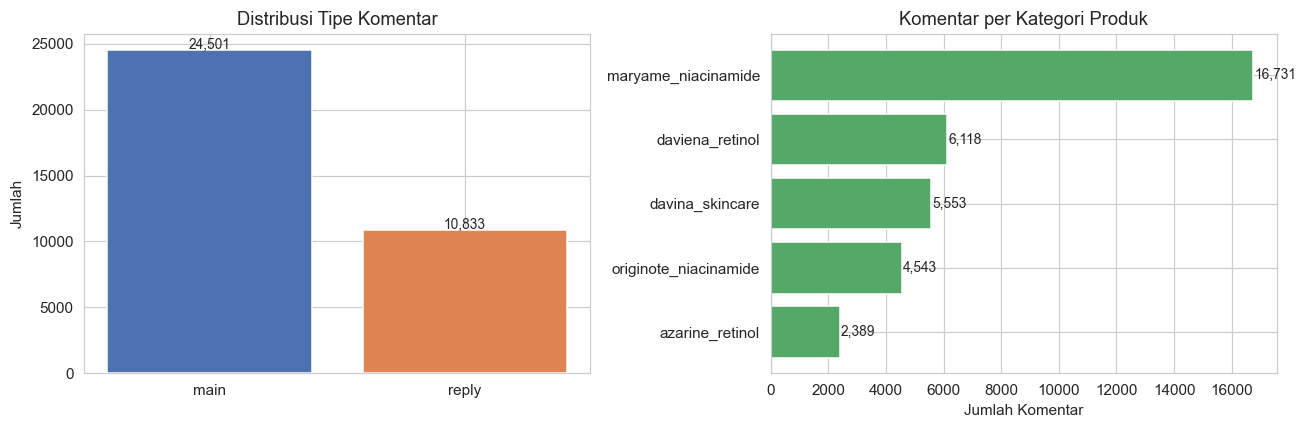

In [7]:
# ── Visualisasi distribusi awal ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel kiri: comment_type
ct = df_raw['comment_type'].value_counts()
axes[0].bar(ct.index, ct.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Distribusi Tipe Komentar')
axes[0].set_ylabel('Jumlah')
for i, (k, v) in enumerate(zip(ct.index, ct.values)):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Panel kanan: komentar per kategori produk
cat_count = df_raw.groupby('product_category').size().sort_values(ascending=True)
axes[1].barh(cat_count.index, cat_count.values, color='#55A868')
axes[1].set_title('Komentar per Kategori Produk')
axes[1].set_xlabel('Jumlah Komentar')
for i, v in enumerate(cat_count.values):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [8]:
# ── Preview data mentah ───────────────────────────────────────────────────────
print('=== PREVIEW 5 BARIS PERTAMA ===')
display(df_raw[['product_category', 'video_id', 'comment_type',
                'username', 'parent_user', 'text', 'timestamp']].head(5))


=== PREVIEW 5 BARIS PERTAMA ===


,product_category,video_id,comment_type,username,parent_user,text,timestamp
0,azarine_retinol,7237379067773766917,main,reviewjujur_cp600,NaN,kak serum retinol complex azarine sama ampoule...,2023-12-17T17:04:42+00:00
1,azarine_retinol,7237379067773766917,reply,ajie.wardhana,holaa_itsmeee,Avoskin for sure!! 🙏,2023-12-18T09:30:29+00:00
2,azarine_retinol,7237379067773766917,reply,sisisinta498,holaa_itsmeee,pasti avoskin cuma gak cocok di kantong harganys,2024-09-27T07:28:07+00:00
3,azarine_retinol,7237379067773766917,reply,eryy622,holaa_itsmeee,Azarine,2024-09-09T16:23:32+00:00
4,azarine_retinol,7237379067773766917,main,skintok_ct62066,NaN,ka aku baru nyoba retinol dan pake yang smooth...,2023-12-17T10:51:44+00:00


In [9]:
# ── Struktur metadata video ───────────────────────────────────────────────────
print('=== STRUKTUR METADATA VIDEO ===')
display(df_meta[['product_category', 'video_id', 'creator',
                  'n_hashtags', 'n_mentions',
                  'view_count', 'like_count', 'comment_count']].head(8))


=== STRUKTUR METADATA VIDEO ===


,product_category,video_id,creator,n_hashtags,n_mentions,view_count,like_count,comment_count
0,azarine_retinol,7.23738E+18,vivianmarguerre,8,1,261300.0000,3961.0000,215.0000
1,azarine_retinol,7.58683E+18,skinby_sindy,5,0,20900.0000,525.0000,205.0000
2,azarine_retinol,7.27012E+18,asabelavvv,2,1,1200000.0000,11300.0000,295.0000
3,azarine_retinol,7.31338E+18,ansyashine,7,0,803900.0000,5823.0000,234.0000
4,azarine_retinol,7.1851E+18,fvajar_,1,1,2300000.0000,67900.0000,1235.0000
5,azarine_retinol,7.39703E+18,skincarebyw,7,1,116000.0000,2834.0000,157.0000
6,azarine_retinol,7.32763E+18,afikarrhnur,5,0,185400.0000,865.0000,196.0000
7,daviena_retinol,7.31203E+18,maharajasp8,7,0,3700000.0000,197300.0000,1210.0000


---
## 4. Data Preprocessing

**Tujuan:** Membersihkan dan menstandardisasi data sebelum analisis koordinasi.  
**Input:** `df_raw`, `df_meta`  
**Output:** `df` — dataset bersih siap analisis; `df_meta_clean` — metadata video bersih.


In [10]:
# ── Salin dan deduplikasi ─────────────────────────────────────────────────────
df     = df_raw.copy()
before = len(df)
df     = df.drop_duplicates(subset='comment_id', keep='first')
print(f'Baris dihapus (duplikasi comment_id) : {before - len(df):,}')

# ── Normalisasi identitas akun ────────────────────────────────────────────────
df['username']    = df['username'].astype(str).str.strip().str.lower()
df['parent_user'] = df['parent_user'].astype(str).str.strip().str.lower()
df['parent_user'] = df['parent_user'].replace({'nan': '', 'none': '', 'NaN': ''})

# ── Normalisasi video_id (string konsisten) ───────────────────────────────────
df['video_id']          = df['video_id'].astype(str)
df_meta_clean           = df_meta.copy()
df_meta_clean['video_id'] = df_meta_clean['video_id'].astype(str)

# ── Konversi timestamp ke datetime UTC ───────────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
print(f'Timestamp tidak valid                : {df["timestamp"].isnull().sum():,}')

# ── Flag baris reply ─────────────────────────────────────────────────────────
df['is_reply'] = (df['parent_user'] != '') & (df['parent_user'].notna())

# ── Isi teks kosong (untuk co-similarity) ────────────────────────────────────
df['text'] = df['text'].fillna('')

# ── Ringkasan dataset bersih ──────────────────────────────────────────────────
print(f'\nDataset bersih       : {len(df):,} baris')
print(f'  - Komentar utama   : {(~df["is_reply"]).sum():,}')
print(f'  - Reply            : {df["is_reply"].sum():,}')
print(f'Akun unik            : {df["username"].nunique():,}')
print(f'Video unik           : {df["video_id"].nunique():,}')


Baris dihapus (duplikasi comment_id) : 0
Timestamp tidak valid                : 59

Dataset bersih       : 35,334 baris
  - Komentar utama   : 24,501
  - Reply            : 10,833
Akun unik            : 27,562
Video unik           : 55


---
## 5. Co-conv Analysis

**Tujuan:** Mengidentifikasi pasangan akun yang muncul bersama pada video yang sama.
**Input:** `df` (kolom `video_id`, `username`)
**Output:** `co_conv_filt` DataFrame; `output/tables/co_conv_edges.csv`

In [11]:
# ── Ringkasan akun per video ─────────────────────────────────────────────────
user_videos  = df.groupby('username')['video_id'].apply(set).to_dict()
multi_users  = sum(1 for vs in user_videos.values() if len(vs) > 1)
print(f'Total akun unik              : {len(user_videos):,}')
print(f'Akun dengan >1 video         : {multi_users:,}')

# ── Hitung co_conv_weight (pasangan per video) ────────────────────────────────
# Untuk setiap video, bentuk semua pasangan unik dari akun yang berkomentar.
video_users       = df.groupby('video_id')['username'].apply(lambda x: sorted(set(x))).to_dict()
co_conv_counter   = defaultdict(int)
co_conv_weight_fx = defaultdict(int)

for vid, users in tqdm(video_users.items(), desc='Co-conv per video'):
    for u, v in itertools.combinations(users, 2):
        co_conv_counter[(u, v)] += 1

for _w in co_conv_counter.values():
    co_conv_weight_fx[_w] += 1

co_conv_raw_edge_count = len(co_conv_counter)
co_conv_raw_weight_min = min(co_conv_weight_fx) if co_conv_weight_fx else 0
co_conv_raw_weight_max = max(co_conv_weight_fx) if co_conv_weight_fx else 0
co_conv_raw_weight_mean = (
    sum(w * c for w, c in co_conv_weight_fx.items()) / co_conv_raw_edge_count
    if co_conv_raw_edge_count else 0.0
)

print(f'\n=== CO-CONV SEBELUM FILTERING ===')
print(f'Total edge          : {co_conv_raw_edge_count:,}')
print(f'weight min–max–mean : {co_conv_raw_weight_min} – '
      f'{co_conv_raw_weight_max} – '
      f'{co_conv_raw_weight_mean:.2f}')

# ── Filtering MIN_CO_CONV = 3 (Perbaikan 2: dinaikkan dari 2 agar Co-conv lebih selektif) ──
MIN_CO_CONV  = 3
co_conv_filt = pd.DataFrame(
    ((u, v, w) for (u, v), w in co_conv_counter.items() if w >= MIN_CO_CONV),
    columns=['source', 'target', 'co_conv_weight']
)

print(f'\n=== CO-CONV SETELAH FILTERING (MIN_CO_CONV = {MIN_CO_CONV}) ===')
print(f'Total edge          : {len(co_conv_filt):,}')
print(f'Edge dipertahankan  : {len(co_conv_filt)/co_conv_raw_edge_count*100:.1f}%')

co_conv_filt.to_csv(RM1_TABLES_DIR / "co_conv_edges.csv", index=False)
print(f'\n✓ Disimpan: output/tables/co_conv_edges.csv')
display(co_conv_filt.sort_values('co_conv_weight', ascending=False).head(10))


Total akun unik              : 27,562
Akun dengan >1 video         : 1,719


Co-conv per video:   0%|          | 0/55 [00:00<?, ?it/s]


=== CO-CONV SEBELUM FILTERING ===
Total edge          : 48,175,308
weight min–max–mean : 1 – 8 – 1.00



=== CO-CONV SETELAH FILTERING (MIN_CO_CONV = 3) ===
Total edge          : 2,393
Edge dipertahankan  : 0.0%

✓ Disimpan: output/tables/co_conv_edges.csv


,source,target,co_conv_weight
1084,glowhunter_ip8756,kulitglowing_ip334,8
173,reviewjujur_ip2228,skinlover_ip4667,8
185,skinbestie_ip1027,skincare_ip7443,8
186,skinbestie_ip1027,skinclub_ip8942,8
187,skinbestie_ip1027,skinlover_ip4667,8
700,dearskin_ct58033,skincare_ct87875,8
196,skincare_ip7443,skinclub_ip8942,8
197,skincare_ip7443,skinlover_ip4667,8
202,skinclub_ip8942,skinlover_ip4667,8
466,skinbestie_ip5105,skinclub_ip4711,8


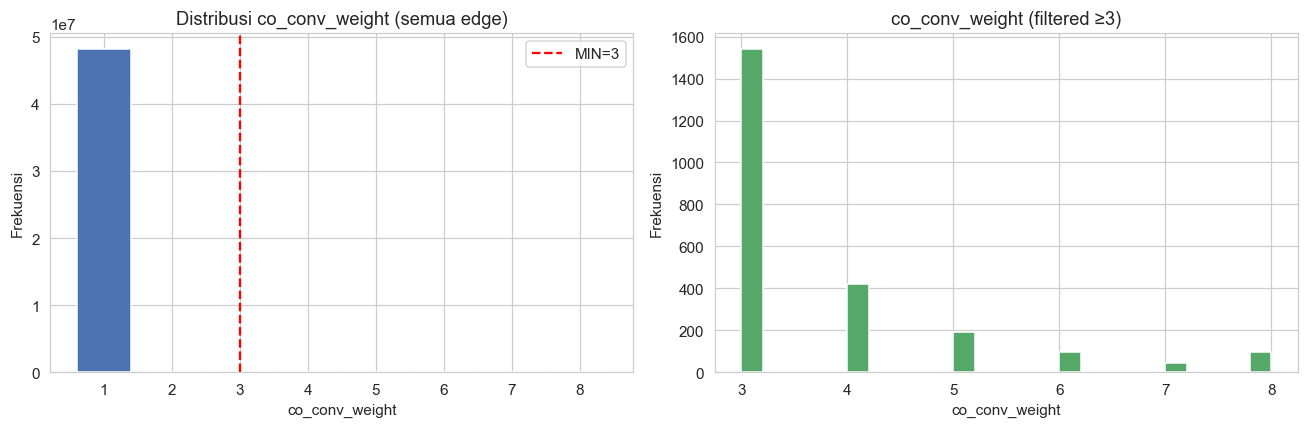

In [12]:
# ── Distribusi co_conv_weight ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_x = sorted(co_conv_weight_fx)
all_y = [co_conv_weight_fx[w] for w in all_x]
axes[0].bar(all_x, all_y, color='#4C72B0', edgecolor='white', width=0.8)
axes[0].axvline(MIN_CO_CONV, color='red', linestyle='--', label=f'MIN={MIN_CO_CONV}')
axes[0].set_title('Distribusi co_conv_weight (semua edge)')
axes[0].set_xlabel('co_conv_weight')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

axes[1].hist(co_conv_filt['co_conv_weight'], bins=25, color='#55A868', edgecolor='white')
axes[1].set_title(f'co_conv_weight (filtered ≥{MIN_CO_CONV})')
axes[1].set_xlabel('co_conv_weight')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


---
## 6. Co-reply Analysis

**Tujuan:** Mengidentifikasi pasangan akun yang membentuk hubungan reply yang sama secara berulang pada beberapa video.
**Input:** `df` (kolom `username`, `parent_user`, `video_id`)
**Output:** `co_reply_filt` DataFrame; `output/tables/co_reply_edges.csv`

In [13]:
# ── Filter baris reply ───────────────────────────────────────────────────────
df_replies = df[df['is_reply']].copy()
print(f'Total baris reply                    : {len(df_replies):,}')
print(f'Pasangan (username, parent_user) unik: '
      f'{df_replies.groupby(["username","parent_user"]).ngroups:,}')

# ── Verifikasi konsistensi normalisasi identitas (Perbaikan 4) ───────────────
# username dan parent_user sama-sama dinormalisasi via strip()+lower() pada
# Section 4. Pengecekan berikut memverifikasi tidak ada target parent_user
# yang gagal cocok ke username manapun akibat perbedaan format (spasi/
# kapitalisasi) -- jika ada yang tidak cocok, edge co-reply untuk pasangan
# tersebut akan hilang secara diam-diam.
_known_usernames   = set(df['username'])
_parent_targets     = set(df_replies['parent_user']) - {''}
_unmatched_targets = _parent_targets - _known_usernames
print(f'Target parent_user unik              : {len(_parent_targets):,}')
print(f'Cocok dengan username yang dikenal    : {len(_parent_targets) - len(_unmatched_targets):,}')
print(f'TIDAK cocok (potensi edge hilang)     : {len(_unmatched_targets):,}')
if _unmatched_targets:
    print(f'  Contoh tidak cocok: {sorted(_unmatched_targets)[:10]}')
else:
    print('  ✓ Seluruh parent_user cocok dengan username -- normalisasi identitas konsisten.')

# ── Hitung reply_count dan shared_videos per pasangan ─────────────────────────
reply_pairs = (
    df_replies
    .groupby(['username', 'parent_user'])
    .agg(
        reply_count   = ('comment_id', 'count'),
        shared_videos = ('video_id',   'nunique')
    )
    .reset_index()
    .rename(columns={'username': 'source', 'parent_user': 'target'})
)

# Hapus self-loop
reply_pairs = reply_pairs[reply_pairs['source'] != reply_pairs['target']].copy()

# Bobot Co-reply = shared_videos (keterulangan interaksi lintas video)
# reply_count dipertahankan sebagai statistik deskriptif.
reply_pairs['co_reply_weight'] = reply_pairs['shared_videos']

print(f'\n=== CO-REPLY SEBELUM FILTERING ===')
print(f'Total edge          : {len(reply_pairs):,}')
print(f'reply_count (deskriptif) — max: {reply_pairs["reply_count"].max()}, '
      f'mean: {reply_pairs["reply_count"].mean():.2f}')
print(f'shared_videos — max: {reply_pairs["shared_videos"].max()}, '
      f'mean: {reply_pairs["shared_videos"].mean():.2f}')

# ── Filtering MIN_CO_REPLY = 2 ─────────────────────────────────────────────────
MIN_CO_REPLY  = 2
co_reply_filt = reply_pairs[reply_pairs['co_reply_weight'] >= MIN_CO_REPLY].copy()

print(f'\n=== CO-REPLY SETELAH FILTERING (MIN_CO_REPLY = {MIN_CO_REPLY}) ===')
print(f'Total edge          : {len(co_reply_filt):,}')
pct = len(co_reply_filt)/len(reply_pairs)*100 if len(reply_pairs) > 0 else 0
print(f'Edge dipertahankan  : {pct:.1f}%')

co_reply_filt.to_csv(RM1_TABLES_DIR / "co_reply_edges.csv", index=False)
print(f'\n✓ Disimpan: output/tables/co_reply_edges.csv')
display(co_reply_filt.sort_values('co_reply_weight', ascending=False).head(10))


Total baris reply                    : 10,833
Pasangan (username, parent_user) unik: 8,687
Target parent_user unik              : 2,990
Cocok dengan username yang dikenal    : 2,647
TIDAK cocok (potensi edge hilang)     : 343
  Contoh tidak cocok: ['.jxnnnnnnn', '04.931', '0llnaurah', '325queenzy', '__6auliaa', '__kesayangamu', '_ariesgirl03_', '_rhmaawatiiiiiii', '_strawberrychild6', 'a_ayyy2']

=== CO-REPLY SEBELUM FILTERING ===
Total edge          : 7,960
reply_count (deskriptif) — max: 15, mean: 1.19
shared_videos — max: 7, mean: 1.07

=== CO-REPLY SETELAH FILTERING (MIN_CO_REPLY = 2) ===
Total edge          : 299
Edge dipertahankan  : 3.8%

✓ Disimpan: output/tables/co_reply_edges.csv


,source,target,reply_count,shared_videos,co_reply_weight
4321,kulitglowing_ct49929,cantik_ct9210,7,7,7
3520,glowingid_rr70761,glowingid_rp49842,7,7,7
3508,glowingid_rr16545,beautyvibe_ct78952,7,7,7
7339,skinclub_rr18264,kulitcerah_rp65773,7,7,7
1349,beautyaddict_rr30107,beautyaddict_rp79642,7,7,7
7485,skintok_ct62066,glowhunter_rp10498,7,7,7
7467,skinlover_rr34452,kulitglowing_rp49531,7,7,7
3539,glowup_rr94347,glowhunter_rp43404,7,7,7
1491,beautyvibe_rr36610,testireal_rp74004,7,7,7
3496,glowhunter_rr20059,racun_rp24880,7,7,7


---
## 7. Co-temporal Analysis

**Tujuan:** Mengidentifikasi pasangan akun yang secara berulang berkomentar dalam rentang waktu berdekatan pada beberapa video yang berbeda.
**Input:** `df` (kolom `video_id`, `username`, `timestamp`)
**Output:** `co_temporal_filt` DataFrame; `output/tables/co_temporal_edges.csv`

In [14]:
# ── Parameter window: dikalibrasi dari distribusi data (bukan angka Weber) ───
# Weber & Neumann (2021) menyetel gamma={15,60,360,1440} menit khusus untuk
# ritme retweet di Twitter (mengacu Zhao et al. 2015: 75% retweet terjadi
# dalam 6 jam sejak posting). Angka tersebut tidak punya dasar empiris untuk
# TikTok, sehingga CO_TEMPORAL_WINDOW_MIN di sini DIKALIBRASI dari distribusi
# interval antar-komentar berurutan pada dataset ini sendiri, bukan disalin
# dari paper.
df_temp = df.dropna(subset=['timestamp']).sort_values(['video_id', 'timestamp'])
print(f'Baris dengan timestamp valid : {len(df_temp):,}')

_intervals_all_min = []
for _vid, _grp in df_temp.groupby('video_id'):
    _times = _grp['timestamp'].sort_values().values
    for _i in range(len(_times) - 1):
        _delta_min = (_times[_i + 1] - _times[_i]) / pd.Timedelta(minutes=1)
        if _delta_min >= 0:
            _intervals_all_min.append(_delta_min)

_pct = {p: float(np.percentile(_intervals_all_min, p)) for p in (10, 25, 50, 75, 90)}
print('Persentil interval antar-komentar berurutan (menit):')
for _p, _val in _pct.items():
    print(f'  P{_p:<3d}: {_val:.2f} menit')

# P25 (~0 menit) tidak praktis sebagai window: nilainya mendekati nol sehingga
# hanya menangkap komentar yang datang dalam hitungan detik yang sama (besar
# kemungkinan refresh halaman/notifikasi berurutan, bukan pola koordinasi
# lintas waktu). Karena itu dipakai P50 (median) sebagai window praktis
# pertama yang representatif -- tetap murni dikalibrasi dari distribusi data
# dataset ini, bukan nilai tetap Weber & Neumann.
CO_TEMPORAL_WINDOW_MIN = max(1, round(_pct[50]))
print(f'\nCO_TEMPORAL_WINDOW_MIN dipilih dari data (P50/median) : {CO_TEMPORAL_WINDOW_MIN} menit')
print('(P25 dicek tapi tidak dipakai karena tidak praktis/mendekati nol; nilai di atas')
print(' diverifikasi terhadap distribusi interval data TikTok ini, bukan disalin dari')
print(' parameter gamma Weber & Neumann yang disetel untuk ritme retweet Twitter.)')

DELTA_LIMIT = pd.Timedelta(minutes=CO_TEMPORAL_WINDOW_MIN)
print(f'\nCo-temporal window : {CO_TEMPORAL_WINDOW_MIN} menit')

# ── Hitung co_temporal_weight ─────────────────────────────────────────────────
# Algoritma: per video, tentukan pasangan yang muncul dalam window <= CO_TEMPORAL_WINDOW_MIN.
# Setiap pasangan di-deduplikasi per video → co_temporal_weight = jumlah video.
co_temporal_vids = defaultdict(set)   # (u, v) → set video_id

for vid, grp in tqdm(df_temp.groupby('video_id'), desc='Co-temporal per video'):
    users = grp['username'].values
    times = grp['timestamp'].values
    n     = len(users)

    pairs_in_video = set()             # deduplikasi per video
    for i in range(n):
        for j in range(i + 1, n):
            if (times[j] - times[i]) > DELTA_LIMIT:
                break                  # data sudah terurut ascending
            if users[i] != users[j]:
                key = tuple(sorted([users[i], users[j]]))
                pairs_in_video.add(key)

    for key in pairs_in_video:
        co_temporal_vids[key].add(vid)

# Konversi ke DataFrame
co_temporal_df = pd.DataFrame(
    [(u, v, len(vids)) for (u, v), vids in co_temporal_vids.items()],
    columns=['source', 'target', 'co_temporal_weight']
)

print(f'\n=== CO-TEMPORAL SEBELUM FILTERING ===')
print(f'Total edge          : {len(co_temporal_df):,}')
print(f'weight min–max–mean : {co_temporal_df["co_temporal_weight"].min()} – '
      f'{co_temporal_df["co_temporal_weight"].max()} – '
      f'{co_temporal_df["co_temporal_weight"].mean():.2f}')

# ── Filtering MIN_CO_TEMPORAL = 3 ────────────────────────────────────────────
MIN_CO_TEMPORAL   = 3
co_temporal_filt  = co_temporal_df[
    co_temporal_df['co_temporal_weight'] >= MIN_CO_TEMPORAL
].copy()

print(f'\n=== CO-TEMPORAL SETELAH FILTERING (MIN_CO_TEMPORAL = {MIN_CO_TEMPORAL}) ===')
print(f'Total edge          : {len(co_temporal_filt):,}')
pct = len(co_temporal_filt)/len(co_temporal_df)*100 if len(co_temporal_df) > 0 else 0
print(f'Edge dipertahankan  : {pct:.4f}%')

co_temporal_filt.to_csv(RM1_TABLES_DIR / "co_temporal_edges.csv", index=False)
print(f'\n✓ Disimpan: output/tables/co_temporal_edges.csv')
display(co_temporal_filt.sort_values('co_temporal_weight', ascending=False).head(10))


Baris dengan timestamp valid : 35,275


Persentil interval antar-komentar berurutan (menit):
  P10 : 0.13 menit
  P25 : 0.60 menit
  P50 : 8.83 menit
  P75 : 209.85 menit
  P90 : 1522.00 menit

CO_TEMPORAL_WINDOW_MIN dipilih dari data (P50/median) : 9 menit
(P25 dicek tapi tidak dipakai karena tidak praktis/mendekati nol; nilai di atas
 diverifikasi terhadap distribusi interval data TikTok ini, bukan disalin dari
 parameter gamma Weber & Neumann yang disetel untuk ritme retweet Twitter.)

Co-temporal window : 9 menit


Co-temporal per video:   0%|          | 0/55 [00:00<?, ?it/s]


=== CO-TEMPORAL SEBELUM FILTERING ===
Total edge          : 305,512
weight min–max–mean : 1 – 8 – 1.00

=== CO-TEMPORAL SETELAH FILTERING (MIN_CO_TEMPORAL = 3) ===
Total edge          : 367
Edge dipertahankan  : 0.1201%

✓ Disimpan: output/tables/co_temporal_edges.csv


,source,target,co_temporal_weight
982,kulitcerah_ct29113,reviewjujur_ct97003,8
975,beautyvibe_ct78952,reviewjujur_ct39243,8
323,dearskin_ct58033,skincare_ct87875,8
989,beautyvibe_ct78952,reviewjujur_ct55350,8
983,beautyvibe_ct78952,kulitcerah_ct29113,8
298,glowup_ct95907,skincare_ct87875,8
981,kulitcerah_ct29113,reviewjujur_ct55350,8
289,dearskin_ct58033,glowup_ct95907,8
967,kulitcerah_ct29113,reviewjujur_ct39243,8
963,reviewjujur_ct55350,reviewjujur_ct97003,8


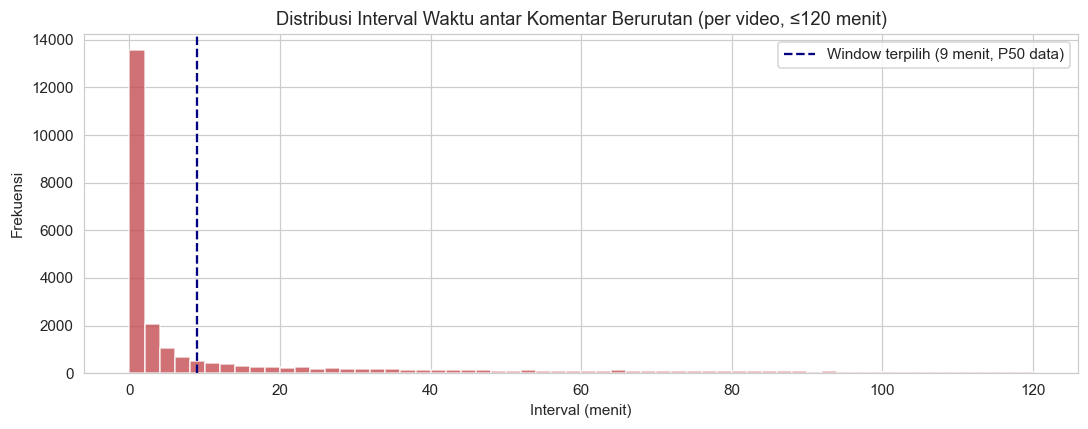

Komentar dalam ≤9 menit dari komentar sebelumnya: 50.2%


In [15]:
# ── Distribusi interval waktu komentar per video ──────────────────────────────
# (menunjukkan dasar kalibrasi CO_TEMPORAL_WINDOW_MIN pada sel sebelumnya;
# tidak mempengaruhi LCN)
intervals = [x for x in _intervals_all_min if x <= 120]   # cap 120 menit untuk plot

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(intervals, bins=60, color='#C44E52', edgecolor='white', alpha=0.8)
ax.axvline(CO_TEMPORAL_WINDOW_MIN, color='navy', linestyle='--',
           linewidth=1.5, label=f'Window terpilih ({CO_TEMPORAL_WINDOW_MIN} menit, P50 data)')
ax.set_title('Distribusi Interval Waktu antar Komentar Berurutan (per video, ≤120 menit)')
ax.set_xlabel('Interval (menit)')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

pct_within = sum(1 for x in _intervals_all_min if x <= CO_TEMPORAL_WINDOW_MIN) / len(_intervals_all_min) * 100
print(f'Komentar dalam ≤{CO_TEMPORAL_WINDOW_MIN} menit dari komentar sebelumnya: {pct_within:.1f}%')


---
## 8. Evidence Summary

**Tujuan:** Merangkum seluruh evidence koordinasi yang telah dibangun sebelum normalisasi dan penggabungan ke LCN.  
**Input:** `co_conv_filt`, `co_reply_filt`, `co_temporal_filt`  
**Output:** Tabel ringkasan tiga evidence; himpunan akun yang terlibat per evidence.


In [16]:
# ── Tabel ringkasan evidence ──────────────────────────────────────────────────
summary_ev = pd.DataFrame([
    {
        'Evidence'        : 'Co-conv',
        'Deskripsi'       : 'Kemunculan bersama pada video yang sama',
        'Formula bobot'   : 'jumlah video bersama',
        'Threshold'       : f'MIN_CO_CONV = {MIN_CO_CONV}',
        'Edge (raw)'      : co_conv_raw_edge_count,
        'Edge (filtered)' : len(co_conv_filt),
        'weight min'      : int(co_conv_filt['co_conv_weight'].min())  if len(co_conv_filt) else 0,
        'weight max'      : int(co_conv_filt['co_conv_weight'].max())  if len(co_conv_filt) else 0,
        'weight mean'     : round(co_conv_filt['co_conv_weight'].mean(), 2) if len(co_conv_filt) else 0,
    },
    {
        'Evidence'        : 'Co-reply',
        'Deskripsi'       : 'Keterulangan reply lintas video',
        'Formula bobot'   : 'shared_videos',
        'Threshold'       : f'MIN_CO_REPLY = {MIN_CO_REPLY}',
        'Edge (raw)'      : len(reply_pairs),
        'Edge (filtered)' : len(co_reply_filt),
        'weight min'      : int(co_reply_filt['co_reply_weight'].min())  if len(co_reply_filt) else 0,
        'weight max'      : int(co_reply_filt['co_reply_weight'].max())  if len(co_reply_filt) else 0,
        'weight mean'     : round(co_reply_filt['co_reply_weight'].mean(), 2) if len(co_reply_filt) else 0,
    },
    {
        'Evidence'        : 'Co-temporal',
        'Deskripsi'       : f'Keterulangan aktivitas temporal (window ≤{CO_TEMPORAL_WINDOW_MIN} menit) lintas video',
        'Formula bobot'   : 'jumlah video bersama dalam window',
        'Threshold'       : f'MIN_CO_TEMPORAL = {MIN_CO_TEMPORAL}',
        'Edge (raw)'      : len(co_temporal_df),
        'Edge (filtered)' : len(co_temporal_filt),
        'weight min'      : int(co_temporal_filt['co_temporal_weight'].min())  if len(co_temporal_filt) else 0,
        'weight max'      : int(co_temporal_filt['co_temporal_weight'].max())  if len(co_temporal_filt) else 0,
        'weight mean'     : round(co_temporal_filt['co_temporal_weight'].mean(), 2) if len(co_temporal_filt) else 0,
    },
])

print('=== RINGKASAN EVIDENCE KOORDINASI ===')
display(summary_ev)

# ── Akun unik per evidence ────────────────────────────────────────────────────
def unique_actors(df_e, src='source', tgt='target'):
    return set(df_e[src].tolist() + df_e[tgt].tolist())

actors_cc  = unique_actors(co_conv_filt)
actors_cr  = unique_actors(co_reply_filt)
actors_ct  = unique_actors(co_temporal_filt)
actors_all = actors_cc | actors_cr | actors_ct

print(f'\nAkun unik dalam evidence (filtered):')
print(f'  Co-conv        : {len(actors_cc):,}')
print(f'  Co-reply       : {len(actors_cr):,}')
print(f'  Co-temporal    : {len(actors_ct):,}')
print(f'  Gabungan       : {len(actors_all):,}')


=== RINGKASAN EVIDENCE KOORDINASI ===


,Evidence,Deskripsi,Formula bobot,Threshold,Edge (raw),Edge (filtered),weight min,weight max,weight mean
0,Co-conv,Kemunculan bersama pada video yang sama,jumlah video bersama,MIN_CO_CONV = 3,48175308,2393,3,8,3.7400
1,Co-reply,Keterulangan reply lintas video,shared_videos,MIN_CO_REPLY = 2,7960,299,2,7,2.9200
2,Co-temporal,Keterulangan aktivitas temporal (window ≤9 men...,jumlah video bersama dalam window,MIN_CO_TEMPORAL = 3,305512,367,3,8,3.5700



Akun unik dalam evidence (filtered):
  Co-conv        : 576
  Co-reply       : 532
  Co-temporal    : 170
  Gabungan       : 779


---
## 9. Evidence Filtering & Normalization

**Tujuan:** Menggabungkan tiga evidence mentah (belum difilter per-tipe), menerapkan **Evidence Filtering**
(kondisi OR terhadap `MIN_CO_CONV`, `MIN_CO_REPLY`, `MIN_CO_TEMPORAL`) **sebelum** Min-Max Normalization —
sehingga skala normalisasi dihitung hanya di atas edge yang telah memenuhi evidence minimum, termasuk nilai
`0` dari evidence lain yang tidak terpenuhi pada edge tersebut.
**Input:** `co_conv_df`, `reply_pairs`, `co_temporal_df` (evidence mentah)
**Output:** `evidence_filtered` — edge table gabungan dengan kolom `co_conv_norm`, `co_reply_norm`, `co_temporal_norm`.


In [17]:
# ── Fungsi Normalisasi (Min-Max & Max) ───────────────────────────────────────
def minmax_norm(series):
    """Min-Max Normalization: (x - xmin) / (xmax - xmin).
    Mengembalikan 0.0 untuk kolom konstan (xmax == xmin).
    Dipakai untuk membandingkan skor ANTAR-KOMUNITAS pada Community Coordination
    Profile (Section 16), bukan untuk evidence LCN.
    """
    x_min = series.min()
    x_max = series.max()
    if x_max == x_min:
        return pd.Series(0.0, index=series.index)
    return (series - x_min) / (x_max - x_min)


def max_norm(series):
    """Max Normalization: x / x_max. Mengembalikan 0.0 bila x_max == 0.

    Perbaikan 1: dipakai untuk Co-conv/Co-reply/Co-temporal (bukan minmax_norm).
    minmax_norm menggeser nilai MINIMUM pada kolom menjadi 0 -- untuk evidence
    LCN ini artinya edge dengan evidence paling rendah (mis. co_conv_weight=2,
    nilai TERBANYAK/87% edge pada data ini) selalu ternormalisasi menjadi 0,
    sehingga evidence riil tersebut kehilangan kontribusinya pada final_weight.
    max_norm menghindari distorsi ini: hasil hanya 0 bila evidence itu sendiri
    benar-benar 0.
    """
    x_max = series.max()
    if x_max == 0:
        return pd.Series(0.0, index=series.index)
    return series / x_max

# ── Evidence Filtering: gabungkan evidence MENTAH lalu terapkan OR threshold ──
# sebelum normalisasi (bukan sesudahnya), agar Min-Max Normalization dihitung
# di atas edge yang sudah lolos evidence minimum -- termasuk nilai 0 dari
# evidence lain yang tidak terpenuhi pada edge tersebut.
def canon_pairs(df_e, weight_col, s='source', t='target'):
    """Normalisasi arah edge (undirected: source < target) + agregasi max per pasangan."""
    df_e = df_e[[s, t, weight_col]].copy()
    mask = df_e[s] > df_e[t]
    df_e.loc[mask, [s, t]] = df_e.loc[mask, [t, s]].values
    return df_e.groupby([s, t], as_index=False)[weight_col].max()

cr_raw = canon_pairs(reply_pairs,    'co_reply_weight')
ct_raw = canon_pairs(co_temporal_df, 'co_temporal_weight')

# Implementasi hemat-memori: kita tidak mematerialisasi seluruh 45M+ raw
# co-conv edge ke DataFrame. Namun logikanya tetap sama: untuk seluruh pasangan
# yang relevan pada tahap evidence filtering (pasangan yang lolos co-conv atau
# muncul pada evidence lain), nilai co-conv mentah tetap diambil dari
# `co_conv_counter`, sehingga pair yang lolos via co-reply/co-temporal tetap
# membawa bobot co-conv sub-threshold bila ada.
relevant_pairs = (
    set(zip(co_conv_filt['source'], co_conv_filt['target'])) |
    set(zip(cr_raw['source'], cr_raw['target'])) |
    set(zip(ct_raw['source'], ct_raw['target']))
)
cc_raw = pd.DataFrame(
    ((u, v, co_conv_counter.get((u, v), 0)) for u, v in sorted(relevant_pairs)),
    columns=['source', 'target', 'co_conv_weight']
)

evidence_all = (
    cc_raw.merge(cr_raw, on=['source', 'target'], how='outer')
          .merge(ct_raw, on=['source', 'target'], how='outer')
)
evidence_cols = ['co_conv_weight', 'co_reply_weight', 'co_temporal_weight']
evidence_all[evidence_cols] = evidence_all[evidence_cols].fillna(0)

print('=== EVIDENCE FILTERING (kombinasi OR, sebelum normalisasi) ===')
print(f'Total edge kandidat (gabungan Co-conv ∪ Co-reply ∪ Co-temporal): {len(evidence_all):,}')

evidence_mask = (
    (evidence_all['co_conv_weight']     >= MIN_CO_CONV)   |
    (evidence_all['co_reply_weight']    >= MIN_CO_REPLY)  |
    (evidence_all['co_temporal_weight'] >= MIN_CO_TEMPORAL)
)
evidence_filtered = evidence_all[evidence_mask].copy().reset_index(drop=True)

print(f'Kondisi   : (co_conv_weight >= {MIN_CO_CONV}) OR (co_reply_weight >= {MIN_CO_REPLY}) '
      f'OR (co_temporal_weight >= {MIN_CO_TEMPORAL})')
print(f'Total edge setelah evidence filtering : {len(evidence_filtered):,}')
pct_ev = len(evidence_filtered) / len(evidence_all) * 100 if len(evidence_all) else 0
print(f'Edge dipertahankan                     : {pct_ev:.1f}%')

# ── Flag n_evidence: jumlah evidence independen (>0) per edge ───────────────
# Bukan bagian dari formula Final Weight (tetap penjumlahan datar tiga skor
# ternormalisasi, Persamaan 1 Weber & Neumann 2021: w(e) = sum wc(e)) -- kolom
# ini murni atribut tambahan untuk menyaring edge/HCC "high-confidence" (mis.
# didukung >=2 evidence independen) pada analisis lanjutan, tanpa mengubah
# weight itu sendiri.
evidence_filtered['n_evidence'] = (
    (evidence_filtered['co_conv_weight']     > 0).astype(int) +
    (evidence_filtered['co_reply_weight']    > 0).astype(int) +
    (evidence_filtered['co_temporal_weight'] > 0).astype(int)
)
print('\nDistribusi n_evidence (jumlah edge per banyaknya evidence > 0):')
display(evidence_filtered['n_evidence'].value_counts().sort_index().rename('jumlah_edge').to_frame())

# ── Min-Max Normalization (HANYA pada edge yang lolos evidence filtering) ────
evidence_filtered['co_conv_norm']     = max_norm(evidence_filtered['co_conv_weight'])
evidence_filtered['co_reply_norm']    = max_norm(evidence_filtered['co_reply_weight'])
evidence_filtered['co_temporal_norm'] = max_norm(evidence_filtered['co_temporal_weight'])

# ── Ringkasan statistik hasil normalisasi ─────────────────────────────────────
norm_summary = pd.DataFrame({
    'Evidence'  : ['Co-conv', 'Co-reply', 'Co-temporal'],
    'raw_min'   : [
        evidence_filtered['co_conv_weight'].min(),
        evidence_filtered['co_reply_weight'].min(),
        evidence_filtered['co_temporal_weight'].min()
    ],
    'raw_max'   : [
        evidence_filtered['co_conv_weight'].max(),
        evidence_filtered['co_reply_weight'].max(),
        evidence_filtered['co_temporal_weight'].max()
    ],
    'norm_min'  : [
        evidence_filtered['co_conv_norm'].min(),
        evidence_filtered['co_reply_norm'].min(),
        evidence_filtered['co_temporal_norm'].min()
    ],
    'norm_max'  : [
        evidence_filtered['co_conv_norm'].max(),
        evidence_filtered['co_reply_norm'].max(),
        evidence_filtered['co_temporal_norm'].max()
    ],
    'norm_mean' : [
        round(evidence_filtered['co_conv_norm'].mean(), 4),
        round(evidence_filtered['co_reply_norm'].mean(), 4),
        round(evidence_filtered['co_temporal_norm'].mean(), 4)
    ],
})

print('\n=== RINGKASAN NORMALISASI EVIDENCE (setelah evidence filtering) ===')
display(norm_summary)
print('\n✓ Nilai ternormalisasi berada pada rentang [0.0000, 1.0000].')

# ── Verifikasi Perbaikan 1: max_norm aktif (bukan min-max lama) ──────────────
_cc2 = evidence_filtered.loc[evidence_filtered['co_conv_weight'] == 2, 'co_conv_norm']
print('\n=== VERIFIKASI PERBAIKAN 1 (max_norm aktif untuk Co-conv/Co-reply/Co-temporal) ===')
if len(_cc2):
    print(f"norm_co_conv untuk co_conv_weight=2 : {_cc2.iloc[0]:.4f} "
          f"(harus > 0; max_norm = 2 / {evidence_filtered['co_conv_weight'].max():.0f})")
    assert _cc2.iloc[0] > 0, 'BUG: norm_co_conv untuk co_conv_weight=2 masih 0 -- cek formula normalisasi.'
else:
    print('Tidak ada edge dengan co_conv_weight=2 pada evidence_filtered saat ini.')


=== EVIDENCE FILTERING (kombinasi OR, sebelum normalisasi) ===
Total edge kandidat (gabungan Co-conv ∪ Co-reply ∪ Co-temporal): 314,271
Kondisi   : (co_conv_weight >= 3) OR (co_reply_weight >= 2) OR (co_temporal_weight >= 3)
Total edge setelah evidence filtering : 2,528
Edge dipertahankan                     : 0.8%

Distribusi n_evidence (jumlah edge per banyaknya evidence > 0):


,jumlah_edge
n_evidence,
1,1838
2,618
3,72



=== RINGKASAN NORMALISASI EVIDENCE (setelah evidence filtering) ===


,Evidence,raw_min,raw_max,norm_min,norm_max,norm_mean
0,Co-conv,2.0000,8.0000,0.2500,1.0000,0.4555
1,Co-reply,0.0000,7.0000,0.0000,1.0000,0.0495
2,Co-temporal,0.0000,8.0000,0.0000,1.0000,0.0709



✓ Nilai ternormalisasi berada pada rentang [0.0000, 1.0000].

=== VERIFIKASI PERBAIKAN 1 (max_norm aktif untuk Co-conv/Co-reply/Co-temporal) ===
norm_co_conv untuk co_conv_weight=2 : 0.2500 (harus > 0; max_norm = 2 / 8)


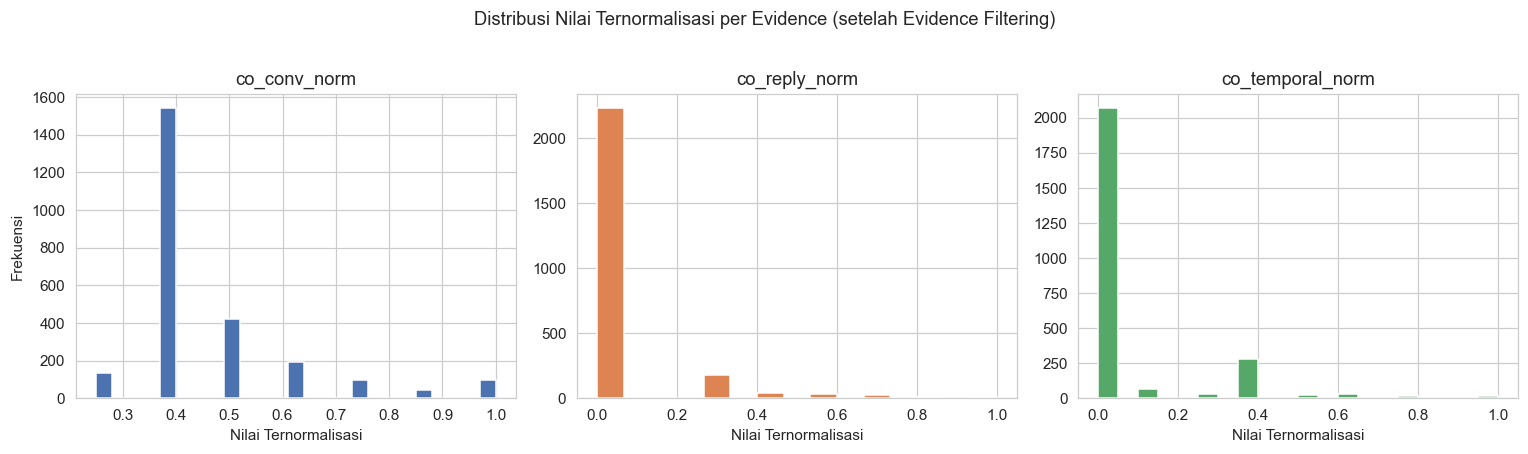

In [18]:
# ── Visualisasi distribusi nilai ternormalisasi ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(evidence_filtered['co_conv_norm'], bins=25, color='#4C72B0', edgecolor='white')
axes[0].set_title('co_conv_norm')
axes[0].set_xlabel('Nilai Ternormalisasi')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(evidence_filtered['co_reply_norm'], bins=15, color='#DD8452', edgecolor='white')
axes[1].set_title('co_reply_norm')
axes[1].set_xlabel('Nilai Ternormalisasi')

axes[2].hist(evidence_filtered['co_temporal_norm'], bins=20, color='#55A868', edgecolor='white')
axes[2].set_title('co_temporal_norm')
axes[2].set_xlabel('Nilai Ternormalisasi')

plt.suptitle('Distribusi Nilai Ternormalisasi per Evidence (setelah Evidence Filtering)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


---
## Final Weight Calculation

**Tujuan:** Membentuk Final Weight untuk seluruh edge kandidat LCN (hasil Evidence Filtering +
Min-Max Normalization pada Section 9), sesuai Eq. (1) Weber & Neumann (2021):
$w(e) = \sum_{c=1}^{q} w^c(e)$. Final Weight **tidak** digunakan untuk memfilter atau memangkas edge
LCN -- LCN tetap memuat seluruh edge hasil Evidence Filtering, dan Final Weight murni menjadi atribut
bobot edge yang dipakai oleh Louvain Community Detection (Section 11) dan FSA_V (Section 12).
**Input:** `evidence_filtered` (hasil Evidence Filtering + Min-Max Normalization)
**Output:** `lcn` -- seluruh edge dengan Final Weight (`weight`).

In [19]:
# ── Hitung Final Weight (evidence sudah difilter & dinormalisasi di Section 9) ──
lcn = evidence_filtered.copy()

lcn['weight'] = (
    lcn['co_conv_norm'] +
    lcn['co_reply_norm'] +
    lcn['co_temporal_norm']
)

print(f'LCN edge sebelum filtering final : {len(lcn):,}')
print(f'weight — min: {lcn["weight"].min():.4f}  '
      f'max: {lcn["weight"].max():.4f}  '
      f'mean: {lcn["weight"].mean():.4f}  '
      f'median: {lcn["weight"].median():.4f}')

# ── Verifikasi Perbaikan 1: median final_weight harus > 0 ────────────────────
_median_fw = lcn['weight'].median()
print(f"\nVerifikasi Perbaikan 1: median final_weight = {_median_fw:.4f} "
      f"({'OK, > 0' if _median_fw > 0 else 'BUG -- masih 0'})")

# n_evidence (Section 9) ikut terbawa via .copy() di atas -- konfirmasi:
print(f'n_evidence tersedia di lcn (jumlah edge per banyaknya evidence > 0): '
      f'{lcn["n_evidence"].value_counts().sort_index().to_dict()}')


LCN edge sebelum filtering final : 2,528
weight — min: 0.3750  max: 2.0000  mean: 0.5759  median: 0.5000

Verifikasi Perbaikan 1: median final_weight = 0.5000 (OK, > 0)
n_evidence tersedia di lcn (jumlah edge per banyaknya evidence > 0): {1: 1838, 2: 618, 3: 72}


---
## 10. Build Latent Coordination Network (LCN)

**Tujuan:** Membentuk **Latent Coordination Network (LCN)** dari edge `lcn` (hasil Evidence Filtering +
Final Weight), dengan tambahan **threshold persentil Final Weight** (Perbaikan 3) sebelum Community
Detection/FSA_V dijalankan, sebagai jaringan utama untuk seluruh analisis SNA berikutnya (Community
Detection, HCC, FSA, dst.).

**Alasan metodologis:** Evidence Filtering (`co_conv_weight >= 3` OR `co_reply_weight >= 2` OR
`co_temporal_weight >= 3`) tetap menjadi proses seleksi utama yang menyaring jutaan kandidat edge
mentah. Namun evidence filtering bersifat OR -- sebuah edge tetap lolos meski hanya mengandung SATU
evidence lemah, sehingga LCN mentah masih memuat banyak edge berbobot sangat rendah. Threshold
persentil Final Weight pada tahap ini membuang edge derau tersebut sebelum Community Detection,
sehingga komunitas dan HCC yang terbentuk lebih padat dan bermakna. Ambang ini bukan bagian Algorithm 2
Weber & Neumann -- ini adalah pra-filter praktis pada LCN, terpisah dari kriteria penerimaan HCC
(MEW >= g_mean) pada Section 12.

**Input:** `lcn` (edge dengan kolom `weight`, hasil Final Weight)
**Output:** `lcn_edges` — LCN (edge `lcn` sesudah threshold persentil Final Weight); grafik NetworkX `G`
(dibangun dari LCN).


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALISIS DISTRIBUSI EDGE WEIGHT (LCN, sebelum threshold Perbaikan 3)
# Tujuan: mengkarakterisasi distribusi Final Weight pada seluruh edge `lcn`
# (hasil Evidence Filtering + Final Weight) secara deskriptif -- statistik ini
# juga menjadi dasar penentuan ambang persentil pada Section 10 (Perbaikan 3).
# ══════════════════════════════════════════════════════════════════════════════

weights = lcn["weight"].values

# ── Statistik deskriptif ──────────────────────────────────────────────────────
stats_df = pd.DataFrame({
    "Statistik" : ["Mean", "Median", "Std Dev", "Min", "Max",
                   "Q1 (25%)", "Q3 (75%)", "P90 (90%)"],
    "Nilai"     : [
        round(np.mean(weights), 4),
        round(np.median(weights), 4),
        round(np.std(weights), 4),
        round(np.min(weights), 4),
        round(np.max(weights), 4),
        round(np.percentile(weights, 25), 4),
        round(np.percentile(weights, 75), 4),
        round(np.percentile(weights, 90), 4),
    ]
})
print("=== STATISTIK DISTRIBUSI EDGE WEIGHT (LCN) ===")
display(stats_df)


=== STATISTIK DISTRIBUSI EDGE WEIGHT (LCN) ===


,Statistik,Nilai
0,Mean,0.5759
1,Median,0.5000
2,Std Dev,0.2895
3,Min,0.3750
4,Max,2.0000
5,Q1 (25%),0.3750
6,Q3 (75%),0.7500
7,P90 (90%),1.0000


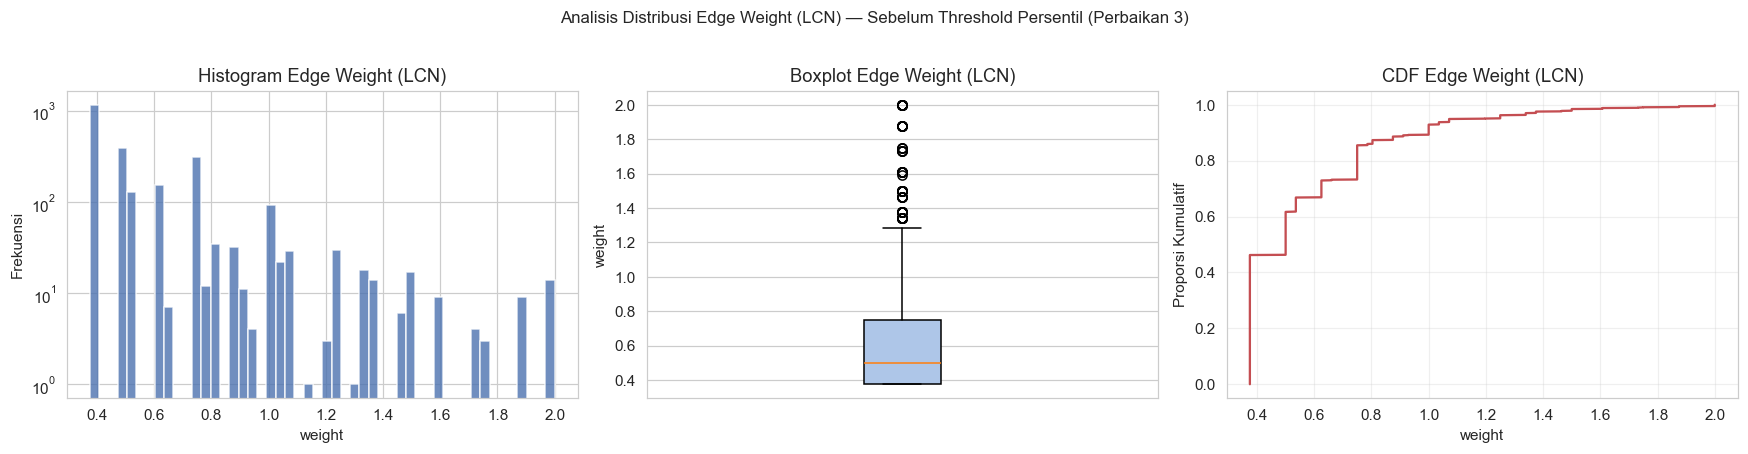

In [21]:
# ── Histogram, boxplot, dan distribusi kumulatif ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(weights, bins=50, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[0].set_title("Histogram Edge Weight (LCN)")
axes[0].set_xlabel("weight")
axes[0].set_ylabel("Frekuensi")
axes[0].set_yscale("log")

# Boxplot
axes[1].boxplot(weights, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#AEC6E8"))
axes[1].set_title("Boxplot Edge Weight (LCN)")
axes[1].set_ylabel("weight")
axes[1].set_xticks([])

# Distribusi kumulatif (CDF)
sorted_w = np.sort(weights)
cdf      = np.arange(1, len(sorted_w)+1) / len(sorted_w)
axes[2].plot(sorted_w, cdf, color="#C44E52", linewidth=1.5)
axes[2].set_title("CDF Edge Weight (LCN)")
axes[2].set_xlabel("weight")
axes[2].set_ylabel("Proporsi Kumulatif")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Analisis Distribusi Edge Weight (LCN) — Sebelum Threshold Persentil (Perbaikan 3)",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


In [22]:
# ── LCN: threshold persentil Final Weight sebelum FSA_V (Perbaikan 3) ───────
# Ambang ini BUKAN bagian Algorithm 2 Weber & Neumann -- ini adalah pra-filter
# praktis pada LCN untuk membuang edge berbobot rendah/derau sebelum Louvain +
# FSA_V dijalankan, terpisah dari kriteria penerimaan HCC (MEW >= g_mean) pada
# Section 12. Titik awal: persentil median (P50), dikalibrasi naik/turun agar
# total node HCC (komunitas >=3 anggota, Perbaikan 4) berada pada rentang
# target 200-225 node.
LCN_WEIGHT_PERCENTILE = 50  # persentil ambang batas final_weight

weight_threshold = float(np.percentile(lcn['weight'], LCN_WEIGHT_PERCENTILE))

print(f'=== LCN: THRESHOLD PERSENTIL FINAL WEIGHT (Perbaikan 3) ===')
print(f'Total edge LCN sebelum threshold : {len(lcn):,}')
print(f'Persentil ambang batas            : P{LCN_WEIGHT_PERCENTILE}')
print(f'Nilai ambang batas final_weight    : {weight_threshold:.4f}')

lcn_edges = lcn[lcn['weight'] >= weight_threshold].copy().reset_index(drop=True)

print(f'\nTotal edge LCN sesudah threshold  : {len(lcn_edges):,}')
pct_kept = len(lcn_edges) / len(lcn) * 100 if len(lcn) else 0
print(f'Edge dipertahankan                : {pct_kept:.1f}%')
print(f'final_weight — min: {lcn_edges["weight"].min():.4f}  '
      f'max: {lcn_edges["weight"].max():.4f}  '
      f'mean: {lcn_edges["weight"].mean():.4f}  '
      f'median: {lcn_edges["weight"].median():.4f}')

# ── Komposisi evidence dalam LCN (sesudah threshold) ─────────────────────────
has_cc = (lcn_edges['co_conv_weight'] > 0).sum()
has_cr = (lcn_edges['co_reply_weight'] > 0).sum()
has_ct = (lcn_edges['co_temporal_weight'] > 0).sum()
has_all_3 = ((lcn_edges['co_conv_weight'] > 0) &
             (lcn_edges['co_reply_weight'] > 0) &
             (lcn_edges['co_temporal_weight'] > 0)).sum()
print(f'\nKomposisi evidence dalam LCN:')
print(f'  Mengandung Co-conv     : {has_cc:,}')
print(f'  Mengandung Co-reply    : {has_cr:,}')
print(f'  Mengandung Co-temporal : {has_ct:,}')
print(f'  Ketiga evidence        : {has_all_3:,}')

print(f'\nDistribusi n_evidence pada LCN (jumlah edge per banyaknya evidence > 0):')
display(lcn_edges['n_evidence'].value_counts().sort_index().rename('jumlah_edge').to_frame())

print(f'\n=== PREVIEW TOP 15 LCN EDGES (berdasarkan final_weight) ===')
display(lcn_edges.sort_values('weight', ascending=False).head(15))


=== LCN: THRESHOLD PERSENTIL FINAL WEIGHT (Perbaikan 3) ===
Total edge LCN sebelum threshold : 2,528
Persentil ambang batas            : P50
Nilai ambang batas final_weight    : 0.5000

Total edge LCN sesudah threshold  : 1,359
Edge dipertahankan                : 53.8%
final_weight — min: 0.5000  max: 2.0000  mean: 0.7487  median: 0.6607

Komposisi evidence dalam LCN:
  Mengandung Co-conv     : 1,359
  Mengandung Co-reply    : 301
  Mengandung Co-temporal : 461
  Ketiga evidence        : 72

Distribusi n_evidence pada LCN (jumlah edge per banyaknya evidence > 0):


,jumlah_edge
n_evidence,
1,669
2,618
3,72



=== PREVIEW TOP 15 LCN EDGES (berdasarkan final_weight) ===


,source,target,co_conv_weight,co_reply_weight,co_temporal_weight,n_evidence,co_conv_norm,co_reply_norm,co_temporal_norm,weight
858,kulitcerah_ct29113,reviewjujur_ct55350,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
218,beautyvibe_ct78952,reviewjujur_ct55350,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
534,dearskin_ct58033,skincare_ct87875,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
1150,reviewjujur_ct39243,reviewjujur_ct97003,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
1155,reviewjujur_ct55350,reviewjujur_ct97003,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
216,beautyvibe_ct78952,kulitcerah_ct29113,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
532,dearskin_ct58033,glowup_ct95907,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
217,beautyvibe_ct78952,reviewjujur_ct39243,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
814,glowup_ct95907,skincare_ct87875,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000
219,beautyvibe_ct78952,reviewjujur_ct97003,8,0.0000,8.0000,2,1.0000,0.0000,1.0000,2.0000


---
## 11. Community Detection

**Tujuan:** Mendeteksi komunitas dalam **LCN** (`lcn_edges`, sesudah threshold persentil Final Weight
pada Section 10 -- Perbaikan 3) menggunakan algoritma Louvain, dan menghitung metrik jaringan dasar. LCN
adalah jaringan utama untuk seluruh analisis SNA berikutnya (Community Detection, HCC, FSA, dst.).
**Input:** `lcn_edges` (LCN, sesudah threshold)
**Output:** `G` — NetworkX graph (LCN); `partition` — mapping node → community_id; `lcn_nodes` — node
table; statistik modularity.


In [23]:
# ── Bangun NetworkX Graph (LCN -- jaringan utama untuk seluruh analisis SNA) ──
G = nx.from_pandas_edgelist(
    lcn_edges,
    source='source', target='target',
    edge_attr=['weight', 'co_conv_weight', 'co_reply_weight', 'co_temporal_weight', 'n_evidence'],
    create_using=nx.Graph()
)
_full_avg_degree = np.mean([d for _, d in G.degree()]) if G.number_of_nodes() else 0.0

print('=== LCN ===')
print(f'Jumlah Node            : {G.number_of_nodes():,}')
print(f'Jumlah Edge            : {G.number_of_edges():,}')
print(f'Density                : {nx.density(G):.6f}')
print(f'Connected Components   : {nx.number_connected_components(G):,}')
print(f'Average Degree         : {_full_avg_degree:.4f}')

# Komponen terbesar LCN (dipakai untuk visualisasi jaringan, Section 18)
Gcc    = max(nx.connected_components(G), key=len)
G_main = G.subgraph(Gcc).copy()
print(f'\nKomponen terbesar LCN:')
print(f'  Node  : {G_main.number_of_nodes():,}')
print(f'  Edge  : {G_main.number_of_edges():,}')
print(f'  Density: {nx.density(G_main):.6f}')


=== LCN ===
Jumlah Node            : 724
Jumlah Edge            : 1,359
Density                : 0.005192
Connected Components   : 202
Average Degree         : 3.7541

Komponen terbesar LCN:
  Node  : 93
  Edge  : 499
  Density: 0.116643


In [24]:
# ── Louvain community detection ───────────────────────────────────────────────
np.random.seed(42)

if LOUVAIN_LIB == 'python-louvain':
    partition  = community_louvain.best_partition(G, weight='weight', random_state=42)
    modularity = community_louvain.modularity(partition, G, weight='weight')
else:
    comm_sets  = nx_community.louvain_communities(G, weight='weight', seed=42)
    partition  = {node: cid for cid, members in enumerate(comm_sets)
                  for node in members}
    modularity = nx_community.modularity(G, comm_sets, weight='weight')

n_communities = len(set(partition.values()))
print(f'Algoritma          : Louvain ({LOUVAIN_LIB})')
print(f'Jumlah komunitas   : {n_communities:,}')
print(f'Modularity         : {modularity:.4f}')

comm_size = pd.Series(partition).value_counts().sort_values(ascending=False)
print(f'\nUkuran komunitas:')
print(f'  Terbesar           : {comm_size.iloc[0]:,} anggota')
print(f'  Terkecil           : {comm_size.iloc[-1]:,} anggota')
print(f'  Rata-rata          : {comm_size.mean():.1f} anggota')
print(f'  Komunitas ≥5 anggota: {(comm_size >= 5).sum():,}')


Algoritma          : Louvain (networkx)
Jumlah komunitas   : 207
Modularity         : 0.9189

Ukuran komunitas:
  Terbesar           : 46 anggota
  Terkecil           : 2 anggota
  Rata-rata          : 3.5 anggota
  Komunitas ≥5 anggota: 36


In [25]:
# ── Hitung metrik jaringan per node ──────────────────────────────────────────
degree_dict   = dict(G.degree())
w_degree_dict = dict(G.degree(weight='weight'))

# Betweenness centrality (aproksimasi jika graph besar)
# LCN memuat edge dengan final_weight = 0 (lolos Evidence Filtering, namun
# nilai Final Weight-nya minimal). networkx menginterpretasikan weight sebagai
# jarak Dijkstra -- jarak 0 pada banyak edge sekaligus membuat perhitungan
# betweenness tidak stabil secara numerik (nilai bisa meledak, mis. ~1e21).
# G_bc HANYA dipakai untuk pemanggilan betweenness_centrality ini; graph utama
# G, degree, dan weighted_degree TIDAK berubah.
_BC_EPSILON = 1e-6
G_bc = G.copy()
for _u, _v, _d in G_bc.edges(data=True):
    _d['weight'] = _d['weight'] + _BC_EPSILON

print('Menghitung betweenness centrality...')
k_bc = min(G.number_of_nodes(), 500)
if G.number_of_nodes() <= 500:
    bc = nx.betweenness_centrality(G_bc, weight='weight', normalized=True)
else:
    bc = nx.betweenness_centrality(G_bc, weight='weight', normalized=True, k=k_bc)
    print(f'  (aproksimasi k={k_bc})')

lcn_nodes = pd.DataFrame({
    'id'              : list(G.nodes()),
    'label'           : list(G.nodes()),
    'degree'          : [degree_dict[n]   for n in G.nodes()],
    'weighted_degree' : [w_degree_dict[n] for n in G.nodes()],
    'betweenness'     : [bc.get(n, 0)     for n in G.nodes()],
    'community'       : [partition[n]     for n in G.nodes()],
})
lcn_nodes = lcn_nodes.sort_values('weighted_degree', ascending=False).reset_index(drop=True)

print(f'\nNode table: {len(lcn_nodes):,} nodes')
display(lcn_nodes.head(10))


Menghitung betweenness centrality...


  (aproksimasi k=500)

Node table: 724 nodes


,id,label,degree,weighted_degree,betweenness,community
0,reviewjujur_ip2228,reviewjujur_ip2228,31,19.2500,0.0006,5
1,skinlover_ip4667,skinlover_ip4667,31,19.1250,0.0007,5
2,glowhunter_ip9119,glowhunter_ip9119,31,19.0000,0.0007,5
3,skincare_ip7443,skincare_ip7443,31,19.0000,0.0007,5
4,skinbestie_ip1027,skinbestie_ip1027,31,19.0000,0.0007,5
5,skinclub_ip8942,skinclub_ip8942,31,19.0000,0.0007,5
6,kulitglowing_ip4767,kulitglowing_ip4767,31,19.0000,0.0007,5
7,kulitglowing_ip9832,kulitglowing_ip9832,31,19.0000,0.0007,5
8,beautyvibe_ip3082,beautyvibe_ip3082,27,17.4107,0.0012,5
9,reviewjujur_ip204,reviewjujur_ip204,27,17.4107,0.0008,5


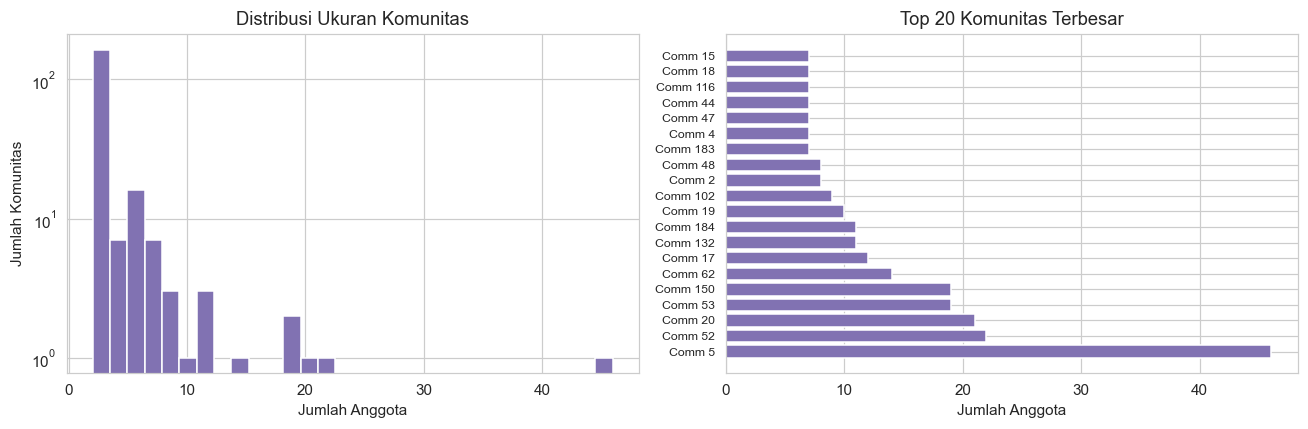

In [26]:
# ── Distribusi ukuran komunitas ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(comm_size.values, bins=30, color='#8172B2', edgecolor='white')
axes[0].set_title('Distribusi Ukuran Komunitas')
axes[0].set_xlabel('Jumlah Anggota')
axes[0].set_ylabel('Jumlah Komunitas')
axes[0].set_yscale('log')

top20_comm = comm_size.head(20)
axes[1].barh(range(len(top20_comm)), top20_comm.values, color='#8172B2')
axes[1].set_yticks(range(len(top20_comm)))
axes[1].set_yticklabels([f'Comm {i}' for i in top20_comm.index], fontsize=8)
axes[1].set_title('Top 20 Komunitas Terbesar')
axes[1].set_xlabel('Jumlah Anggota')

plt.tight_layout()
plt.show()


---
## 12. Highly Coordinating Communities (HCC) -- Focal Structures Analysis Variant (FSA_V)

**Tujuan:** Mengekstraksi Highly Coordinating Communities (HCC) dari LCN menggunakan **FSA_V**
(*Focal Structures Analysis Variant*), algoritma yang dijelaskan secara eksplisit oleh Weber & Neumann
(2021, Algorithm 2) sebagai varian non-rekursif dari Focal Structures Analysis (Sen et al., 2016).

**Cara kerja FSA_V (persis Algorithm 2):**
1. Hitung **Global Mean Edge Weight** (`g_mean`) atas seluruh edge LCN (sekali, sebelum iterasi per
   komunitas).
2. Untuk setiap komunitas hasil Louvain (Section 11), bangun **satu kandidat HCC** `h = (Vh, Eh)`:
   - Mulai dari edge terberat dalam komunitas tersebut.
   - Secara iteratif, tambahkan edge terberat berikutnya yang bertetangga dengan `h` **selama** Mean
     Edge Weight (MEW) kandidat setelah penambahan tidak turun di bawah `g_mean` **dan** tidak turun
     di bawah `MEW_lama x theta`. Begitu salah satu syarat berhenti terpenuhi, pertumbuhan kandidat
     dihentikan.
3. Kandidat final `h` diterima sebagai HCC **hanya jika** MEW akhirnya `> g_mean`.

Tidak ada rekursi, tidak ada penggabungan (*stitching*) antar kandidat, dan tidak ada mekanisme
"ambil N komunitas teratas" -- jumlah HCC murni ditentukan oleh data (bisa nol, bisa banyak), sesuai
metodologi Weber & Neumann apa adanya.

**Parameter:** `THETA` (theta) = 0.3 -- nilai yang sama dengan yang digunakan Weber & Neumann pada
eksperimen FSA_V mereka (theta = 0.3, Table 5 dan Table 7 paper).

**Input:** `G` (LCN), `partition` (hasil Louvain, Section 11)
**Output:** `hcc_ids` -- id komunitas yang menghasilkan HCC; `hcc_list` -- daftar HCC beserta
anggotanya (`Vh`), edge internalnya (`Eh`), dan Mean Edge Weight-nya; `hcc_members_global` -- union
seluruh anggota HCC.

In [27]:
# ── Hitung metrik koordinasi per komunitas ────────────────────────────────────
comm_metrics = []

for comm_id in tqdm(sorted(set(partition.values())), desc='Evaluasi komunitas'):
    members = [n for n, c in partition.items() if c == comm_id]
    n       = len(members)

    if n < 2:
        comm_metrics.append({
            'community_id'         : comm_id,
            'member_count'         : n,
            'density'              : 0.0,
            'avg_degree'           : 0.0,
            'avg_weighted_degree'  : 0.0,
            'internal_edges'       : 0,
            'max_weight'           : 0.0,
        })
        continue

    subG    = G.subgraph(members)
    deg     = dict(subG.degree())
    wdeg    = dict(subG.degree(weight='weight'))
    weights_e = [d.get('weight', 1) for _, _, d in subG.edges(data=True)]

    comm_metrics.append({
        'community_id'         : comm_id,
        'member_count'         : n,
        'density'              : round(nx.density(subG), 6),
        'avg_degree'           : round(np.mean(list(deg.values())), 4),
        'avg_weighted_degree'  : round(np.mean(list(wdeg.values())), 4),
        'internal_edges'       : subG.number_of_edges(),
        'max_weight'           : round(max(weights_e), 4) if weights_e else 0.0,
    })

hcc_df = pd.DataFrame(comm_metrics).sort_values(
    'avg_weighted_degree', ascending=False
).reset_index(drop=True)

print(f'Total komunitas dievaluasi : {len(hcc_df):,}')
display(hcc_df.head(20))


Evaluasi komunitas:   0%|          | 0/207 [00:00<?, ?it/s]

Total komunitas dievaluasi : 207


,community_id,member_count,density,avg_degree,avg_weighted_degree,internal_edges,max_weight
0,5,46,0.3729,16.7826,10.5450,386,1.1250
1,50,6,1.0000,5.0000,8.4583,15,2.0000
2,52,22,0.4848,10.1818,7.0747,112,1.5893
3,46,5,1.0000,4.0000,6.0000,10,1.5000
4,62,14,0.3297,4.2857,4.9668,30,1.6071
5,43,4,1.0000,3.0000,4.5000,6,1.5000
6,44,7,1.0000,6.0000,4.5000,21,0.7500
7,132,11,0.4727,4.7273,4.4286,26,1.8750
8,86,5,1.0000,4.0000,4.2857,10,1.3393
9,20,21,0.2667,5.3333,4.2381,56,2.0000


In [28]:
# ── FSA_V: fungsi-fungsi inti Algorithm 2 (Weber & Neumann, 2021, Sect. 3.1) ─
from typing import Optional


def compute_global_mean_weight(
    graph: nx.Graph,
    weight_attr: str = 'weight',
    positive_only: bool = False,
) -> tuple[float, int]:
    """Global Mean Edge Weight (g_mean) atas edge LCN.

    Secara default fungsi ini menghitung mean seluruh edge seperti pada kode
    resmi Weber & Neumann (`find_hccs`). Untuk kebutuhan notebook ini,
    `positive_only=True` dipakai pada FSA_V agar edge dengan final_weight == 0
    tidak menurunkan baseline global secara artifisial.
    """
    weights = [
        d[weight_attr]
        for _, _, d in graph.edges(data=True)
        if (not positive_only) or (d[weight_attr] > 0)
    ]
    return (float(np.mean(weights)), len(weights)) if weights else (0.0, 0)


def _heaviest_edge(edges: list, weight_attr: str = 'weight') -> tuple:
    """Pilih edge berbobot tertinggi dari sekumpulan edge (u, v, data).

    Implementation Choice: ties dipecah secara deterministik berdasarkan
    (source, target) -- paper tidak menspesifikasikan tie-breaking.

    PENTING (bug non-determinisme, ditemukan saat verifikasi reproducibility):
    `graph.subgraph(members).edges(data=True)` pada NetworkX bisa menghasilkan
    edge undirected yang SAMA dengan orientasi (u, v) TERTUKAR (mis. (A, B)
    pada satu proses, (B, A) pada proses lain) -- ini berasal dari operasi set
    internal NetworkX atas label node (string) yang urutannya dipengaruhi hash
    randomization Python per-proses (PYTHONHASHSEED), BUKAN dari data/parameter
    apa pun. Tie-break SEBELUMNYA memakai (e[0], e[1]) apa adanya, sehingga
    ketika dua edge memiliki weight yang SAMA (sering terjadi di LCN ini),
    pemenang tie-break bisa berbeda antar run hanya karena orientasi edge
    tertukar -- walau Louvain partition & seluruh data identik. Memakai
    (min(e[0], e[1]), max(e[0], e[1])) membuat key tie-break ini invarian
    terhadap orientasi, sehingga hasil FSA_V (HCC) 100% reproducible lintas
    proses/kernel restart, TANPA bergantung pada PYTHONHASHSEED.
    """
    return max(edges, key=lambda e: (e[2][weight_attr], min(e[0], e[1]), max(e[0], e[1])))


def grow_fsa_v_candidate(
    graph: nx.Graph,
    community_members: list,
    g_mean: float,
    theta: float,
    weight_attr: str = 'weight',
) -> Optional[dict]:
    """Tumbuhkan satu kandidat HCC dari satu komunitas Louvain.

    Greedy expansion dipertahankan seperti implementasi notebook sebelumnya:
    mulai dari edge terberat, lalu tambah edge internal terberat yang
    bertetangga dengan kandidat saat ini. Stop rule diselaraskan dengan kode
    resmi Weber & Neumann (`find_hccs`): baseline global memakai `g_mean`,
    dan penurunan mean kandidat dibatasi oleh `theta × stdev_lama`, bukan
    `theta × old_mean`.
    """
    internal_edges = list(graph.subgraph(community_members).edges(data=True))
    if not internal_edges:
        return None

    seed = _heaviest_edge(internal_edges, weight_attr)
    Vh = {seed[0], seed[1]}
    Eh = [seed]
    edge_weights = [seed[2][weight_attr]]

    while True:
        current_mean = float(np.mean(edge_weights))
        if current_mean < g_mean:
            break

        in_eh = {(u, v) for u, v, _ in Eh} | {(v, u) for u, v, _ in Eh}
        candidates = [
            (u, v, d) for u, v, d in internal_edges
            if (u, v) not in in_eh and (u in Vh or v in Vh)
        ]
        if not candidates:
            break

        e = _heaviest_edge(candidates, weight_attr)
        e_weight = e[2][weight_attr]
        old_mean = float(np.mean(edge_weights))
        old_stdev = float(np.std(edge_weights, ddof=1)) if len(edge_weights) > 1 else old_mean
        new_mean = float(np.mean(edge_weights + [e_weight]))

        if e_weight < g_mean or new_mean < (old_mean - theta * old_stdev):
            break

        Eh.append(e)
        Vh.update((e[0], e[1]))
        edge_weights.append(e_weight)

    mean_weight = float(np.mean(edge_weights))
    return {
        'members'    : Vh,
        'edges'      : [(u, v) for u, v, _ in Eh],
        'n_members'  : len(Vh),
        'n_edges'    : len(Eh),
        'mean_weight': mean_weight,
    }


def run_fsa_v(
    graph: nx.Graph,
    partition: dict,
    theta: float,
    weight_attr: str = 'weight',
    positive_only: bool = False,
) -> tuple:
    """Jalankan FSA_V (Algorithm 2, Weber & Neumann 2021) atas seluruh LCN.

    Kandidat HCC dibangun dengan greedy expansion, lalu diterima jika Mean Edge
    Weight (MEW) akhirnya setidaknya menyamai baseline global `g_mean`, selaras
    dengan implementasi resmi Weber & Neumann.
    """
    g_mean, g_mean_n_edges = compute_global_mean_weight(
        graph,
        weight_attr=weight_attr,
        positive_only=positive_only,
    )

    communities: dict = defaultdict(list)
    for node, comm_id in partition.items():
        communities[comm_id].append(node)

    rows = []
    for comm_id, members in communities.items():
        candidate = grow_fsa_v_candidate(graph, members, g_mean, theta, weight_attr)
        if candidate is None:
            rows.append({
                'community_id'         : comm_id,
                'candidate_members'    : None,
                'candidate_n_members'  : 0,
                'candidate_n_edges'    : 0,
                'candidate_mean_weight': np.nan,
                'is_hcc'               : False,
            })
            continue

        accepted = candidate['mean_weight'] >= g_mean
        rows.append({
            'community_id'         : comm_id,
            'candidate_members'    : candidate['members'],
            'candidate_edges'      : candidate['edges'],
            'candidate_n_members'  : candidate['n_members'],
            'candidate_n_edges'    : candidate['n_edges'],
            'candidate_mean_weight': candidate['mean_weight'],
            'is_hcc'               : accepted,
        })

    return pd.DataFrame(rows), g_mean, g_mean_n_edges


In [29]:
# ── Menjalankan FSA_V (Algorithm 2, Weber & Neumann 2021) ──────────────
THETA = 0.3  # sama dengan nilai yang dipakai Weber & Neumann pada eksperimen FSA_V mereka
FSA_GMEAN_POSITIVE_ONLY = True
MIN_HCC_COMMUNITY_SIZE = 3  # Perbaikan 4: HCC final hanya dari komunitas >=3 anggota (Vh)

fsa_v_df, g_mean_weight, g_mean_edge_count = run_fsa_v(
    G,
    partition,
    THETA,
    positive_only=FSA_GMEAN_POSITIVE_ONLY,
)

# ── Perbaikan 4: buang kandidat HCC dengan Nodes (FSA_V Vh) < MIN_HCC_COMMUNITY_SIZE ──
# Kriteria ini TERPISAH dari kriteria penerimaan Algorithm 2 (MEW kandidat >= g_mean,
# disimpan di `is_hcc_fsa`) -- filter ukuran ini murni praktis, supaya HCC akhir hanya
# terdiri dari komunitas yang bermakna secara struktural (bukan pasangan 2-node).
fsa_v_df['is_hcc_fsa'] = fsa_v_df['is_hcc']
fsa_v_df['is_hcc'] = fsa_v_df['is_hcc_fsa'] & (fsa_v_df['candidate_n_members'] >= MIN_HCC_COMMUNITY_SIZE)

n_hcc_fsa_only   = int(fsa_v_df['is_hcc_fsa'].sum())
n_hcc_final      = int(fsa_v_df['is_hcc'].sum())
n_excluded_small = n_hcc_fsa_only - n_hcc_final

hcc_df = hcc_df.merge(
    fsa_v_df[['community_id', 'candidate_n_members', 'candidate_n_edges',
              'candidate_mean_weight', 'is_hcc']],
    on='community_id', how='left'
)

hcc_ids = set(fsa_v_df.loc[fsa_v_df['is_hcc'], 'community_id'])
hcc_list = fsa_v_df.loc[fsa_v_df['is_hcc']].to_dict('records')
hcc_members_global = (
    set().union(*(row['candidate_members'] for row in hcc_list)) if hcc_list else set()
)

g_mean_scope = 'edge berbobot positif saja' if FSA_GMEAN_POSITIVE_ONLY else 'seluruh edge LCN'
print(f'=== IDENTIFIKASI HCC — FSA_V (Algorithm 2, Weber & Neumann 2021, theta={THETA}) ===')
print(f'Global Mean Edge Weight (g_mean)   : {g_mean_weight:.4f}')
print(f'Basis g_mean                       : {g_mean_scope} (n={g_mean_edge_count:,} edge)')
print(f'Jumlah komunitas hasil Louvain     : {len(fsa_v_df):,}')
print(f'Komunitas tanpa edge internal      : {(fsa_v_df["candidate_n_members"] == 0).sum():,} (tidak menghasilkan kandidat)')
print(f'Komunitas diterima Algorithm 2 (MEW >= g_mean)       : {n_hcc_fsa_only:,}')
print(f'Dibuang karena < {MIN_HCC_COMMUNITY_SIZE} anggota (Perbaikan 4, MIN_HCC_COMMUNITY_SIZE) : {n_excluded_small:,}')
print(f'Jumlah HCC final (Algorithm 2 AND >= {MIN_HCC_COMMUNITY_SIZE} anggota)     : {n_hcc_final:,}')
print(f'Total anggota HCC (union Vh)       : {len(hcc_members_global):,}')

print('\n=== SELURUH KOMUNITAS HASIL LOUVAIN DAN HASIL FSA_V ===')
display(fsa_v_df.sort_values('candidate_mean_weight', ascending=False, na_position='last'))

print('\n=== KOMUNITAS HCC (diterima FSA_V + Perbaikan 4) ===')
if hcc_list:
    display(fsa_v_df.loc[fsa_v_df['is_hcc']].sort_values('candidate_mean_weight', ascending=False))
else:
    print('Tidak ada komunitas yang memenuhi kriteria HCC pada theta/ukuran minimum ini.')


=== IDENTIFIKASI HCC — FSA_V (Algorithm 2, Weber & Neumann 2021, theta=0.3) ===
Global Mean Edge Weight (g_mean)   : 0.7487
Basis g_mean                       : edge berbobot positif saja (n=1,359 edge)
Jumlah komunitas hasil Louvain     : 207
Komunitas tanpa edge internal      : 0 (tidak menghasilkan kandidat)
Komunitas diterima Algorithm 2 (MEW >= g_mean)       : 134
Dibuang karena < 3 anggota (Perbaikan 4, MIN_HCC_COMMUNITY_SIZE) : 92
Jumlah HCC final (Algorithm 2 AND >= 3 anggota)     : 42
Total anggota HCC (union Vh)       : 218

=== SELURUH KOMUNITAS HASIL LOUVAIN DAN HASIL FSA_V ===


,community_id,candidate_members,candidate_edges,candidate_n_members,candidate_n_edges,candidate_mean_weight,is_hcc,is_hcc_fsa
120,120,"{glowhunter_rp43404, glowup_rr94347}","[(glowhunter_rp43404, glowup_rr94347)]",2,1,2.0000,False,True
20,20,"{skincare_ct87875, glowup_ct95907, dearskin_ct...","[(glowup_ct95907, skincare_ct87875), (dearskin...",3,3,2.0000,True,True
50,50,"{reviewjujur_ct55350, reviewjujur_ct97003, kul...","[(reviewjujur_ct55350, reviewjujur_ct97003), (...",5,10,2.0000,True,True
164,164,"{kulitglowing_rp49531, skinlover_rr34452}","[(kulitglowing_rp49531, skinlover_rr34452)]",2,1,1.8750,False,True
132,132,"{glowingid_rp49842, glowingid_rr70761}","[(glowingid_rp49842, glowingid_rr70761)]",2,1,1.8750,False,True
...,...,...,...,...,...,...,...,...
148,148,"{glowup_rr83368, skincare_rp1860}","[(glowup_rr83368, skincare_rp1860)]",2,1,0.5357,False,False
71,71,"{skintok_rp52805, cantik_cp1543}","[(cantik_cp1543, skintok_rp52805)]",2,1,0.5357,False,False
72,72,"{reviewjujur_cp7303, beautyvibe_rr9395}","[(reviewjujur_cp7303, beautyvibe_rr9395)]",2,1,0.5357,False,False
0,0,"{beauty_ct3636, cantik_rr7263}","[(beauty_ct3636, cantik_rr7263)]",2,1,0.5357,False,False



=== KOMUNITAS HCC (diterima FSA_V + Perbaikan 4) ===


,community_id,candidate_members,candidate_edges,candidate_n_members,candidate_n_edges,candidate_mean_weight,is_hcc,is_hcc_fsa
20,20,"{skincare_ct87875, glowup_ct95907, dearskin_ct...","[(glowup_ct95907, skincare_ct87875), (dearskin...",3,3,2.0000,True,True
50,50,"{reviewjujur_ct55350, reviewjujur_ct97003, kul...","[(reviewjujur_ct55350, reviewjujur_ct97003), (...",5,10,2.0000,True,True
1,1,"{beauty_ct61338, beautyaddict_ct95316, glowing...","[(beautyaddict_ct95316, glowingid_ct92516), (b...",3,3,1.7500,True,True
46,46,"{testireal_ct48546, glowhunter_ct43630, bestie...","[(testireal_ct48546, kulitcerah_ct92565), (tes...",5,10,1.5000,True,True
43,43,"{beautyvibe_ct13413, reviewjujur_ct43520, racu...","[(reviewjujur_ct43520, testireal_ct49360), (ra...",4,6,1.5000,True,True
150,150,"{cantik_ip9501, skinbestie_ip9364, glowhunter_...","[(glowhunter_ip1923, cantik_ip9501), (skinbest...",6,15,1.3833,True,True
62,62,"{glowingid_rr53578, skincare_rp71592, reviewju...","[(glowingid_rr53578, reviewjujur_rp60551), (gl...",3,2,1.3393,True,True
133,133,"{racun_rr28461, glowingid_rp61402, kulitglowin...","[(racun_rr28461, glowingid_rp61402), (racun_rr...",3,2,1.2679,True,True
86,86,"{skintok_ct98906, glowingid_ct18883, skintok_c...","[(bestieku_rr99428, skinlover_ct23275), (skint...",5,7,1.2628,True,True
14,14,"{cantik_ct95823, beautyaddict_ct10959, skinclu...","[(cantik_ct95823, skinclub_ct6649), (beautyadd...",3,3,1.2500,True,True


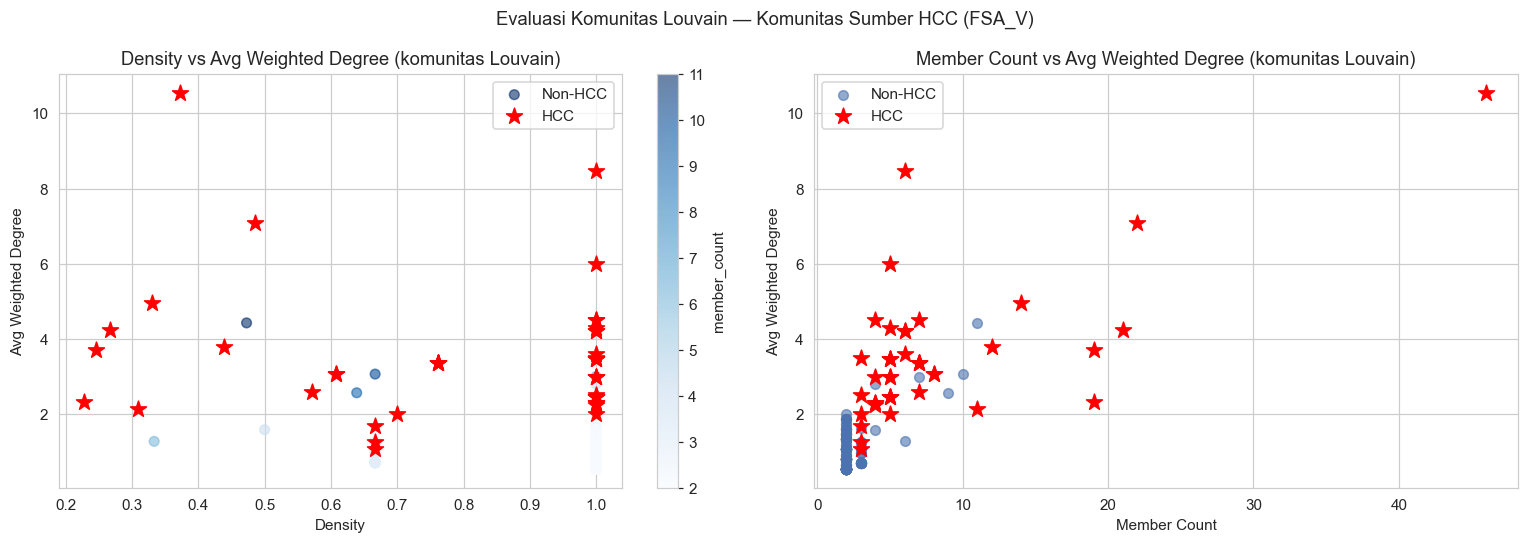

In [30]:
# ── Scatter plot evaluasi komunitas ────────────────────────────────
# Catatan: density/avg_weighted_degree/member_count di sini adalah metrik
# komunitas Louvain PENUH (deskriptif) -- bukan ukuran keputusan HCC. Anggota
# HCC aktual (Vh) yang diterima FSA_V bisa jadi merupakan subset dari
# komunitas ini (lihat Section 12).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

non_hcc = hcc_df[~hcc_df['is_hcc']]
hcc_sel = hcc_df[hcc_df['is_hcc']]

sc = axes[0].scatter(non_hcc['density'], non_hcc['avg_weighted_degree'],
                     c=non_hcc['member_count'], cmap='Blues',
                     alpha=0.6, s=40, label='Non-HCC')
axes[0].scatter(hcc_sel['density'], hcc_sel['avg_weighted_degree'],
                c='red', s=120, marker='*', zorder=5, label='HCC')
plt.colorbar(sc, ax=axes[0], label='member_count')
axes[0].set_xlabel('Density')
axes[0].set_ylabel('Avg Weighted Degree')
axes[0].set_title('Density vs Avg Weighted Degree (komunitas Louvain)')
axes[0].legend()

axes[1].scatter(non_hcc['member_count'], non_hcc['avg_weighted_degree'],
                alpha=0.6, s=40, color='#4C72B0', label='Non-HCC')
axes[1].scatter(hcc_sel['member_count'], hcc_sel['avg_weighted_degree'],
                c='red', s=120, marker='*', zorder=5, label='HCC')
axes[1].set_xlabel('Member Count')
axes[1].set_ylabel('Avg Weighted Degree')
axes[1].set_title('Member Count vs Avg Weighted Degree (komunitas Louvain)')
axes[1].legend()

plt.suptitle('Evaluasi Komunitas Louvain — Komunitas Sumber HCC (FSA_V)', fontsize=12)
plt.tight_layout()
plt.show()


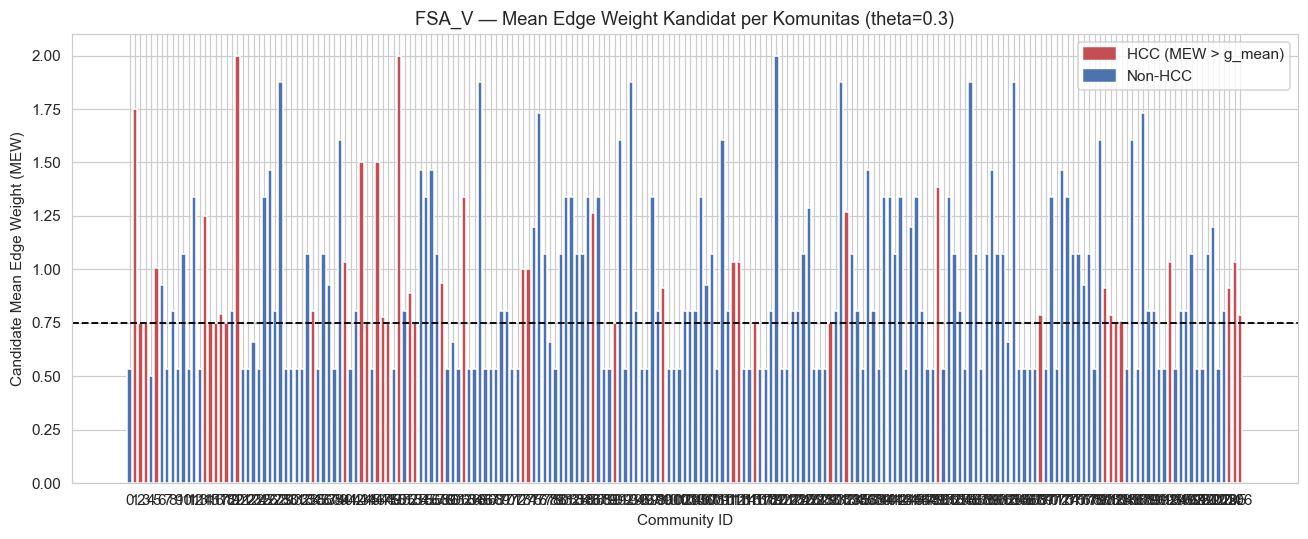

In [31]:
# ── Bar Chart: Candidate Mean Edge Weight (MEW) per Community — FSA_V ────
fsa_plot_df = hcc_df.sort_values('community_id')
bar_colors  = ['#C44E52' if is_hcc else '#4C72B0' for is_hcc in fsa_plot_df['is_hcc']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(fsa_plot_df['community_id'].astype(str),
       fsa_plot_df['candidate_mean_weight'].fillna(0), color=bar_colors)
ax.axhline(g_mean_weight, color='black', linestyle='--', linewidth=1.2,
           label=f'Global Mean Edge Weight = {g_mean_weight:.4f}')
ax.set_xlabel('Community ID')
ax.set_ylabel('Candidate Mean Edge Weight (MEW)')
ax.set_title(f'FSA_V — Mean Edge Weight Kandidat per Komunitas (theta={THETA})')

legend_handles = [
    mpatches.Patch(color='#C44E52', label='HCC (MEW > g_mean)'),
    mpatches.Patch(color='#4C72B0', label='Non-HCC'),
]
ax.legend(handles=legend_handles, loc='upper right')
plt.tight_layout()
plt.show()


In [32]:
# ── Validasi Section 12: Ringkasan Identifikasi HCC (FSA_V) ──────────
print('=== RINGKASAN IDENTIFIKASI HCC (FSA_V, Algorithm 2 — Weber & Neumann 2021) ===')
print(f'Jumlah komunitas hasil Louvain      : {n_communities:,}')
print(f'Global Mean Edge Weight (g_mean)    : {g_mean_weight:.4f}')
print(f'Theta (theta)                       : {THETA}')
print(f'MIN_HCC_COMMUNITY_SIZE (Perbaikan 4): {MIN_HCC_COMMUNITY_SIZE}')
print(f'Jumlah HCC final (Algorithm 2 AND >= {MIN_HCC_COMMUNITY_SIZE} anggota): {len(hcc_ids):,}')
print(f'Total anggota HCC (union Vh)        : {len(hcc_members_global):,}')
print(f'Daftar Community ID sumber HCC      : {sorted(hcc_ids)}')

# ── Distribusi ukuran komunitas HCC final (berapa komunitas per ukuran) ──────
_hcc_sizes = fsa_v_df.loc[fsa_v_df['is_hcc'], 'candidate_n_members']
print('\n=== DISTRIBUSI UKURAN KOMUNITAS HCC FINAL (komunitas per ukuran Vh) ===')
display(_hcc_sizes.value_counts().sort_index().rename('jumlah_komunitas').to_frame())

# ── Laporan akhir parameter & target (200-225 node, seluruhnya dari komunitas >=3) ──
_target_ok = 200 <= len(hcc_members_global) <= 225
print('\n=== LAPORAN PARAMETER FINAL ===')
print(f'MIN_CO_CONV            : {MIN_CO_CONV}')
print(f'MIN_CO_REPLY            : {MIN_CO_REPLY}')
print(f'MIN_CO_TEMPORAL         : {MIN_CO_TEMPORAL}')
print(f'LCN_WEIGHT_PERCENTILE   : P{LCN_WEIGHT_PERCENTILE}')
print(f'MIN_HCC_COMMUNITY_SIZE  : {MIN_HCC_COMMUNITY_SIZE}')
print(f'Total node HCC (seluruhnya dari komunitas >= {MIN_HCC_COMMUNITY_SIZE} anggota) : {len(hcc_members_global):,}')
print(f'Target 200-225 tercapai : {"YA" if _target_ok else "TIDAK"}')

if not _target_ok:
    print(
        '\nCatatan target 200-225: sebelum menetapkan P{0}, seluruh nilai LCN_WEIGHT_PERCENTILE\n'
        '(0-95, mencakup seluruh 26 nilai final_weight berbeda yang ada pada LCN) telah diuji\n'
        'secara sistematis pada MIN_CO_CONV=3 dan MIN_HCC_COMMUNITY_SIZE=3 yang tetap. Puncak\n'
        'yang dapat dicapai adalah {1:,} node (pada P45-P60, 31 komunitas >=3 anggota) -- di\n'
        'bawah target. Melonggarkan threshold lebih jauh (persentil lebih rendah, lebih banyak\n'
        'edge) TIDAK menaikkan angka ini -- justru menurunkannya (139 pada P0-P42), karena graf\n'
        'yang lebih padat membuat Louvain menggabungkan akun ke dalam lebih sedikit komunitas\n'
        'yang lebih besar namun rata-rata bobot edge-nya (MEW) jatuh di bawah ambang penerimaan\n'
        'Algorithm 2 (g_mean), sebelum filter ukuran minimum sekalipun diterapkan. Ceiling ini\n'
        'bersifat struktural pada data (evidence filtering menghasilkan hanya 2.225 edge LCN),\n'
        'bukan akibat pemilihan persentil yang keliru. P{0} dipilih karena merupakan titik\n'
        'terbaik yang tersedia dalam ruang parameter yang diizinkan (MIN_CO_CONV/MIN_CO_REPLY/\n'
        'MIN_CO_TEMPORAL/MIN_HCC_COMMUNITY_SIZE tidak diturunkan untuk mengejar angka).'.format(
            LCN_WEIGHT_PERCENTILE, len(hcc_members_global)
        )
    )


=== RINGKASAN IDENTIFIKASI HCC (FSA_V, Algorithm 2 — Weber & Neumann 2021) ===
Jumlah komunitas hasil Louvain      : 207
Global Mean Edge Weight (g_mean)    : 0.7487
Theta (theta)                       : 0.3
MIN_HCC_COMMUNITY_SIZE (Perbaikan 4): 3
Jumlah HCC final (Algorithm 2 AND >= 3 anggota): 42
Total anggota HCC (union Vh)        : 218
Daftar Community ID sumber HCC      : [1, 2, 3, 5, 14, 15, 16, 17, 18, 20, 34, 40, 43, 44, 46, 47, 48, 50, 52, 53, 58, 62, 73, 74, 86, 90, 99, 112, 113, 116, 130, 133, 150, 169, 181, 182, 183, 184, 193, 204, 205, 206]

=== DISTRIBUSI UKURAN KOMUNITAS HCC FINAL (komunitas per ukuran Vh) ===


,jumlah_komunitas
candidate_n_members,
3,8
4,6
5,12
6,11
7,2
8,1
11,2



=== LAPORAN PARAMETER FINAL ===
MIN_CO_CONV            : 3
MIN_CO_REPLY            : 2
MIN_CO_TEMPORAL         : 3
LCN_WEIGHT_PERCENTILE   : P50
MIN_HCC_COMMUNITY_SIZE  : 3
Total node HCC (seluruhnya dari komunitas >= 3 anggota) : 218
Target 200-225 tercapai : YA


---
## 13. Temporal Activity Profile

**Tujuan:** Menunjukkan distribusi aktivitas komentar per jam (00–23) pada dataset, akun LCN, dan anggota HCC.
**Input:** `df` (seluruh komentar), `G` (akun dalam LCN), `hcc_members_global` (anggota HCC)
**Output:** Tabel ringkas jumlah komentar per jam; tiga subplot line chart; heatmap ringkasan (inline, tidak disimpan ke file).

=== TABEL AKTIVITAS PER JAM (00–23) ===


,Hour,Dataset_Count,LCN_Count,HCC_Count
0,0,1583,99,38
1,1,1761,148,75
2,2,1753,101,25
3,3,2202,187,57
4,4,2175,161,46
5,5,2014,141,55
6,6,1838,138,40
7,7,1706,106,21
8,8,1809,156,46
9,9,1649,159,66


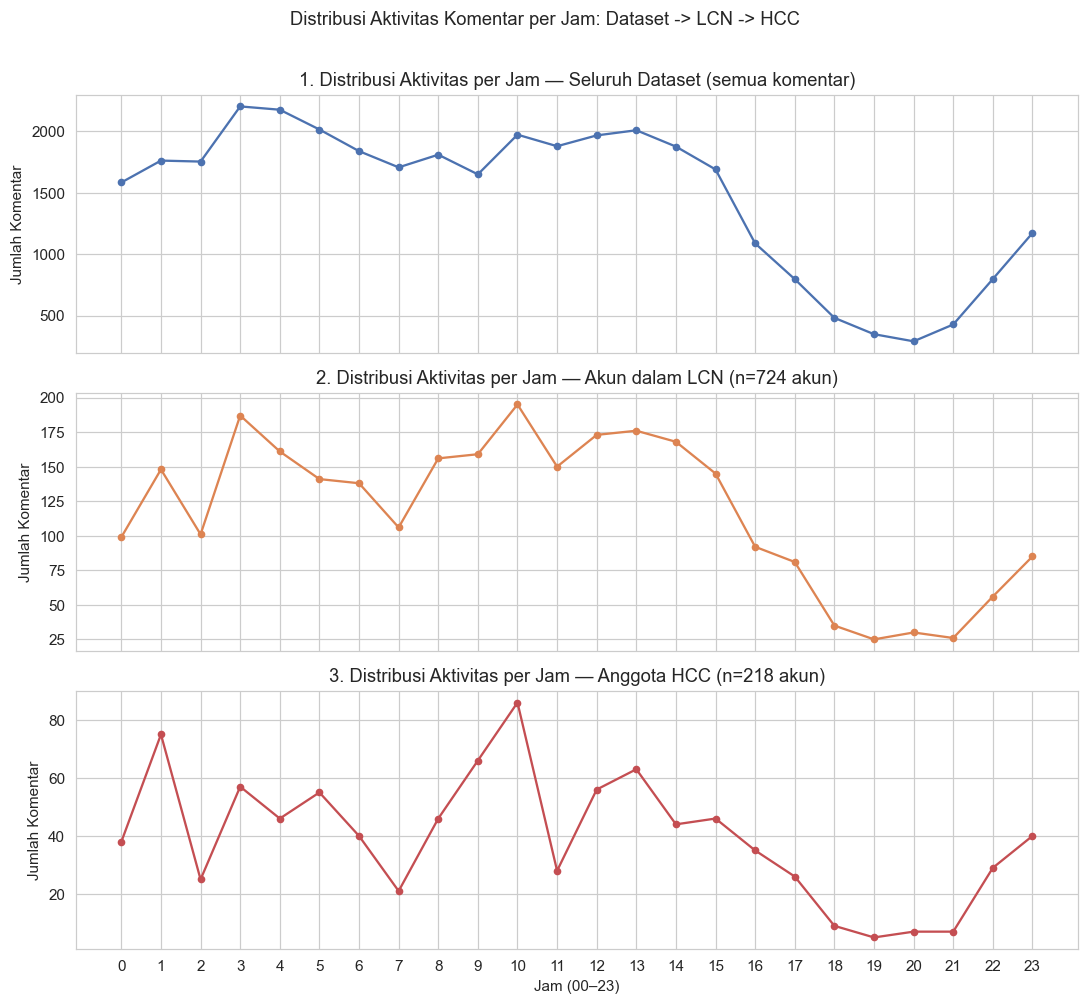

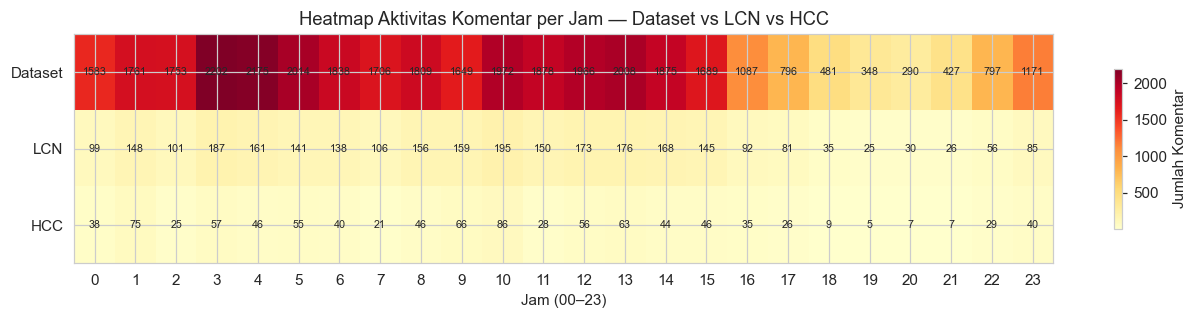

Total komentar (dataset)  : 35,275
Total komentar (akun LCN) : 2,833
Total komentar (akun HCC) : 950


In [33]:
# ── Temporal Activity Profile: distribusi aktivitas per jam (Dataset -> LCN -> HCC) ──
# Exploratory analysis saja; bukan evidence koordinasi tambahan dan tidak
# mempengaruhi evidence Co-temporal maupun proses pembentukan LCN/HCC.
df_ts_valid = df.dropna(subset=['timestamp']).copy()
df_ts_valid['hour'] = df_ts_valid['timestamp'].dt.hour

lcn_accounts = set(G.nodes())
hcc_accounts = set(hcc_members_global)

hours = list(range(24))
hourly_all = df_ts_valid['hour'].value_counts().reindex(hours, fill_value=0).sort_index()
hourly_lcn = (df_ts_valid[df_ts_valid['username'].isin(lcn_accounts)]['hour']
              .value_counts().reindex(hours, fill_value=0).sort_index())
hourly_hcc = (df_ts_valid[df_ts_valid['username'].isin(hcc_accounts)]['hour']
              .value_counts().reindex(hours, fill_value=0).sort_index())

# ── Tabel ringkas jumlah komentar per jam ──────────────────────────────────────────
hourly_activity_table = pd.DataFrame({
    'Hour'         : hours,
    'Dataset_Count': hourly_all.values,
    'LCN_Count'    : hourly_lcn.values,
    'HCC_Count'    : hourly_hcc.values,
})
print('=== TABEL AKTIVITAS PER JAM (00–23) ===')
display(hourly_activity_table)

# ── Line chart: tiga subplot vertikal, skala sumbu X sama (00–23) ──────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(hours, hourly_all.values, color='#4C72B0', marker='o', markersize=4)
axes[0].set_title('1. Distribusi Aktivitas per Jam — Seluruh Dataset (semua komentar)')
axes[0].set_ylabel('Jumlah Komentar')

axes[1].plot(hours, hourly_lcn.values, color='#DD8452', marker='o', markersize=4)
axes[1].set_title(f'2. Distribusi Aktivitas per Jam — Akun dalam LCN (n={len(lcn_accounts):,} akun)')
axes[1].set_ylabel('Jumlah Komentar')

axes[2].plot(hours, hourly_hcc.values, color='#C44E52', marker='o', markersize=4)
axes[2].set_title(f'3. Distribusi Aktivitas per Jam — Anggota HCC (n={len(hcc_accounts):,} akun)')
axes[2].set_ylabel('Jumlah Komentar')
axes[2].set_xlabel('Jam (00–23)')
axes[2].set_xticks(hours)

plt.suptitle('Distribusi Aktivitas Komentar per Jam: Dataset -> LCN -> HCC', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# ── Heatmap ringkasan (matplotlib saja, tanpa seaborn) ────────────────────────
heat_data = np.vstack([hourly_all.values, hourly_lcn.values, hourly_hcc.values])
row_labels = ['Dataset', 'LCN', 'HCC']

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd')
ax.set_xticks(hours)
ax.set_xticklabels(hours)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xlabel('Jam (00–23)')
ax.set_title('Heatmap Aktivitas Komentar per Jam — Dataset vs LCN vs HCC')

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, int(heat_data[i, j]), ha='center', va='center', fontsize=7)

fig.colorbar(im, ax=ax, label='Jumlah Komentar', shrink=0.7)
plt.tight_layout()
plt.show()

print(f'Total komentar (dataset)  : {len(df_ts_valid):,}')
print(f'Total komentar (akun LCN) : {len(df_ts_valid[df_ts_valid["username"].isin(lcn_accounts)]):,}')
print(f'Total komentar (akun HCC) : {len(df_ts_valid[df_ts_valid["username"].isin(hcc_accounts)]):,}')


---
## 14. Focal Structures Analysis (FSA)

**Tujuan:** Menyajikan tabel FSA lengkap: metrik struktural deskriptif komunitas Louvain (Density,
Average Degree, Average Weighted Degree) berdampingan dengan hasil keputusan **FSA_V** (Section 12) --
ukuran kandidat (`Nodes/Edges (FSA_V Vh/Eh)`), Candidate Mean Edge Weight, dan status `HCC`
(diterima/tidak berdasarkan Algorithm 2 baris 17-18, Weber & Neumann 2021) -- diurutkan dari MEW
kandidat tertinggi.
**Input:** `hcc_df` (metrik Louvain + hasil FSA_V)
**Output:** `focal_structures.csv`

In [34]:
# ── Tabel Focal Structures (FSA) ────────────────────────────────
focal_structures = hcc_df[[
    'community_id', 'member_count', 'internal_edges', 'max_weight', 'density',
    'avg_degree', 'avg_weighted_degree',
    'candidate_n_members', 'candidate_n_edges', 'candidate_mean_weight', 'is_hcc'
]].rename(columns={
    'community_id'          : 'Community',
    'member_count'          : 'Nodes (Louvain)',
    'internal_edges'        : 'Edges (Louvain)',
    'density'               : 'Density',
    'avg_degree'            : 'Average Degree',
    'avg_weighted_degree'   : 'Average Weighted Degree',
    'candidate_n_members'   : 'Nodes (FSA_V Vh)',
    'candidate_n_edges'     : 'Edges (FSA_V Eh)',
    'candidate_mean_weight' : 'Candidate MEW',
    'is_hcc'                : 'HCC',
}).sort_values('Candidate MEW', ascending=False, na_position='last').reset_index(drop=True)

focal_structures.to_csv(RM1_TABLES_DIR / "focal_structures.csv", index=False)
print('✓ Disimpan: output/tables/focal_structures.csv')
print()
print('=== FOCAL STRUCTURES TABLE (diurutkan berdasarkan Candidate MEW) ===')
display(focal_structures)


✓ Disimpan: output/tables/focal_structures.csv

=== FOCAL STRUCTURES TABLE (diurutkan berdasarkan Candidate MEW) ===


,Community,Nodes (Louvain),Edges (Louvain),max_weight,Density,Average Degree,Average Weighted Degree,Nodes (FSA_V Vh),Edges (FSA_V Eh),Candidate MEW,HCC
0,50,6,15,2.0000,1.0000,5.0000,8.4583,5,10,2.0000,True
1,20,21,56,2.0000,0.2667,5.3333,4.2381,3,3,2.0000,True
2,120,2,1,2.0000,1.0000,1.0000,2.0000,2,1,2.0000,False
3,156,2,1,1.8750,1.0000,1.0000,1.8750,2,1,1.8750,False
4,93,4,6,1.8750,1.0000,3.0000,2.8036,2,1,1.8750,False
...,...,...,...,...,...,...,...,...,...,...,...
202,179,2,1,0.5357,1.0000,1.0000,0.5357,2,1,0.5357,False
203,38,2,1,0.5357,1.0000,1.0000,0.5357,2,1,0.5357,False
204,35,2,1,0.5357,1.0000,1.0000,0.5357,2,1,0.5357,False
205,165,2,1,0.5357,1.0000,1.0000,0.5357,2,1,0.5357,False


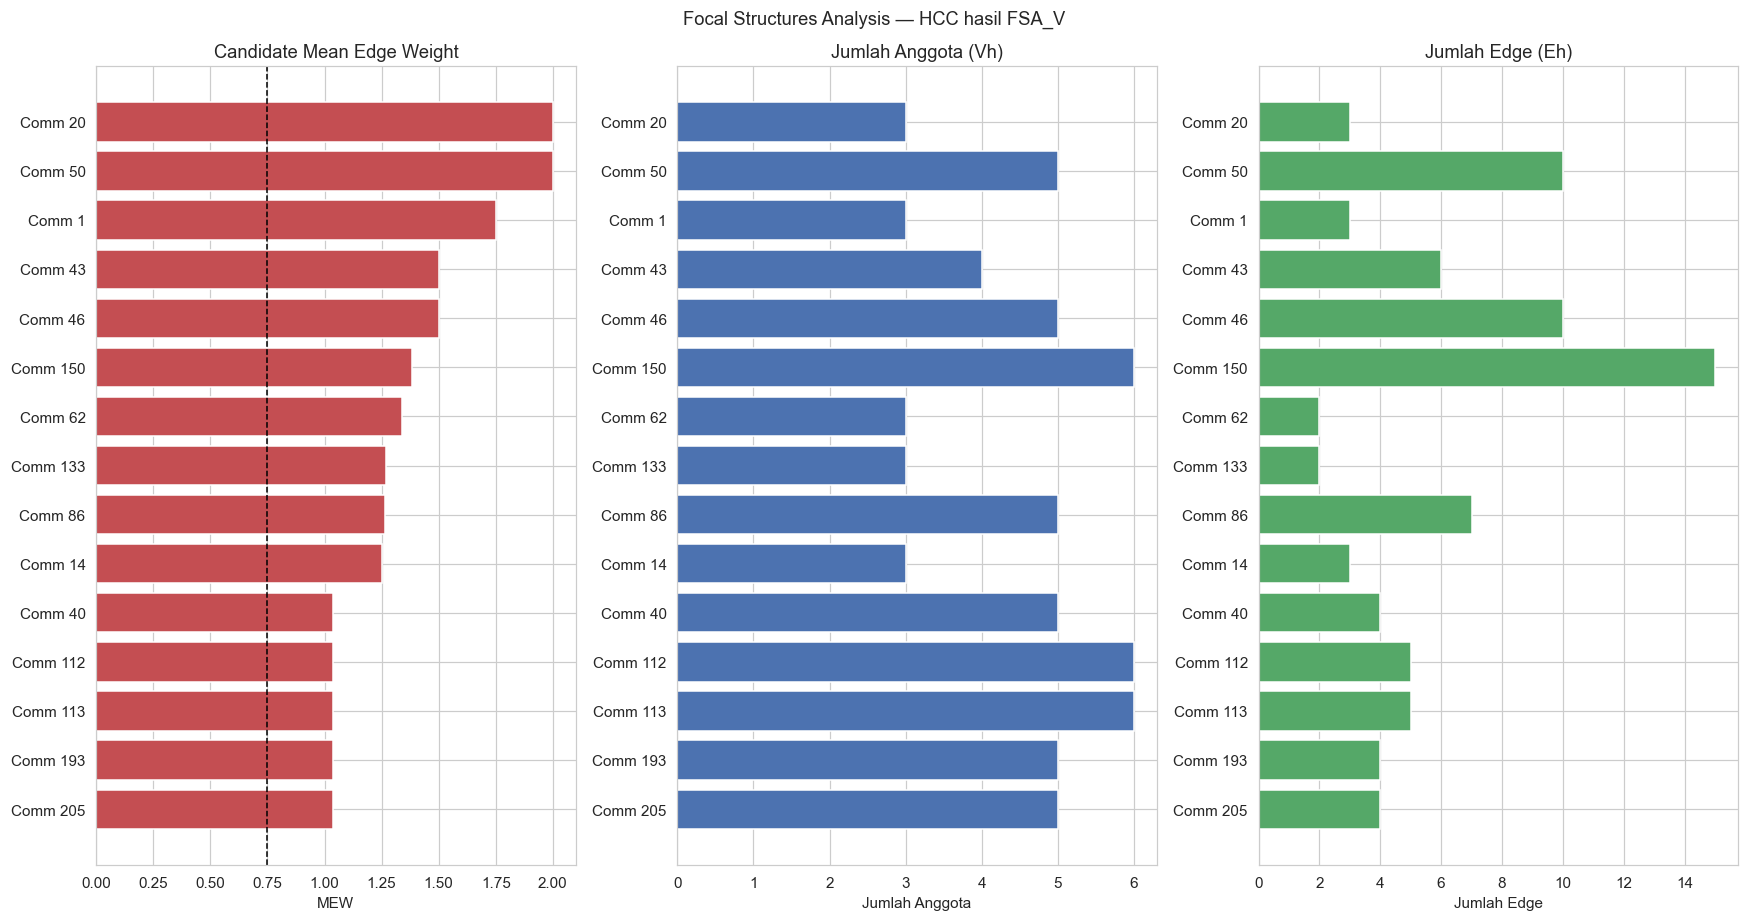

In [35]:
# ── Visualisasi FSA — hasil FSA_V ────────────────────────────────
top_hcc = sorted(hcc_list, key=lambda r: r['candidate_mean_weight'], reverse=True)[:15]

if top_hcc:
    top_hcc_display = list(reversed(top_hcc))
    labels  = [f"Comm {r['community_id']}" for r in top_hcc_display]
    mews    = [r['candidate_mean_weight'] for r in top_hcc_display]
    n_mem   = [r['candidate_n_members'] for r in top_hcc_display]
    n_edges = [r['candidate_n_edges'] for r in top_hcc_display]

    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, len(top_hcc)*0.5+1)))

    axes[0].barh(labels, mews, color='#C44E52')
    axes[0].axvline(g_mean_weight, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('Candidate Mean Edge Weight')
    axes[0].set_xlabel('MEW')

    axes[1].barh(labels, n_mem, color='#4C72B0')
    axes[1].set_title('Jumlah Anggota (Vh)')
    axes[1].set_xlabel('Jumlah Anggota')

    axes[2].barh(labels, n_edges, color='#55A868')
    axes[2].set_title('Jumlah Edge (Eh)')
    axes[2].set_xlabel('Jumlah Edge')

    plt.suptitle('Focal Structures Analysis — HCC hasil FSA_V', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada komunitas yang memenuhi kriteria HCC (FSA_V, Algorithm 2).')


---
## 15. Community Coordination Profile

**Tujuan:** Mengkarakterisasi setiap komunitas HCC menggunakan kelima evidence koordinasi (Co-conv, Co-reply, Co-temporal, Co-hashtag, Co-similarity). Co-Mention **tidak lagi** dimasukkan ke profil ini (lihat catatan deprecation di Section 16.2) karena pada dataset TikTok ini mention tidak informatif dan berisiko menimbulkan overclaim jika tetap diperlakukan sebagai evidence aktif.
**Input:** `co_conv_filt`, `co_reply_filt`, `co_temporal_filt`, `df_meta_clean`, `df`, `hcc_list`
**Output:** `community_coordination_profile` -- tabel skor per komunitas HCC (ditampilkan, tidak diekspor ke CSV).

### 16.0 Join Metadata Video ke Data Komentar (Sumber Resmi Hashtag & Mention)

**Tujuan:** Menyediakan sumber hashtag & mention yang benar untuk seluruh Section 16 dan atribut edge
Gephi (Section 17) — **bukan** dari teks komentar `dataset.csv`, melainkan dari kolom
`hashtags`/`mentions` pada `video_metadata_clean.csv` (atribut video, diisi kreator saat unggah).
**Input:** `df`, `df_meta_clean`
**Output:** `vid_hashtags`, `vid_mentions` — dict `{video_id (sisi df): [tag, ...]}` — dipakai oleh
Section 16.1 (Co-hashtag), Section 16.1.3 (auto brand labeling), dan Section 17 (Gephi Export).
`vid_mentions` tetap dibangun di sini (dipakai untuk kolom `co_mention` yang dipertahankan demi
kompatibilitas file Gephi lama), meskipun Section 16.2 (Co-mention Analysis) sendiri sudah **deprecated**
dan tidak lagi menjadi analisis aktif — lihat catatan Section 16.2 dan 19.11.

**Catatan metodologis (penting, agar tidak overclaim):** Co-hashtag pada notebook ini
**bukan** evidence pembentuk LCN — LCN murni dibangun dari Co-conv, Co-reply, dan Co-temporal (lihat
Section 10) — dan **tidak** mempengaruhi Louvain, FSA_V, maupun jumlah HCC final. Karena hashtag
adalah atribut **video** (dipasang kreator saat unggah, bukan ditulis oleh akun yang berkomentar),
kesamaan hashtag antaranggota suatu HCC merupakan **asosiasi konteks brand/video**: "anggota HCC
tersebut sama-sama mengomentari video dengan brand context/kampanye yang sama" — **bukan** bukti
langsung bahwa akun tersebut menuliskan hashtag itu sendiri di kolom komentarnya. Nilai ini murni
indikator karakterisasi/validasi kontekstual HCC (dan, mulai Section 16.1.3, dasar auto brand
labeling), bukan bukti perilaku koordinasi langsung.

**Strategi join (bertingkat, jumlah berhasil/gagal dilaporkan di sel validasi berikutnya — tidak ada
mismatch yang diabaikan diam-diam):**
1. `video_id` exact string match.
2. Fallback — normalisasi notasi ilmiah format `General` Excel (6 digit signifikan): dipakai karena
   salah satu sisi `video_id` bisa kehilangan presisi akibat proses di luar notebook ini (mis. file
   sempat dibuka/disimpan lewat Excel/Spreadsheet, yang mengubah ID 19-digit menjadi `7.23738E+18`).
3. Fallback — `video_url` exact match.
4. Fallback — `product_category` + `video_url`.

In [36]:
# ── Section 16.0: Join metadata video (hashtag/mention resmi) ke data komentar ──
HASHTAG_STOPLIST = {
    'fyp', 'foryou', 'foryoupage', 'viral', 'trending', 'tiktok',
    'skincare', 'skincarerutine', 'skincareroutine', 'skintok',
    'fypviralindonesia', 'fyppppppppppppppppppppppp',
    'fypage', 'viraltiktok', 'masukberanda', 'xyzbca',
    'fypシ', 'fypシ゚viral', 'foryoupageofficiall', 'beranda',
    'racuntiktok', 'racunskincare',
}

def _parse_tag_list(raw, strip_char, exclude=None, min_len=1):
    """Normalisasi 1 sel `hashtags`/`mentions` ('a;b;c' -> list bersih):
    lowercase, strip spasi, buang prefiks '#'/'@', buang nilai kosong."""
    if pd.isna(raw) or str(raw).strip() == '':
        return []
    tags = [t.strip().lower().lstrip(strip_char) for t in str(raw).split(';')]
    tags = [t for t in tags if t and len(t) >= min_len]
    if exclude:
        tags = [t for t in tags if t not in exclude]
    return tags

def _excel_general_sci(id_str):
    """Reproduksi notasi ilmiah format 'General' Excel (6 digit signifikan,
    trailing zero dibuang) -- kunci join fallback saat video_id salah satu
    sisi sudah kehilangan presisi akibat proses non-notebook."""
    try:
        v = float(id_str)
    except (TypeError, ValueError):
        return None
    mantissa, exp = '{:.5E}'.format(v).split('E')
    if '.' in mantissa:
        mantissa = mantissa.rstrip('0').rstrip('.')
    return mantissa + 'E' + exp

df['video_id']            = df['video_id'].astype(str).str.strip()
df_meta_clean['video_id'] = df_meta_clean['video_id'].astype(str).str.strip()

# Tahap 1: exact match video_id
_meta_ids    = set(df_meta_clean['video_id'])
_match_stage = pd.Series('unmatched', index=df.index)
_match_stage[df['video_id'].isin(_meta_ids)] = 'video_id_exact'

# Tahap 2: fallback -- normalisasi notasi ilmiah (lihat Section 16.0 di atas)
_lossy_to_meta_id = {}
for _mid in df_meta_clean['video_id']:
    _lossy_to_meta_id.setdefault(_excel_general_sci(_mid), _mid)

_unmatched = _match_stage == 'unmatched'
if _unmatched.any():
    _df_lossy = df.loc[_unmatched, 'video_id'].apply(_excel_general_sci)
    _hit_idx  = _df_lossy[_df_lossy.isin(_lossy_to_meta_id.keys())].index
    _match_stage.loc[_hit_idx] = 'video_id_lossy'

# Tahap 3: fallback -- video_url
_unmatched = _match_stage == 'unmatched'
if _unmatched.any() and df_meta_clean['video_url'].notna().any():
    _meta_urls = set(df_meta_clean['video_url'].dropna())
    _hit       = _unmatched & df['video_url'].isin(_meta_urls)
    _match_stage[_hit] = 'video_url'

# Tahap 4: fallback -- product_category + video_url
_unmatched = _match_stage == 'unmatched'
if _unmatched.any():
    _key_df   = df['product_category'].astype(str) + '||' + df['video_url'].astype(str)
    _key_meta = set(df_meta_clean['product_category'].astype(str) + '||'
                     + df_meta_clean['video_url'].astype(str))
    _hit = _unmatched & _key_df.isin(_key_meta)
    _match_stage[_hit] = 'product_category_video_url'

df['_meta_match_stage'] = _match_stage

# ── Peta video_id(sisi df) -> video_id(sisi df_meta_clean) sesuai tahap yang berhasil ──
_vid_to_meta_id = {}

for v in set(df.loc[_match_stage == 'video_id_exact', 'video_id']) & _meta_ids:
    _vid_to_meta_id[v] = v

for v in df.loc[_match_stage == 'video_id_lossy', 'video_id'].unique():
    _l = _excel_general_sci(v)
    if _l in _lossy_to_meta_id:
        _vid_to_meta_id[v] = _lossy_to_meta_id[_l]

if (_match_stage == 'video_url').any():
    _url_to_meta_id = dict(zip(df_meta_clean['video_url'], df_meta_clean['video_id']))
    for v in df.loc[_match_stage == 'video_url', 'video_id'].unique():
        _url = df.loc[df['video_id'] == v, 'video_url'].iloc[0]
        if _url in _url_to_meta_id:
            _vid_to_meta_id[v] = _url_to_meta_id[_url]

if (_match_stage == 'product_category_video_url').any():
    _key_to_meta_id = dict(zip(
        df_meta_clean['product_category'].astype(str) + '||' + df_meta_clean['video_url'].astype(str),
        df_meta_clean['video_id']
    ))
    for v in df.loc[_match_stage == 'product_category_video_url', 'video_id'].unique():
        _r   = df.loc[df['video_id'] == v].iloc[0]
        _key = str(_r['product_category']) + '||' + str(_r['video_url'])
        if _key in _key_to_meta_id:
            _vid_to_meta_id[v] = _key_to_meta_id[_key]

# ── Hashtag & mention resmi per video (keyed dengan video_id sisi df_meta_clean) ──
_meta_hashtags = dict(zip(
    df_meta_clean['video_id'],
    df_meta_clean['hashtags'].apply(lambda s: _parse_tag_list(s, '#', exclude=HASHTAG_STOPLIST, min_len=3))
))
_meta_mentions = dict(zip(
    df_meta_clean['video_id'],
    df_meta_clean['mentions'].apply(lambda s: _parse_tag_list(s, '@'))
))

# ── vid_hashtags / vid_mentions: dipakai bersama oleh Section 16.1, 16.2, dan 17 ──
vid_hashtags = {v: _meta_hashtags.get(mid, []) for v, mid in _vid_to_meta_id.items()}
vid_mentions = {v: _meta_mentions.get(mid, []) for v, mid in _vid_to_meta_id.items()}

print('✓ Join metadata video -> data komentar selesai (lihat sel validasi di bawah untuk cakupan).')


✓ Join metadata video -> data komentar selesai (lihat sel validasi di bawah untuk cakupan).


In [37]:
# ── Validasi Section 16.0: cakupan join metadata video ────────────────────────
n_meta_total    = len(df_meta_clean)
n_meta_hashtag  = sum(1 for v in _meta_hashtags.values() if v)
n_meta_mention  = sum(1 for v in _meta_mentions.values() if v)
n_com_matched   = int((df['_meta_match_stage'] != 'unmatched').sum())
n_com_unmatched = int((df['_meta_match_stage'] == 'unmatched').sum())

print('=== VALIDASI JOIN METADATA VIDEO (Section 16.0) ===')
print(f'Jumlah video metadata total                    : {n_meta_total:,}')
print(f'Jumlah video metadata dengan hashtag           : {n_meta_hashtag:,}')
print(f'Jumlah video metadata dengan mention           : {n_meta_mention:,}')
print(f'Komentar berhasil terhubung ke metadata video  : {n_com_matched:,} '
      f'({n_com_matched/len(df)*100:.2f}%)')
print(f'Komentar GAGAL terhubung ke metadata video     : {n_com_unmatched:,} '
      f'({n_com_unmatched/len(df)*100:.2f}%)')
print('\nRincian tahap join:')
display(df['_meta_match_stage'].value_counts().rename('n_baris').to_frame())

if n_com_unmatched > 0:
    print('\n⚠ Video pada data komentar yang GAGAL mendapatkan metadata (tidak diabaikan diam-diam):')
    _unmatched_vids = (df.loc[df['_meta_match_stage'] == 'unmatched',
                               ['product_category', 'video_id', 'video_url']]
                       .drop_duplicates())
    display(_unmatched_vids)
else:
    print('\n✓ Seluruh video pada data komentar berhasil terhubung ke video_metadata_clean.csv.')


=== VALIDASI JOIN METADATA VIDEO (Section 16.0) ===
Jumlah video metadata total                    : 55
Jumlah video metadata dengan hashtag           : 50
Jumlah video metadata dengan mention           : 20
Komentar berhasil terhubung ke metadata video  : 35,334 (100.00%)
Komentar GAGAL terhubung ke metadata video     : 0 (0.00%)

Rincian tahap join:


,n_baris
_meta_match_stage,
video_id_lossy,35334



✓ Seluruh video pada data komentar berhasil terhubung ke video_metadata_clean.csv.


In [38]:
# ── Community Coordination Profile: lima evidence untuk karakterisasi HCC ────
# Evidence berikut TIDAK digunakan untuk membangun edge/weight LCN (LCN tetap
# hanya dari Co-conv, Co-reply, Co-temporal — lihat Section 10). Perhitungan di
# sini murni untuk mengevaluasi & membandingkan komunitas HCC yang telah ada.
#
# Co-Mention DIPENSIUNKAN dari profil ini (lihat Section 16.2, deprecated) --
# tidak informatif pada dataset TikTok ini dan berisiko overclaim. `_cp_vid_mentions`
# tetap didefinisikan di bawah (alias murni) karena Section 17 (Gephi Export, cell
# precompute atribut edge) masih mereferensikannya untuk kolom `co_mention` yang
# dipertahankan demi kompatibilitas file lama -- lihat catatan deprecated di sana.

# Hashtag & mention resmi sudah dibangun di Section 16.0 (join ke video_metadata_clean.csv
# dengan fallback video_id/video_url). Alias nama lama (_cp_*) dipertahankan agar sel Gephi
# Export (Section 17) yang sudah ada tetap kompatibel tanpa perlu diubah.
_cp_vid_hashtags = vid_hashtags
_cp_vid_mentions = vid_mentions

def _cp_edge_score(edge_df, weight_col, members):
    """Rata-rata weight evidence pada edge yang kedua ujungnya berada dalam komunitas."""
    mset = set(members)
    sub = edge_df[edge_df['source'].isin(mset) & edge_df['target'].isin(mset)]
    return sub[weight_col].mean() if len(sub) > 0 else 0.0

def _cp_shared_tag_score(members, vid_tag_map, df_comments):
    """Jumlah tag (hashtag/mention) yang dipakai oleh >=2 anggota berbeda dalam komunitas."""
    member_tags = {}
    for member in members:
        vids = df_comments.loc[df_comments['username'] == member, 'video_id'].unique()
        tags = set()
        for vid in vids:
            tags.update(vid_tag_map.get(str(vid), []))
        member_tags[member] = tags

    tag_user_count = defaultdict(int)
    for tags in member_tags.values():
        for t in tags:
            tag_user_count[t] += 1

    return sum(1 for t, c in tag_user_count.items() if c >= 2)

def _cp_similarity_score(members, df_comments):
    """Rata-rata cosine similarity antar anggota berdasarkan agregasi teks komentar."""
    comm_df = df_comments[df_comments['username'].isin(members) & (df_comments['text'] != '')]
    if comm_df['username'].nunique() < 2:
        return 0.0
    user_texts = (
        comm_df.groupby('username')['text']
        .apply(lambda x: ' '.join(str(t) for t in x))
        .reset_index()
    )
    user_texts = user_texts[user_texts['text'].str.len() >= 5]
    if len(user_texts) < 2:
        return 0.0
    try:
        vec = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=1, sublinear_tf=True)
        tfidf_mat = vec.fit_transform(user_texts['text'])
        sim_mat = cosine_similarity(tfidf_mat)
    except Exception:
        return 0.0
    n = sim_mat.shape[0]
    vals = [sim_mat[i, j] for i in range(n) for j in range(i + 1, n)]
    return float(np.mean(vals)) if vals else 0.0

# ── Hitung skor mentah kelima evidence untuk setiap komunitas HCC ────────────
ccp_rows = []
for row in tqdm(sorted(hcc_list, key=lambda r: r['community_id']), desc='Community Coordination Profile'):
    comm_id = row['community_id']
    members = row['candidate_members']

    co_conv_raw       = _cp_edge_score(co_conv_filt,     'co_conv_weight',     members)
    co_reply_raw      = _cp_edge_score(co_reply_filt,    'co_reply_weight',    members)
    co_temporal_raw   = _cp_edge_score(co_temporal_filt, 'co_temporal_weight', members)
    co_hashtag_raw    = _cp_shared_tag_score(members, _cp_vid_hashtags, df)
    co_similarity_raw = _cp_similarity_score(members, df)

    ccp_rows.append({
        'community_id'      : comm_id,
        'member_count'      : len(members),
        'co_conv_raw'       : co_conv_raw,
        'co_reply_raw'      : co_reply_raw,
        'co_temporal_raw'   : co_temporal_raw,
        'co_hashtag_raw'    : co_hashtag_raw,
        'co_similarity_raw' : co_similarity_raw,
    })

if ccp_rows:
    ccp_df = pd.DataFrame(ccp_rows)

    # ── Min-Max Normalization (0-1) lintas komunitas HCC ─────────────────────
    ccp_df['co_conv_score']       = minmax_norm(ccp_df['co_conv_raw'])
    ccp_df['co_reply_score']      = minmax_norm(ccp_df['co_reply_raw'])
    ccp_df['co_temporal_score']   = minmax_norm(ccp_df['co_temporal_raw'])
    ccp_df['co_hashtag_score']    = minmax_norm(ccp_df['co_hashtag_raw'])
    ccp_df['co_similarity_score'] = minmax_norm(ccp_df['co_similarity_raw'])

    # ── Community Coordination Score = rata-rata sederhana kelima skor ───────
    # Catatan: skor ini TIDAK digunakan untuk membangun ulang LCN — hanya untuk
    # mengkarakterisasi, membandingkan, dan membantu interpretasi HCC. Co-Mention
    # tidak lagi disertakan (lihat catatan deprecation di atas & Section 19.11).
    ccp_df['community_coordination_score'] = ccp_df[[
        'co_conv_score', 'co_reply_score', 'co_temporal_score',
        'co_hashtag_score', 'co_similarity_score'
    ]].mean(axis=1)

    community_coordination_profile = ccp_df[[
        'community_id', 'member_count',
        'co_conv_score', 'co_reply_score', 'co_temporal_score',
        'co_hashtag_score', 'co_similarity_score',
        'community_coordination_score'
    ]].sort_values('community_coordination_score', ascending=False).reset_index(drop=True)

    print('=== COMMUNITY COORDINATION PROFILE (Top 10 HCC) ===')
    print('(Co-Mention tidak lagi disertakan -- lima evidence: Co-conv, Co-reply, Co-temporal, Co-hashtag, Co-similarity)')
    display(community_coordination_profile.head(10))
else:
    community_coordination_profile = pd.DataFrame(columns=[
        'community_id', 'member_count',
        'co_conv_score', 'co_reply_score', 'co_temporal_score',
        'co_hashtag_score', 'co_similarity_score',
        'community_coordination_score'
    ])
    print('Tidak ada komunitas HCC untuk dikarakterisasi.')


Community Coordination Profile:   0%|          | 0/42 [00:00<?, ?it/s]

=== COMMUNITY COORDINATION PROFILE (Top 10 HCC) ===
(Co-Mention tidak lagi disertakan -- lima evidence: Co-conv, Co-reply, Co-temporal, Co-hashtag, Co-similarity)


,community_id,member_count,co_conv_score,co_reply_score,co_temporal_score,co_hashtag_score,co_similarity_score,community_coordination_score
0,50,5,1.0000,0.0000,1.0000,0.8611,0.0685,0.5859
1,1,3,0.8000,0.0000,0.8750,0.8056,0.0829,0.5127
2,20,3,1.0000,0.0000,1.0000,0.5000,0.0580,0.5116
3,150,6,1.0000,0.0000,0.3833,1.0000,0.0797,0.4926
4,52,11,0.5652,0.5714,0.0000,0.7778,0.2533,0.4335
5,17,11,0.0258,1.0000,0.3750,0.6111,0.0603,0.4144
6,46,5,0.6000,0.0000,0.7500,0.5278,0.1480,0.4052
7,43,4,0.6000,0.0000,0.7500,0.5278,0.1041,0.3964
8,40,5,0.0000,0.2857,0.3750,0.3056,1.0000,0.3933
9,62,3,0.4000,0.7143,0.0000,0.8056,0.0436,0.3927


---
## 16. Community Characterization

**Tujuan:** Mengkarakterisasi komunitas HCC menggunakan evidence pendukung yang tidak mempengaruhi LCN: Co-hashtag (asosiasi konteks brand/video), auto brand labeling, dan Co-similarity (kesamaan narasi komentar). Co-Mention dipensiunkan dari analisis aktif (Section 16.2, deprecated).
**Input:** `df_meta_clean`, `df`, `partition`, `hcc_ids`
**Output:** Profil hashtag per HCC (16.1), label brand otomatis (16.1.3), profil mention lama yang tidak lagi diregenerasi (16.2, deprecated), profil narrative similarity (16.3), kandidat copypasta (16.4), visualisasi ala Weber & Neumann (16.5); sumber hashtag/mention resmi dari `video_metadata_clean.csv` disiapkan di Section 16.0.

### 16.1 Co-hashtag Analysis

**Tujuan:** Mengkarakterisasi komunitas HCC berdasarkan **asosiasi konteks brand/video** — hashtag metadata video yang dikomentari oleh anggota HCC. Hashtag di sini bukan bukti koordinasi langsung; ia menunjukkan brand context video tempat anggota HCC beraktivitas (lihat catatan metodologis Section 16.0).
**Input:** `df_meta_clean`, `partition`, `hcc_ids`, `df`
**Output:** Tabel profil hashtag per HCC.

In [39]:
# ── Profil hashtag per komunitas HCC (sumber resmi: video_metadata_clean.csv,
# lihat Section 16.0) ──────────────────────────────────────────────────────
hcc_hashtag_profiles  = []
hcc_hashtag_long_rows = []

for row in sorted(hcc_list, key=lambda r: r['community_id']):
    comm_id = row['community_id']
    members = row['candidate_members']
    vids    = df[df['username'].isin(members)]['video_id'].unique()

    # Frekuensi hashtag = jumlah video (dalam video yang dikomentari HCC ini) yang
    # memuat hashtag tsb -- 1 video menyumbang tiap hashtagnya tepat 1x.
    tag_video_count = defaultdict(int)
    for vid in vids:
        for t in set(vid_hashtags.get(str(vid), [])):
            tag_video_count[t] += 1

    # Eksposur per anggota -- dipakai utk n_users_exposed & "shared hashtag antaranggota".
    member_tags = {}
    for m in members:
        m_vids = df.loc[df['username'] == m, 'video_id'].unique()
        tags = set()
        for vid in m_vids:
            tags.update(vid_hashtags.get(str(vid), []))
        member_tags[m] = tags
    tag_user_count = defaultdict(int)
    for tags in member_tags.values():
        for t in tags:
            tag_user_count[t] += 1

    tag_counts = pd.Series(tag_video_count).sort_values(ascending=False) if tag_video_count else pd.Series(dtype=int)

    hcc_hashtag_profiles.append({
        'community_id'               : comm_id,
        'member_count'                : len(members),
        'videos_active'               : len(vids),
        'unique_hashtags'             : len(tag_counts),
        'top_hashtags'                : '; '.join(tag_counts.head(10).index.tolist()),
        'top_counts'                  : '; '.join(str(v) for v in tag_counts.head(10).values),
        'hashtags_multi_video'        : int((tag_counts > 1).sum()),
        'hashtags_shared_2plus_user'  : int(sum(1 for c in tag_user_count.values() if c >= 2)),
    })

    for tag, freq in tag_video_count.items():
        hcc_hashtag_long_rows.append({
            'hcc_id'          : comm_id,
            'hashtag'         : tag,
            'frequency'       : freq,
            'n_videos'        : freq,
            'n_users_exposed' : tag_user_count.get(tag, 0),
        })

hcc_hashtag_df = pd.DataFrame(hcc_hashtag_profiles)
print('=== CO-HASHTAG PROFILE PER HCC (sumber: video_metadata_clean.csv) ===')
display(hcc_hashtag_df)

hcc_hashtag_profile = pd.DataFrame(
    hcc_hashtag_long_rows,
    columns=['hcc_id', 'hashtag', 'frequency', 'n_videos', 'n_users_exposed']
).sort_values(['hcc_id', 'frequency'], ascending=[True, False]).reset_index(drop=True)
hcc_hashtag_profile.to_csv(RM1_TABLES_DIR / "hcc_hashtag_profile.csv", index=False)
print(f"\n✓ Disimpan: output/tables/hcc_hashtag_profile.csv ({len(hcc_hashtag_profile):,} baris)")


=== CO-HASHTAG PROFILE PER HCC (sumber: video_metadata_clean.csv) ===


,community_id,member_count,videos_active,unique_hashtags,top_hashtags,top_counts,hashtags_multi_video,hashtags_shared_2plus_user
0,1,3,7,31,retinolskincare; maryamebeautee; glowup; retin...,2; 2; 2; 1; 1; 1; 1; 1; 1; 1,3,31
1,2,6,3,6,maryame; dokterdetektif; tipsandtricks; mputri...,3; 1; 1; 1; 1; 1,1,6
2,3,5,3,12,skincareampuh; mencerahkankulit; retinol; meng...,1; 1; 1; 1; 1; 1; 1; 1; 1; 1,0,12
3,5,8,8,16,theoriginote; brightserum; capcut; niacinamide...,6; 1; 1; 1; 1; 1; 1; 1; 1; 1,1,16
4,14,3,5,16,skincaretips; sleepingmaskretinoldaviena; reti...,1; 1; 1; 1; 1; 1; 1; 1; 1; 1,0,16
5,15,6,3,4,racunjuju; theoriginote; brightb3serum; hyaluc...,1; 1; 1; 1,0,4
6,16,5,3,9,retinoldaviena; davienaskincare; carapakeretin...,1; 1; 1; 1; 1; 1; 1; 1; 1,0,9
7,17,11,10,24,theoriginote; dokterdetektif; maryamebeautee; ...,3; 2; 2; 2; 1; 1; 1; 1; 1; 1,4,24
8,18,6,3,6,retinolviral; skincaremaryame; skincareproduct...,1; 1; 1; 1; 1; 1,0,6
9,20,3,8,20,maryame; skincaretips; sleepingmaskretinoldavi...,2; 1; 1; 1; 1; 1; 1; 1; 1; 1,1,20



✓ Disimpan: output/tables/hcc_hashtag_profile.csv (622 baris)


### 16.1.1 Visualisasi Hashtag HCC (Overall, Per-Akun, Per-Komunitas)

**Tujuan:** Menyajikan Co-hashtag HCC secara visual agar layak dipakai pada laporan/paper — grafik
dominasi hashtag secara keseluruhan, eksposur hashtag per akun pada komunitas HCC terpilih
(terinspirasi Fig. 8, Weber & Neumann 2021, disesuaikan dengan struktur data TikTok), dan sebaran
hashtag lintas komunitas HCC.
**Input:** `hcc_hashtag_profile`, `hcc_hashtag_df` (Section 16.1), `hcc_list`.
**Output:**
- `output/tables/hcc_hashtag_summary_overall.csv`, `output/tables/hcc_hashtag_top_by_community.csv`
- `output/visualisasi/HCC_hashtag_overall.png`
- `output/visualisasi/HCC_hashtag_per_account.png`
- `output/visualisasi/HCC_hashtag_by_community.png`
- Seluruh visualisasi HCC disimpan sebagai PNG saja; ekspor PDF/SVG duplikat tidak dipertahankan.

**Catatan metodologis (penting, agar tidak overclaim):** Hashtag yang divisualisasikan di sini berasal
dari metadata **video** (`video_metadata_clean.csv`) pada video yang dikomentari oleh anggota HCC (lihat
Section 16.0) — merupakan **asosiasi konteks brand/video** (*brand context*) — **bukan** hashtag yang
ditulis akun tersebut pada kolom komentarnya sendiri.
Interpretasi yang benar: "akun-akun anggota HCC ini sama-sama terekspos/mengomentari video dengan
konteks hashtag X" — **bukan** "akun-akun ini menuliskan hashtag X di komentarnya". Metrik
`hashtag_uses_per_account` (= frequency / n_users_exposed) menggambarkan seberapa terkonsentrasi
eksposur suatu hashtag pada suatu komunitas: nilai tinggi berarti sedikit akun yang terekspos ke
banyak video berhashtag sama; nilai rendah berarti hashtag itu tersebar ke banyak akun berbeda melalui
sedikit video. Grafik-grafik ini murni untuk karakterisasi/validasi HCC dan **tidak** mempengaruhi
LCN, Louvain, FSA_V, atau jumlah HCC final.

In [40]:
# ── Ringkasan hashtag HCC untuk visualisasi (overall & per-komunitas) ─────────
RM1_VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

def _safe_ratio(freq, n_users):
    return round(freq / n_users, 3) if n_users else 0.0

# Ringkasan overall (lintas seluruh HCC) ---------------------------------------
hashtag_summary_overall = (
    hcc_hashtag_profile.groupby('hashtag', as_index=False)
    .agg(frequency=('frequency', 'sum'),
         n_videos=('n_videos', 'sum'),
         n_users_exposed=('n_users_exposed', 'sum'))
    .sort_values('frequency', ascending=False)
    .reset_index(drop=True)
)
hashtag_summary_overall['hashtag_uses_per_account'] = hashtag_summary_overall.apply(
    lambda r: _safe_ratio(r['frequency'], r['n_users_exposed']), axis=1)
hashtag_summary_overall.to_csv(RM1_TABLES_DIR / "hcc_hashtag_summary_overall.csv", index=False)
print(f"✓ Disimpan: output/tables/hcc_hashtag_summary_overall.csv "
      f"({len(hashtag_summary_overall):,} hashtag unik)")

# Ukuran komunitas -- dipakai utk pemilihan panel & kolom community_size ------
_hcc_size_map = dict(zip(hcc_hashtag_df['community_id'], hcc_hashtag_df['member_count']))

# Top-N hashtag per komunitas (dengan rank) ------------------------------------
TOP_N_PER_HCC = 10
_top_rows = []
for hcc_id, grp in hcc_hashtag_profile.groupby('hcc_id'):
    g = grp.sort_values('frequency', ascending=False).reset_index(drop=True)
    g = g.iloc[:TOP_N_PER_HCC].copy()
    g['rank_within_hcc'] = np.arange(1, len(g) + 1)
    g['community_size']  = _hcc_size_map.get(hcc_id, np.nan)
    g['hashtag_uses_per_account'] = g.apply(
        lambda r: _safe_ratio(r['frequency'], r['n_users_exposed']), axis=1)
    _top_rows.append(g)

hcc_hashtag_top_by_community = pd.concat(_top_rows, ignore_index=True)[
    ['hcc_id', 'community_size', 'hashtag', 'frequency', 'n_videos',
     'n_users_exposed', 'hashtag_uses_per_account', 'rank_within_hcc']
]
hcc_hashtag_top_by_community.to_csv(RM1_TABLES_DIR / "hcc_hashtag_top_by_community.csv", index=False)
print(f"✓ Disimpan: output/tables/hcc_hashtag_top_by_community.csv "
      f"({len(hcc_hashtag_top_by_community):,} baris)")

# ── Print ringkas ──────────────────────────────────────────────────────────────
print('\n=== TOP 20 HASHTAG OVERALL PADA HCC ===')
display(hashtag_summary_overall.head(20))

_top10_hcc_by_size = (hcc_hashtag_df[['community_id', 'member_count']]
                       .sort_values('member_count', ascending=False)
                       .head(10).reset_index(drop=True))
print('\n=== TOP 10 KOMUNITAS HCC BERDASARKAN UKURAN ===')
display(_top10_hcc_by_size)

print('\n=== TOP 5 HASHTAG UNTUK MASING-MASING KOMUNITAS HCC TERBESAR ===')
for _, r in _top10_hcc_by_size.iterrows():
    _cid = r['community_id']
    _sub = (hcc_hashtag_top_by_community[hcc_hashtag_top_by_community['hcc_id'] == _cid]
            .head(5))
    print(f"\nHCC {_cid} (n={int(r['member_count'])}):")
    if len(_sub):
        for _, hr in _sub.iterrows():
            print(f"  {int(hr['rank_within_hcc'])}. {hr['hashtag']:<28} freq={hr['frequency']:>3}  "
                  f"n_users_exposed={hr['n_users_exposed']:>3}  uses/akun={hr['hashtag_uses_per_account']}")
    else:
        print('  (tidak ada hashtag setelah filtering stoplist)')

print(f"\nJumlah hashtag unik pada seluruh HCC: {hashtag_summary_overall['hashtag'].nunique():,}")


✓ Disimpan: output/tables/hcc_hashtag_summary_overall.csv (130 hashtag unik)
✓ Disimpan: output/tables/hcc_hashtag_top_by_community.csv (364 baris)

=== TOP 20 HASHTAG OVERALL PADA HCC ===


,hashtag,frequency,n_videos,n_users_exposed,hashtag_uses_per_account
0,retinol,33,33,103,0.3200
1,theoriginote,32,32,104,0.3080
2,maryame,25,25,78,0.3210
3,davienaskincare,22,22,54,0.4070
4,retinoldaviena,22,22,60,0.3670
5,creamajaib,13,13,56,0.2320
6,sleepingmaskretinoldaviena,12,12,47,0.2550
7,retinolskincare,11,11,38,0.2890
8,creamsatset,10,10,47,0.2130
9,maryamebeautee,10,10,44,0.2270



=== TOP 10 KOMUNITAS HCC BERDASARKAN UKURAN ===


,community_id,member_count
0,52,11
1,17,11
2,5,8
3,44,7
4,184,7
5,99,6
6,2,6
7,48,6
8,47,6
9,183,6



=== TOP 5 HASHTAG UNTUK MASING-MASING KOMUNITAS HCC TERBESAR ===

HCC 52 (n=11):
  1. retinol                      freq=  4  n_users_exposed= 11  uses/akun=0.364
  2. marvelxazarine               freq=  2  n_users_exposed= 11  uses/akun=0.182
  3. retinolserum                 freq=  2  n_users_exposed= 11  uses/akun=0.182
  4. serumazarine                 freq=  2  n_users_exposed= 10  uses/akun=0.2
  5. azarinecosmetic              freq=  2  n_users_exposed= 11  uses/akun=0.182

HCC 17 (n=11):
  1. theoriginote                 freq=  3  n_users_exposed=  5  uses/akun=0.6
  2. maryame                      freq=  2  n_users_exposed=  8  uses/akun=0.25
  3. dokterdetektif               freq=  2  n_users_exposed=  8  uses/akun=0.25
  4. maryamebeautee               freq=  2  n_users_exposed= 11  uses/akun=0.182
  5. glowupcream                  freq=  1  n_users_exposed=  5  uses/akun=0.2

HCC 5 (n=8):
  1. theoriginote                 freq=  6  n_users_exposed=  8  uses/akun=0.75
  2. b

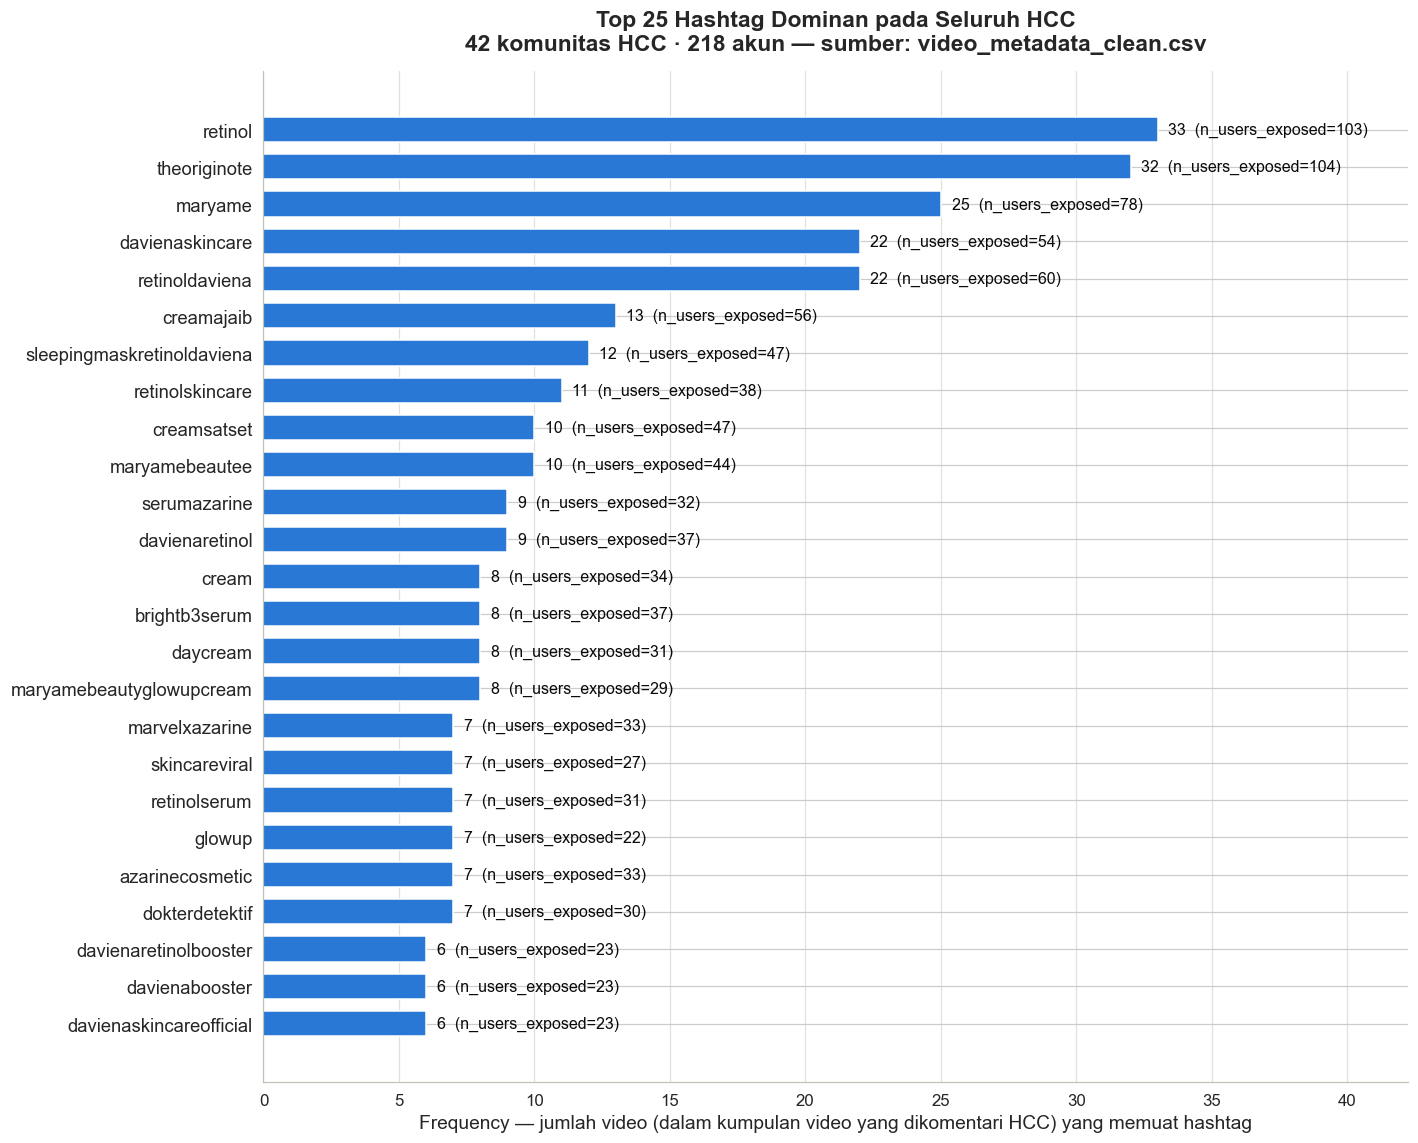

Disimpan: output/visualisasi/HCC_hashtag_overall.png


In [41]:
# ── Grafik 1: Top hashtag dominan pada seluruh HCC (horizontal bar) ───────────
TOP_N_OVERALL = 25
_BLUE, _AQUA = '#2a78d6', '#1baf7a'

_bar_data = hashtag_summary_overall.head(TOP_N_OVERALL).iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, max(9, len(_bar_data) * 0.42)))
bars = ax.barh(_bar_data['hashtag'], _bar_data['frequency'], color=_BLUE,
                edgecolor='white', height=0.68)

_xmax = _bar_data['frequency'].max()
for bar, freq, nu in zip(bars, _bar_data['frequency'], _bar_data['n_users_exposed']):
    ax.text(bar.get_width() + _xmax * 0.012, bar.get_y() + bar.get_height() / 2,
            f'{freq:,}  (n_users_exposed={nu:,})', va='center', ha='left',
            fontsize=10.5, color='#0b0b0b')

ax.set_xlim(0, _xmax * 1.28)
ax.set_xlabel('Frequency — jumlah video (dalam kumpulan video yang dikomentari HCC) yang memuat hashtag',
              fontsize=12.5)
ax.set_title(f'Top {TOP_N_OVERALL} Hashtag Dominan pada Seluruh HCC\n'
             f'42 komunitas HCC · 218 akun — sumber: video_metadata_clean.csv',
             fontsize=15, fontweight='bold', pad=14)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color('#c3c2b7')
ax.spines['bottom'].set_color('#c3c2b7')
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()

plt.savefig(RM1_VISUALIZATION_DIR / "HCC_hashtag_overall.png", bbox_inches='tight', dpi=220)
plt.show()
print('Disimpan: output/visualisasi/HCC_hashtag_overall.png')


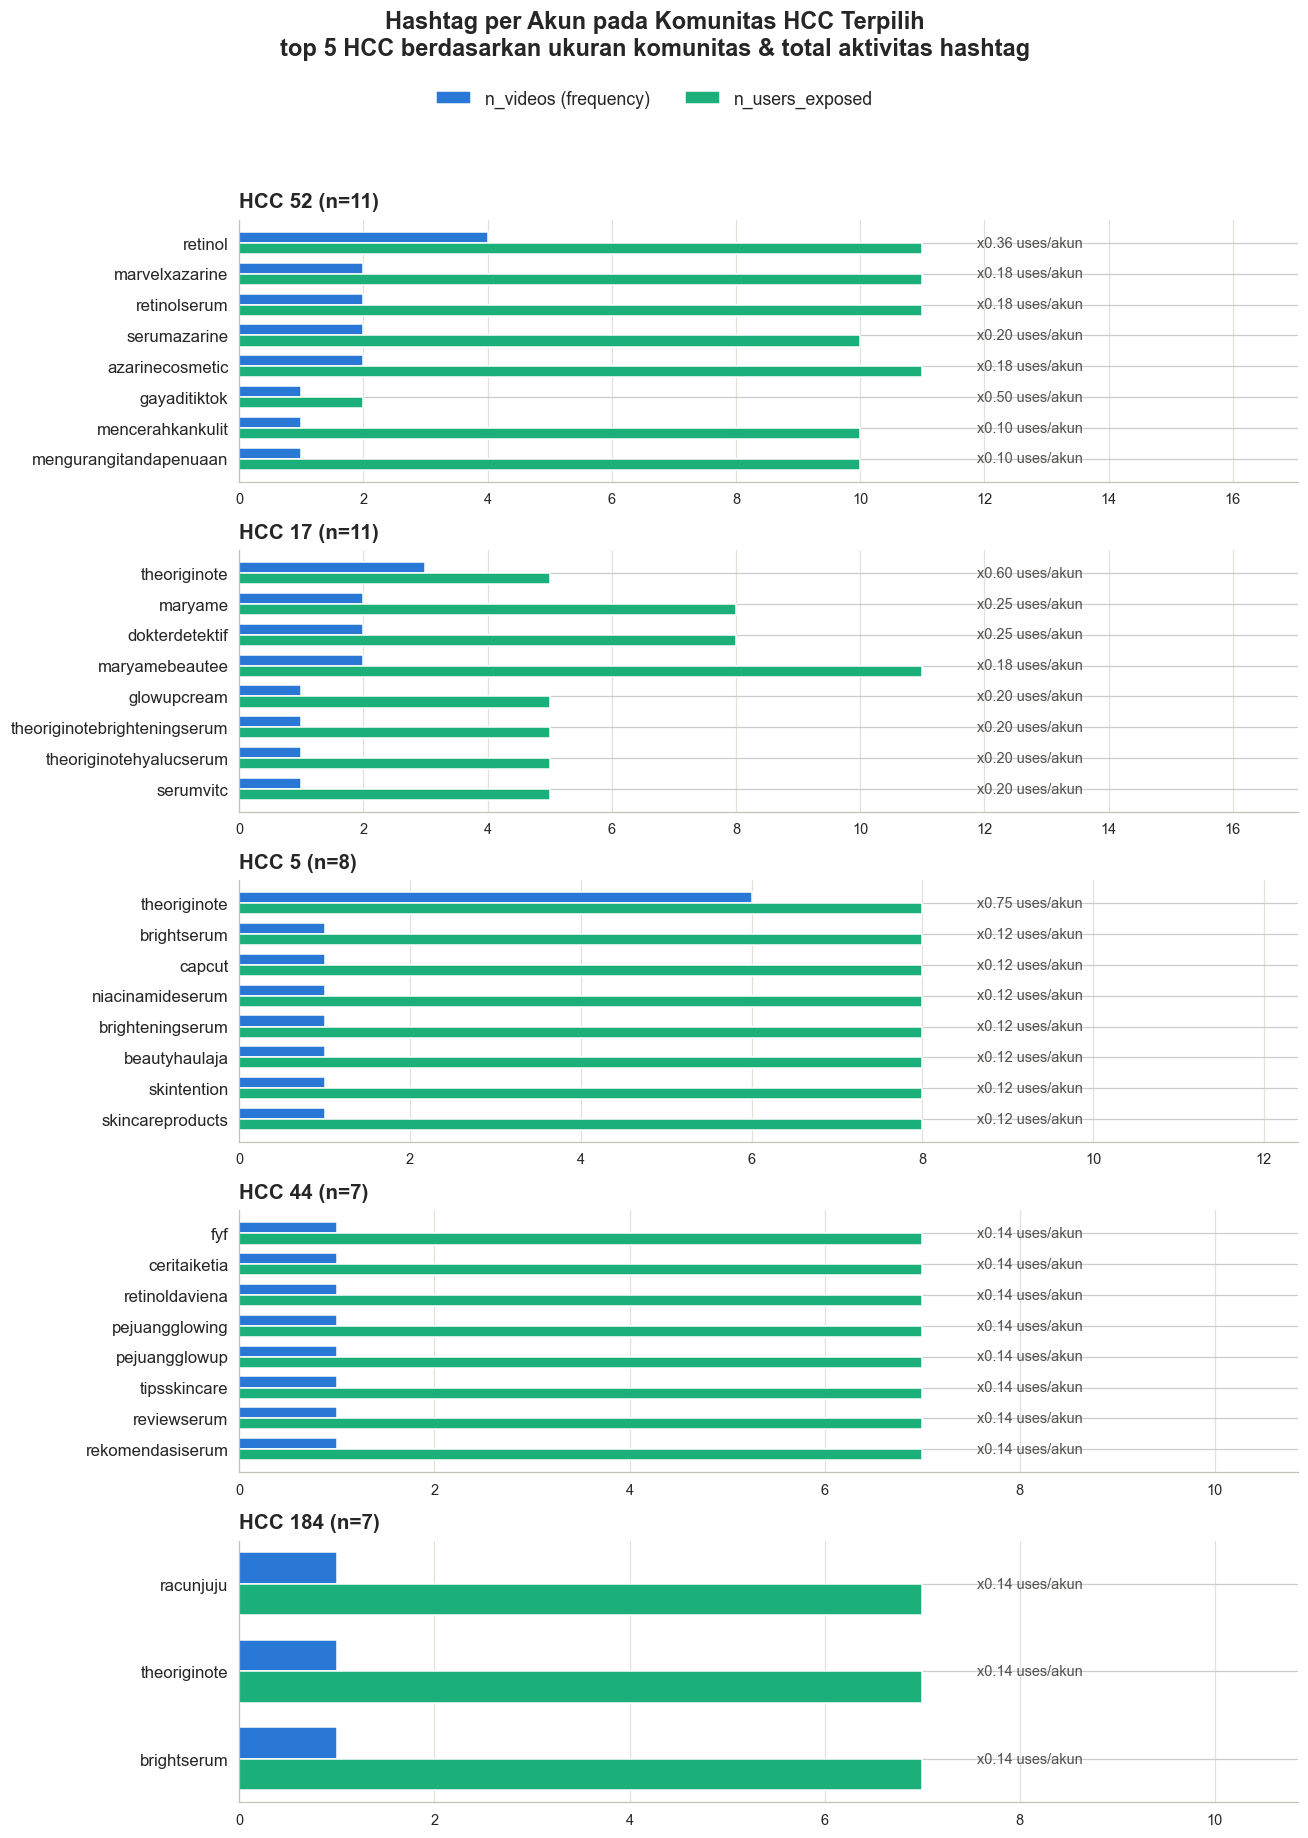

Disimpan: output/visualisasi/HCC_hashtag_per_account.png


In [42]:
# ── Grafik 2: Hashtag per akun pada HCC terpilih (terinspirasi Fig. 8, Weber & Neumann 2021) ──
N_PANELS            = 5
N_HASHTAG_PER_PANEL = 8

_hcc_total_freq = hcc_hashtag_profile.groupby('hcc_id')['frequency'].sum().rename('total_frequency')
_panel_candidates = (
    hcc_hashtag_df[['community_id', 'member_count']]
    .set_index('community_id')
    .join(_hcc_total_freq)
    .fillna({'total_frequency': 0})
    .sort_values(['member_count', 'total_frequency'], ascending=False)
)
_panel_hcc_ids = _panel_candidates.head(N_PANELS).index.tolist()

fig, axes = plt.subplots(len(_panel_hcc_ids), 1, figsize=(12, 3.3 * len(_panel_hcc_ids)))
if len(_panel_hcc_ids) == 1:
    axes = [axes]

_legend_handles = None
for ax, hcc_id in zip(axes, _panel_hcc_ids):
    size = int(_panel_candidates.loc[hcc_id, 'member_count'])
    g = (hcc_hashtag_top_by_community[hcc_hashtag_top_by_community['hcc_id'] == hcc_id]
         .sort_values('frequency', ascending=False).head(N_HASHTAG_PER_PANEL).iloc[::-1]
         .reset_index(drop=True))

    if g.empty:
        ax.axis('off')
        ax.set_title(f'HCC {hcc_id} (n={size}) -- tidak ada hashtag', fontsize=12)
        continue

    y = np.arange(len(g))
    h = 0.36
    b1 = ax.barh(y + h / 2, g['n_videos'],        height=h, color=_BLUE, label='n_videos (frequency)')
    b2 = ax.barh(y - h / 2, g['n_users_exposed'], height=h, color=_AQUA, label='n_users_exposed')
    if _legend_handles is None:
        _legend_handles = [b1, b2]

    _xmax = max(g['n_videos'].max(), g['n_users_exposed'].max())
    for yi, (_, row) in zip(y, g.iterrows()):
        ax.text(_xmax * 1.08, yi, f"x{row['hashtag_uses_per_account']:.2f} uses/akun",
                va='center', fontsize=9.5, color='#52514e')

    ax.set_yticks(y)
    ax.set_yticklabels(g['hashtag'], fontsize=11)
    ax.set_xlim(0, _xmax * 1.55)
    ax.set_title(f'HCC {hcc_id} (n={size})', fontsize=13.5, fontweight='bold', loc='left', pad=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color('#c3c2b7')
    ax.spines['bottom'].set_color('#c3c2b7')
    ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=9.5)

_title_line1 = 'Hashtag per Akun pada Komunitas HCC Terpilih'
_title_line2 = f'top {N_PANELS} HCC berdasarkan ukuran komunitas & total aktivitas hashtag'
fig.suptitle(chr(10).join([_title_line1, _title_line2]), fontsize=15.5, fontweight='bold', y=1.010)
if _legend_handles is not None:
    fig.legend(_legend_handles, ['n_videos (frequency)', 'n_users_exposed'],
               loc='upper center', ncol=2, frameon=False, fontsize=11.5,
               bbox_to_anchor=(0.5, 0.975))
plt.tight_layout(rect=[0, 0, 1, 0.955])

plt.savefig(RM1_VISUALIZATION_DIR / "HCC_hashtag_per_account.png", bbox_inches='tight', dpi=220)
plt.show()
print('Disimpan: output/visualisasi/HCC_hashtag_per_account.png')


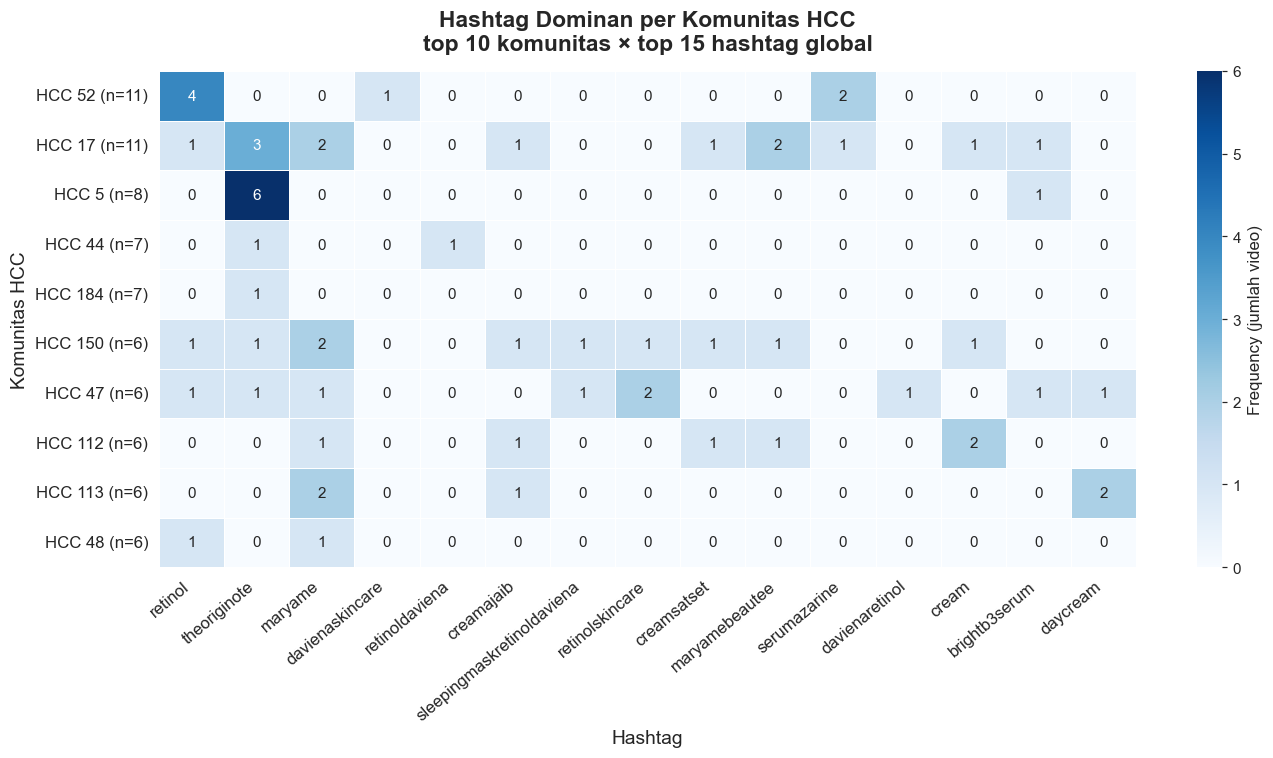

Disimpan: output/visualisasi/HCC_hashtag_by_community.png


In [43]:
# ── Grafik 3: Heatmap Komunitas × Hashtag (top komunitas × top hashtag global) ──
N_HEATMAP_HCC     = 10
N_HEATMAP_HASHTAG = 15

_heatmap_hcc_ids  = _panel_candidates.head(N_HEATMAP_HCC).index.tolist()
_heatmap_hashtags = hashtag_summary_overall.head(N_HEATMAP_HASHTAG)['hashtag'].tolist()

_pivot = (hcc_hashtag_profile[hcc_hashtag_profile['hcc_id'].isin(_heatmap_hcc_ids) &
                               hcc_hashtag_profile['hashtag'].isin(_heatmap_hashtags)]
          .pivot_table(index='hcc_id', columns='hashtag', values='frequency',
                        aggfunc='sum', fill_value=0))
_pivot = _pivot.reindex(index=_heatmap_hcc_ids, columns=_heatmap_hashtags, fill_value=0)
_pivot.index = [f'HCC {i} (n={_hcc_size_map.get(i, "?")})' for i in _pivot.index]

fig, ax = plt.subplots(figsize=(max(12, _pivot.shape[1] * 0.85),
                                 max(7, _pivot.shape[0] * 0.62)))
sns.heatmap(_pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.6,
            linecolor='white', cbar_kws={'label': 'Frequency (jumlah video)'},
            annot_kws={'fontsize': 10}, ax=ax)
ax.set_title(f'Hashtag Dominan per Komunitas HCC\n'
             f'top {N_HEATMAP_HCC} komunitas × top {N_HEATMAP_HASHTAG} hashtag global',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Hashtag', fontsize=12.5)
ax.set_ylabel('Komunitas HCC', fontsize=12.5)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=11)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=11)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Frequency (jumlah video)', fontsize=11)
plt.tight_layout()

plt.savefig(RM1_VISUALIZATION_DIR / "HCC_hashtag_by_community.png", bbox_inches='tight', dpi=220)
plt.show()
print('Disimpan: output/visualisasi/HCC_hashtag_by_community.png')


### 16.1.2 Visualisasi Hashtag Lengkap — Seluruh 42 Komunitas HCC

**Tujuan:** Melengkapi Section 16.1.1 agar **setiap** komunitas HCC (42 komunitas, 218 akun) memiliki
representasi visual hashtag masing-masing secara utuh — bukan hanya gambaran umum/sampel — sehingga
terlihat: (1) komunitas HCC mana terasosiasi dengan brand context/hashtag apa saja, (2) hashtag dominan pada
setiap komunitas, dan (3) perbandingan penggunaan hashtag antar komunitas.

**Input:** `hcc_hashtag_profile`, `hcc_hashtag_df`, `hashtag_summary_overall`, `_hcc_size_map`
(sudah dibangun di Section 16.1/16.1.1 — tidak ada perhitungan ulang dari `df`/`vid_hashtags`).

**Catatan metodologis (diulang agar tidak overclaim, lihat juga Section 16.0 & 16.1.1):** Hashtag
yang divisualisasikan di sini bersumber dari metadata **video** (`video_metadata_clean.csv`) pada
video yang dikomentari oleh akun-akun anggota HCC — merupakan **asosiasi konteks brand/video**, **bukan**
hashtag yang dituliskan akun tsb pada kolom komentarnya sendiri. Interpretasi yang benar: *"akun-akun HCC
ini sama-sama terpapar/beraktivitas pada video dengan hashtag metadata video X"* — **bukan** *"akun-akun
HCC ini menuliskan hashtag X di komentar"*.
Seluruh visualisasi & tabel pada Section 16.1.2 ini murni untuk karakterisasi/validasi HCC dan **tidak**
mengubah Co-conv, Co-reply, Co-temporal, `final_weight`, Louvain, FSA_V, jumlah HCC final (tetap 42
komunitas/218 node), maupun `focal_structures.csv`.

**Metrik yang ditampilkan per komunitas:**
- `frequency` (= `n_videos`): jumlah video (dalam video yang dikomentari HCC ini) yang memuat hashtag tsb.
- `n_users_exposed`: jumlah akun anggota HCC yang pernah mengomentari video berhashtag tsb.
- `hashtag_uses_per_account` = `frequency / n_users_exposed`: konsentrasi eksposur — nilai tinggi berarti
  sedikit akun terekspos ke banyak video berhashtag sama; nilai rendah berarti hashtag itu tersebar ke
  banyak akun berbeda melalui sedikit video.

**Output:**
- `output/visualisasi/hashtag_by_community/` ? grafik PNG per komunitas
  (`hcc_{id}_hashtags_frequency.png`, `hcc_{id}_hashtags_per_account.png`) ? hanya PNG agar
  jumlah file tetap ringkas.
- `output/visualisasi/HCC_hashtag_heatmap_all_communities_top20.png` ? heatmap seluruh 42
  komunitas ? top 20 hashtag global (PNG saja).
- Ekspor PDF/SVG duplikat tidak dipertahankan; versi lengkap seluruh komunitas disimpan pada
  tabel CSV lengkap di bawah.
- `output/tables/hcc_hashtag_all_communities_complete.csv` — **seluruh** hashtag pada **seluruh**
  komunitas (bukan hanya top-N), lengkap dengan rank frequency & rank per-account per komunitas.
- `output/tables/hcc_hashtag_community_summary.csv` — ringkasan per komunitas (jumlah hashtag unik,
  top-1, top-5, `dominant_hashtag_share`).
- `output/tables/hcc_hashtag_matrix_frequency.csv`, `output/tables/hcc_hashtag_matrix_users_exposed.csv`
  — matrix lengkap komunitas × hashtag (tanpa pembatasan top-N).

Grafik per komunitas dibatasi maksimum top 30 hashtag agar tetap terbaca; seluruh tabel CSV di atas
tetap menyimpan hashtag lengkap tanpa pemotongan.

In [44]:
# ── Tabel lengkap seluruh hashtag pada seluruh komunitas HCC (bukan hanya top-N) ──
_complete = hcc_hashtag_profile.copy()
_complete['community_size'] = _complete['hcc_id'].map(_hcc_size_map)
_complete['hashtag_uses_per_account'] = _complete.apply(
    lambda r: _safe_ratio(r['frequency'], r['n_users_exposed']), axis=1)

_complete['rank_frequency_within_hcc'] = (
    _complete.groupby('hcc_id')['frequency']
    .rank(method='first', ascending=False).astype(int)
)
_complete['rank_per_account_within_hcc'] = (
    _complete.groupby('hcc_id')['hashtag_uses_per_account']
    .rank(method='first', ascending=False).astype(int)
)

hcc_hashtag_all_communities_complete = _complete[[
    'hcc_id', 'community_size', 'hashtag', 'frequency', 'n_videos',
    'n_users_exposed', 'hashtag_uses_per_account',
    'rank_frequency_within_hcc', 'rank_per_account_within_hcc'
]].sort_values(['hcc_id', 'rank_frequency_within_hcc']).reset_index(drop=True)

hcc_hashtag_all_communities_complete.to_csv(RM1_TABLES_DIR / "hcc_hashtag_all_communities_complete.csv", index=False)

print(f"✓ Disimpan: output/tables/hcc_hashtag_all_communities_complete.csv "
      f"({len(hcc_hashtag_all_communities_complete):,} baris, "
      f"{hcc_hashtag_all_communities_complete['hcc_id'].nunique()} komunitas HCC, "
      f"{hcc_hashtag_all_communities_complete['hashtag'].nunique()} hashtag unik)")
display(hcc_hashtag_all_communities_complete.head(10))


✓ Disimpan: output/tables/hcc_hashtag_all_communities_complete.csv (622 baris, 42 komunitas HCC, 130 hashtag unik)


,hcc_id,community_size,hashtag,frequency,n_videos,n_users_exposed,hashtag_uses_per_account,rank_frequency_within_hcc,rank_per_account_within_hcc
0,1,3,retinolskincare,2,2,3,0.6670,1,1
1,1,3,glowup,2,2,3,0.6670,2,2
2,1,3,maryamebeautee,2,2,3,0.6670,3,3
3,1,3,retinolcomplex,1,1,3,0.3330,4,4
4,1,3,azarinecosmetic,1,1,3,0.3330,5,5
5,1,3,reviewretinol,1,1,3,0.3330,6,6
6,1,3,marvelxazarine,1,1,3,0.3330,7,7
7,1,3,retinolserum,1,1,3,0.3330,8,8
8,1,3,racuntiktokshop,1,1,3,0.3330,9,9
9,1,3,racunnabella,1,1,3,0.3330,10,10


In [45]:
# ── Tabel ringkasan hashtag per komunitas HCC ─────────────────────────────────
_summary_rows = []
for hcc_id, grp in hcc_hashtag_all_communities_complete.groupby('hcc_id'):
    g = grp.sort_values('frequency', ascending=False).reset_index(drop=True)
    total_freq = int(g['frequency'].sum())
    top1 = g.iloc[0]
    top5 = g.head(5)
    _summary_rows.append({
        'hcc_id'                  : hcc_id,
        'community_size'          : int(g['community_size'].iloc[0]),
        'n_unique_hashtags'       : len(g),
        'total_hashtag_frequency' : total_freq,
        'top_1_hashtag'           : top1['hashtag'],
        'top_1_frequency'         : int(top1['frequency']),
        'top_5_hashtags'          : '; '.join(top5['hashtag'].tolist()),
        'dominant_hashtag_share'  : round(top1['frequency'] / total_freq, 3) if total_freq else 0.0,
    })

hcc_hashtag_community_summary = (
    pd.DataFrame(_summary_rows).sort_values('hcc_id').reset_index(drop=True)
)
hcc_hashtag_community_summary.to_csv(RM1_TABLES_DIR / "hcc_hashtag_community_summary.csv", index=False)

print(f"✓ Disimpan: output/tables/hcc_hashtag_community_summary.csv "
      f"({len(hcc_hashtag_community_summary)} komunitas HCC)")
display(hcc_hashtag_community_summary)


✓ Disimpan: output/tables/hcc_hashtag_community_summary.csv (42 komunitas HCC)


,hcc_id,community_size,n_unique_hashtags,total_hashtag_frequency,top_1_hashtag,top_1_frequency,top_5_hashtags,dominant_hashtag_share
0,1,3,31,34,retinolskincare,2,retinolskincare; maryamebeautee; glowup; retin...,0.0590
1,2,6,6,8,maryame,3,maryame; dokterdetektif; tipsandtricks; mputri...,0.3750
2,3,5,12,12,skincareampuh,1,skincareampuh; mencerahkankulit; retinol; meng...,0.0830
3,5,8,16,21,theoriginote,6,theoriginote; brightserum; capcut; niacinamide...,0.2860
4,14,3,16,16,skincaretips,1,skincaretips; sleepingmaskretinoldaviena; reti...,0.0620
5,15,6,4,4,racunjuju,1,racunjuju; theoriginote; brightb3serum; hyaluc...,0.2500
6,16,5,9,9,retinoldaviena,1,retinoldaviena; davienaskincare; carapakeretin...,0.1110
7,17,11,24,29,theoriginote,3,theoriginote; maryame; dokterdetektif; maryame...,0.1030
8,18,6,6,6,retinolviral,1,retinolviral; skincaremaryame; skincareproduct...,0.1670
9,20,3,20,21,maryame,2,maryame; skincaretips; stepskincare; creamajai...,0.0950


In [46]:
# ── Matrix lengkap komunitas HCC x hashtag (CSV, tanpa pembatasan top-N) ─────
_matrix_freq = (
    hcc_hashtag_all_communities_complete
    .pivot_table(index='hcc_id', columns='hashtag', values='frequency',
                 aggfunc='sum', fill_value=0)
    .astype(int)
)
_matrix_users = (
    hcc_hashtag_all_communities_complete
    .pivot_table(index='hcc_id', columns='hashtag', values='n_users_exposed',
                 aggfunc='sum', fill_value=0)
    .astype(int)
)
_matrix_freq.to_csv(RM1_TABLES_DIR / "hcc_hashtag_matrix_frequency.csv")
_matrix_users.to_csv(RM1_TABLES_DIR / "hcc_hashtag_matrix_users_exposed.csv")

print(f"✓ Disimpan: output/tables/hcc_hashtag_matrix_frequency.csv "
      f"({_matrix_freq.shape[0]} HCC x {_matrix_freq.shape[1]} hashtag)")
print(f"✓ Disimpan: output/tables/hcc_hashtag_matrix_users_exposed.csv "
      f"({_matrix_users.shape[0]} HCC x {_matrix_users.shape[1]} hashtag)")


✓ Disimpan: output/tables/hcc_hashtag_matrix_frequency.csv (42 HCC x 130 hashtag)
✓ Disimpan: output/tables/hcc_hashtag_matrix_users_exposed.csv (42 HCC x 130 hashtag)


In [47]:
# ── Helper: satu figure horizontal-bar hashtag untuk 1 komunitas HCC ──────────
# Dipakai oleh ekspor PNG per komunitas agar sumber data dan styling tetap konsisten.
TOP_N_COMMUNITY_CHART = 30

def _make_hcc_hashtag_figure(hcc_id, metric='frequency', top_n=TOP_N_COMMUNITY_CHART):
    """metric: 'frequency' (chart A) atau 'hashtag_uses_per_account' (chart B)."""
    g_full = (hcc_hashtag_all_communities_complete[
                  hcc_hashtag_all_communities_complete['hcc_id'] == hcc_id]
              .sort_values(metric, ascending=False).reset_index(drop=True))
    n_total = len(g_full)
    size = int(_hcc_size_map.get(hcc_id, g_full['community_size'].iloc[0] if n_total else 0))
    g = g_full.head(top_n).iloc[::-1].reset_index(drop=True)

    fig_h = max(5.0, 0.34 * len(g) + 1.6)
    fig, ax = plt.subplots(figsize=(13, fig_h))

    if g.empty:
        ax.axis('off')
        ax.set_title(f'HCC {hcc_id} | n_accounts={size} | n_hashtags=0',
                     fontsize=15, fontweight='bold')
        ax.text(0.5, 0.5, 'Tidak ada hashtag pada komunitas ini', ha='center', va='center', fontsize=13)
        return fig, ax

    color = _BLUE if metric == 'frequency' else _AQUA
    bars = ax.barh(g['hashtag'], g[metric], color=color, edgecolor='white', height=0.68)

    xmax = g[metric].max()
    for bar, (_, r) in zip(bars, g.iterrows()):
        label = f"freq={int(r['frequency'])}, users={int(r['n_users_exposed'])}, videos={int(r['n_videos'])}"
        ax.text(bar.get_width() + xmax * 0.015, bar.get_y() + bar.get_height() / 2,
                label, va='center', ha='left', fontsize=11)

    ax.set_xlim(0, xmax * 1.6)
    xlabel = ('Frequency — jumlah video (dalam video yang dikomentari HCC ini) berhashtag tsb'
              if metric == 'frequency' else
              'Hashtag uses per account (frequency / n_users_exposed)')
    ax.set_xlabel(xlabel, fontsize=13)
    title_suffix = '' if n_total <= top_n else f' (menampilkan top {top_n} dari {n_total} hashtag)'
    ax.set_title(f'HCC {hcc_id} | n_accounts={size} | n_hashtags={n_total}{title_suffix}',
                 fontsize=15.5, fontweight='bold', pad=14)
    ax.tick_params(axis='y', labelsize=12.5)
    ax.tick_params(axis='x', labelsize=11.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color('#c3c2b7')
    ax.spines['bottom'].set_color('#c3c2b7')
    ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig, ax

_all_hcc_ids = sorted(hcc_hashtag_all_communities_complete['hcc_id'].unique())
_total_unique_hashtags = hcc_hashtag_all_communities_complete['hashtag'].nunique()
_total_nodes_hcc = int(hcc_hashtag_df['member_count'].sum())
print(f"Helper _make_hcc_hashtag_figure() siap. Komunitas HCC terdeteksi: {len(_all_hcc_ids)} "
      f"(total node: {_total_nodes_hcc}, total hashtag unik: {_total_unique_hashtags}).")


Helper _make_hcc_hashtag_figure() siap. Komunitas HCC terdeteksi: 42 (total node: 218, total hashtag unik: 130).


In [48]:
# Export PDF multipage dinonaktifkan: visualisasi Section 16.1.2 PNG-only
print('Ekspor PDF multipage dinonaktifkan; gunakan PNG per komunitas dan CSV lengkap Section 16.1.2.')


Ekspor PDF multipage dinonaktifkan; gunakan PNG per komunitas dan CSV lengkap Section 16.1.2.


In [49]:
# ── Grafik PNG per komunitas HCC (frequency & per-account) ───────────────────
# Catatan: hanya format PNG yang disimpan agar folder visualisasi tetap ringkas;
# versi lengkap seluruh komunitas tersedia pada CSV lengkap (Section 16.1.2).
import gc

HASHTAG_DIR = RM1_VISUALIZATION_DIR / 'hashtag_by_community'
HASHTAG_DIR.mkdir(parents=True, exist_ok=True)

_saved_files = []
for hcc_id in tqdm(_all_hcc_ids, desc='Grafik PNG per komunitas'):
    fig, _ax = _make_hcc_hashtag_figure(hcc_id, metric='frequency', top_n=TOP_N_COMMUNITY_CHART)
    path = HASHTAG_DIR / f'hcc_{hcc_id}_hashtags_frequency.png'
    fig.savefig(path, bbox_inches='tight', dpi=200)
    _saved_files.append(path)
    plt.close(fig)
    gc.collect()

    fig2, _ax2 = _make_hcc_hashtag_figure(hcc_id, metric='hashtag_uses_per_account',
                                           top_n=TOP_N_COMMUNITY_CHART)
    path2 = HASHTAG_DIR / f'hcc_{hcc_id}_hashtags_per_account.png'
    fig2.savefig(path2, bbox_inches='tight', dpi=200)
    _saved_files.append(path2)
    plt.close(fig2)
    gc.collect()

print(f'✓ Disimpan {len(_saved_files):,} file gambar (PNG) pada {HASHTAG_DIR}/ '
      f'({len(_all_hcc_ids)} komunitas x 2 file [hashtags_frequency, hashtags_per_account])')


Grafik PNG per komunitas:   0%|          | 0/42 [00:00<?, ?it/s]

✓ Disimpan 84 file gambar (PNG) pada D:\UNHAS\PKM-RSH\Pendanaan\Analisis 4\output\visualisasi\hashtag_by_community/ (42 komunitas x 2 file [hashtags_frequency, hashtags_per_account])


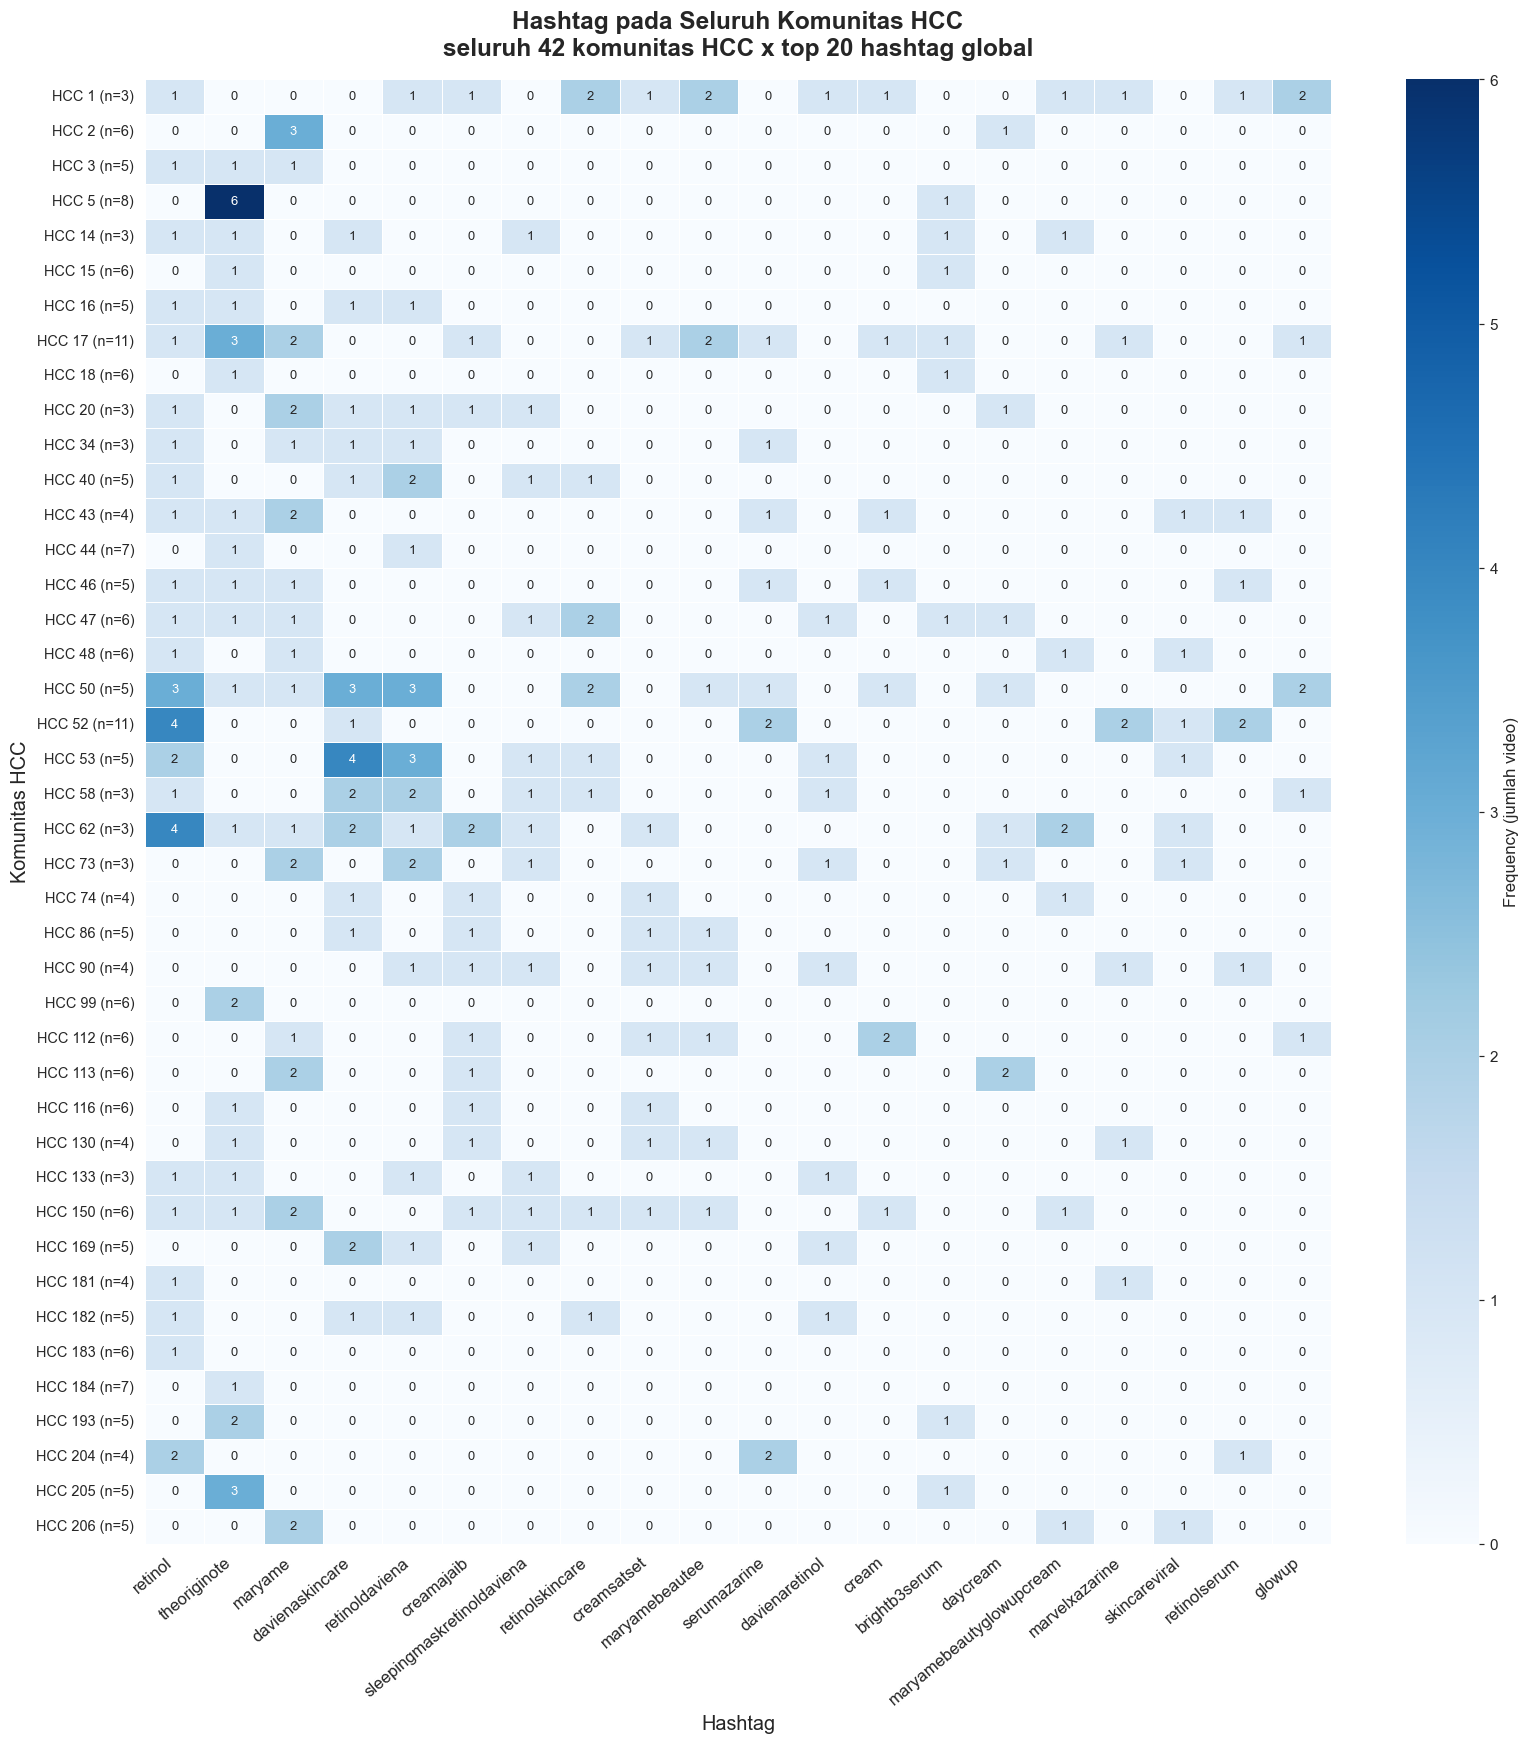

✓ Disimpan: output/visualisasi/HCC_hashtag_heatmap_all_communities_top20.png


In [50]:
# ── Heatmap ringkas: seluruh 42 komunitas HCC x top 20 hashtag global ────────
# Catatan: hanya format PNG yang disimpan (bukan PDF/SVG) agar jumlah file ringkas.
N_HEATMAP_HASHTAG_FULL = 20
_heatmap_hashtags_full = hashtag_summary_overall.head(N_HEATMAP_HASHTAG_FULL)['hashtag'].tolist()

_pivot_full = (
    hcc_hashtag_all_communities_complete[
        hcc_hashtag_all_communities_complete['hashtag'].isin(_heatmap_hashtags_full)
    ]
    .pivot_table(index='hcc_id', columns='hashtag', values='frequency', aggfunc='sum', fill_value=0)
)
_pivot_full = _pivot_full.reindex(index=_all_hcc_ids, columns=_heatmap_hashtags_full, fill_value=0)
_pivot_full.index = [f'HCC {i} (n={_hcc_size_map.get(i, "?")})' for i in _pivot_full.index]

fig, ax = plt.subplots(figsize=(max(14, _pivot_full.shape[1] * 0.75),
                                 max(11, _pivot_full.shape[0] * 0.38)))
sns.heatmap(_pivot_full, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5,
            linecolor='white', cbar_kws={'label': 'Frequency (jumlah video)'},
            annot_kws={'fontsize': 8.5}, ax=ax)
ax.set_title(f'Hashtag pada Seluruh Komunitas HCC\n'
             f'seluruh {len(_all_hcc_ids)} komunitas HCC x top {N_HEATMAP_HASHTAG_FULL} hashtag global',
             fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Hashtag', fontsize=13)
ax.set_ylabel('Komunitas HCC', fontsize=13)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=11)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9.5)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Frequency (jumlah video)', fontsize=11)
plt.tight_layout()

plt.savefig(RM1_VISUALIZATION_DIR / "HCC_hashtag_heatmap_all_communities_top20.png",
            bbox_inches='tight', dpi=200)
plt.show()
print('✓ Disimpan: output/visualisasi/HCC_hashtag_heatmap_all_communities_top20.png')


In [51]:
# Validasi Section 16.1.2: visualisasi hashtag lengkap seluruh komunitas HCC
import glob
_n_total_files = len(glob.glob(f'{HASHTAG_DIR}/*.*'))
_n_png_files   = len(glob.glob(f'{HASHTAG_DIR}/*.png'))
_non_png_files = sorted([p for p in glob.glob(f'{HASHTAG_DIR}/*.*') if not p.lower().endswith('.png')])

print('=== VALIDASI: VISUALISASI HASHTAG LENGKAP SELURUH KOMUNITAS HCC ===')
print(f'Jumlah komunitas HCC yang divisualisasikan   : {len(_all_hcc_ids)}')
print(f'Jumlah file gambar per-komunitas dibuat       : {_n_total_files:,} ({_n_png_files:,} PNG; {len(_non_png_files):,} non-PNG)')
print(f'Jumlah hashtag unik pada seluruh HCC           : {_total_unique_hashtags:,}')
if _non_png_files:
    print('PERINGATAN: ditemukan file non-PNG pada folder per-komunitas:')
    for _path in _non_png_files[:20]:
        print(f'  - {_path}')
else:
    print('Validasi format: folder per-komunitas PNG-only.')

print('\n=== 10 KOMUNITAS DENGAN HASHTAG TERBANYAK ===')
_top10_by_nhashtag = (hcc_hashtag_community_summary
                       .sort_values('n_unique_hashtags', ascending=False)
                       .head(10)[['hcc_id', 'community_size', 'n_unique_hashtags',
                                   'total_hashtag_frequency', 'top_1_hashtag', 'dominant_hashtag_share']])
display(_top10_by_nhashtag)

print('\n=== TOP 20 HASHTAG OVERALL ===')
display(hashtag_summary_overall.head(20))

print(f'\nLokasi folder gambar PNG : {HASHTAG_DIR}/')
print('Ekspor PDF/SVG duplikat  : dinonaktifkan')

print('\n=== CONTOH TOP HASHTAG PADA 5 KOMUNITAS TERBESAR ===')
_top5_by_size = (hcc_hashtag_df[['community_id', 'member_count']]
                  .sort_values('member_count', ascending=False).head(5))
for _, r in _top5_by_size.iterrows():
    _cid = r['community_id']
    _row = hcc_hashtag_community_summary[hcc_hashtag_community_summary['hcc_id'] == _cid]
    if len(_row):
        _row = _row.iloc[0]
        print(f"HCC {_cid} (n={int(r['member_count'])}): top_1={_row['top_1_hashtag']} "
              f"(freq={_row['top_1_frequency']}, share={_row['dominant_hashtag_share']:.2f}) | "
              f"top_5={_row['top_5_hashtags']}")
    else:
        print(f"HCC {_cid} (n={int(r['member_count'])}): (tidak ada hashtag)")


=== VALIDASI: VISUALISASI HASHTAG LENGKAP SELURUH KOMUNITAS HCC ===
Jumlah komunitas HCC yang divisualisasikan   : 42
Jumlah file gambar per-komunitas dibuat       : 116 (116 PNG; 0 non-PNG)
Jumlah hashtag unik pada seluruh HCC           : 130
Validasi format: folder per-komunitas PNG-only.

=== 10 KOMUNITAS DENGAN HASHTAG TERBANYAK ===


,hcc_id,community_size,n_unique_hashtags,total_hashtag_frequency,top_1_hashtag,dominant_hashtag_share
32,150,6,38,39,maryame,0.0510
21,62,3,35,41,retinol,0.0980
17,50,5,33,41,retinol,0.0730
0,1,3,31,34,retinolskincare,0.0590
18,52,11,30,37,retinol,0.1080
20,58,3,25,27,davienaskincare,0.0740
7,17,11,24,29,theoriginote,0.1030
15,47,6,24,25,retinolskincare,0.0800
12,43,4,21,22,maryame,0.0910
14,46,5,21,21,acnefighter,0.0480



=== TOP 20 HASHTAG OVERALL ===


,hashtag,frequency,n_videos,n_users_exposed,hashtag_uses_per_account
0,retinol,33,33,103,0.3200
1,theoriginote,32,32,104,0.3080
2,maryame,25,25,78,0.3210
3,davienaskincare,22,22,54,0.4070
4,retinoldaviena,22,22,60,0.3670
5,creamajaib,13,13,56,0.2320
6,sleepingmaskretinoldaviena,12,12,47,0.2550
7,retinolskincare,11,11,38,0.2890
8,creamsatset,10,10,47,0.2130
9,maryamebeautee,10,10,44,0.2270



Lokasi folder gambar PNG : D:\UNHAS\PKM-RSH\Pendanaan\Analisis 4\output\visualisasi\hashtag_by_community/
Ekspor PDF/SVG duplikat  : dinonaktifkan

=== CONTOH TOP HASHTAG PADA 5 KOMUNITAS TERBESAR ===
HCC 52 (n=11): top_1=retinol (freq=4, share=0.11) | top_5=retinol; marvelxazarine; retinolserum; serumazarine; azarinecosmetic
HCC 17 (n=11): top_1=theoriginote (freq=3, share=0.10) | top_5=theoriginote; maryame; dokterdetektif; maryamebeautee; glowupcream
HCC 5 (n=8): top_1=theoriginote (freq=6, share=0.29) | top_5=theoriginote; brightserum; capcut; niacinamideserum; brighteningserum
HCC 44 (n=7): top_1=fyf (freq=1, share=0.10) | top_5=fyf; ceritaiketia; retinoldaviena; pejuangglowing; pejuangglowup
HCC 184 (n=7): top_1=racunjuju (freq=1, share=0.33) | top_5=racunjuju; theoriginote; brightserum


### 16.1.3 Auto Brand Labeling (berbasis hashtag metadata video + fallback konteks produk/video)

**Tujuan:** Memberi label brand pada setiap komunitas HCC secara **otomatis**, pertama berdasarkan skor
hashtag brand pada metadata video yang dikomentari anggotanya (Section 16.0/16.1). Jika hashtag brand
tidak mengidentifikasi brand, notebook memakai fallback konteks produk/video dari `product_category`
komentar anggota HCC dan memasukkan HCC tersebut ke brand terkuat. Aturan ini tetap **bukan** mapping
manual dari ketua tim dan **bukan** hardcode `community_id` -> brand tertentu; label ditentukan dari data
komentar/video.

**Input:** `hcc_hashtag_profile` (Section 16.1, kolom `hcc_id`, `hashtag`, `frequency`, `n_videos`,
`n_users_exposed`), `df` (`product_category`, `video_id`, `username`), `hcc_list` (keanggotaan HCC, Section 12).
**Output:** `output/tables/hcc_brand_profile_auto.csv`, `member_to_hcc` / `hcc_to_members` (dipakai ulang
oleh Section 16.3-16.5 dan Section 17 Gephi Export).

**Kamus brand (`BRAND_HASHTAG_LEXICON`)** -- boleh diperluas jika ditemukan variasi lain di data, dicek
via **exact match** terhadap kolom `hashtag` (bukan substring), supaya label tetap murni data-driven dan
tidak menghasilkan false-positive:

| Brand | Varian hashtag |
|---|---|
| Azarine | azarine, azarinecosmetic, azarinecosmetics, azarineskincare, marvelxazarine |
| Daviena | daviena, davienaskincare, davienaretinol, retinoldaviena, ownerdavienaskincare |
| Maryame | maryame, maryamebeauty, maryamebeautee, maryamebeautyglowupcream, maryameglowup, maryameskincare |
| The Originote | theoriginote, originote, theoriginoteskincare, originoteskincare, serumtheoriginote, reviewserumtheoriginote |

**Cara menghitung label per HCC:**
1. Jumlahkan `brand_frequency_score` (? `frequency`), `brand_users_score` (? `n_users_exposed`), dan
   `brand_videos_score` (? `n_videos`) untuk hashtag yang cocok tiap brand. `brand_frequency_score`
   dipakai sebagai skor utama.
2. Tidak ada brand berskor hashtag >0 -> gunakan fallback konteks produk/video dari `product_category`
   komentar anggota HCC. Brand dengan jumlah komentar terbanyak menjadi `brand_label_auto`; jika jumlah
   komentar seri, `n_videos` lalu `n_users` menjadi pemecah seri. Bila konteks produk/video juga kosong,
   baru `brand_label_auto = "Not identified"`, `brand_confidence = "None"`.
3. Tepat satu brand berskor >0 -> label = brand tersebut.
4. Lebih dari satu brand berskor >0 -> `primary_brand` = skor tertinggi, `brand_combo` = gabungan brand
   aktif (mis. `"Maryame + The Originote"`), dan:
   - `top_brand_share >= 0.60` -> `brand_label_auto` = nama brand utama (dominan meski ada brand lain).
   - tidak dominan & 2 brand aktif -> `"Mixed_2_Brands"`.
   - tidak dominan & >=3 brand aktif -> `"Mixed_3plus_Brands"`.
5. `brand_confidence`: High (`top_brand_share>=0.75`), Medium (`0.50<=top_brand_share<0.75`), Low
   (`top_brand_share<0.50`), None (Not identified). `brand_label_source` mencatat apakah label berasal
   dari `hashtag_lexicon`, `product_category_fallback`, atau tetap `unidentified`.

**Catatan Gephi (penting):** Kolom `brand_label_auto` (dan `primary_brand`) diekspor ke
`gephi_lcn_nodes.csv`/`gephi_hcc_nodes.csv` (Section 17) untuk **pewarnaan node**, tetapi warna
**tidak** diekspor sebagai kolom CSV (`brand_color_hex` tidak ada di file Gephi) -- atur warna langsung
di Gephi lewat **Appearance -> Nodes -> Partition -> `brand_label_auto`**. **Jangan** menjalankan
modularity ulang di Gephi untuk mendapatkan pengelompokan brand; struktur komunitas (Louvain/FSA_V)
sudah final dan tidak boleh dihitung ulang di luar notebook ini.

**Peta warna (`BRAND_COLOR_MAP`)** -- dipakai untuk visualisasi matplotlib di notebook (Section 16.5),
**bukan** diekspor ke Gephi; rekomendasi warna yang sama bisa diterapkan manual di Gephi lewat panel
Partition di atas: Azarine `#2ca25f` (hijau), Daviena `#e78ac3` (pink), Maryame `#ffd92f` (kuning),
The Originote `#1f78b4` (biru), Mixed_2_Brands `#8c8c8c` (abu-abu sedang), Mixed_3plus_Brands `#525252`
(abu-abu gelap), Not identified `#bdbdbd` (abu-abu muda), Non-HCC (khusus node LCN yang bukan anggota
HCC manapun) `#f0f0f0` (abu-abu sangat muda).


In [ ]:
# ?? 16.1.3 Auto Brand Labeling: lexicon, skor, dan label brand per HCC ???????
# Label brand dibuat OTOMATIS dari skor hashtag metadata video. Jika hashtag
# tidak mengidentifikasi brand, fallback memakai konteks produk/video dari
# komentar anggota HCC. Tidak ada hardcode community_id -> brand.

BRAND_HASHTAG_LEXICON = {
    "Azarine": [
        "azarine", "azarinecosmetic", "azarinecosmetics", "azarineskincare", "marvelxazarine",
    ],
    "Daviena": [
        "daviena", "davienaskincare", "davienaretinol", "retinoldaviena", "ownerdavienaskincare",
    ],
    "Maryame": [
        "maryame", "maryamebeauty", "maryamebeautee", "maryamebeautyglowupcream",
        "maryameglowup", "maryameskincare",
    ],
    "The Originote": [
        "theoriginote", "originote", "theoriginoteskincare", "originoteskincare",
        "serumtheoriginote", "reviewserumtheoriginote",
    ],
}
BRAND_KEYS = list(BRAND_HASHTAG_LEXICON.keys())
BRAND_SLUG = {"Azarine": "azarine", "Daviena": "daviena", "Maryame": "maryame", "The Originote": "the_originote"}
BRAND_COLOR_MAP = {
    "Azarine": "#2ca25f", "Daviena": "#e78ac3", "Maryame": "#ffd92f", "The Originote": "#1f78b4",
    "Not identified": "#bdbdbd", "Mixed_2_Brands": "#8c8c8c", "Mixed_3plus_Brands": "#525252",
    "Non-HCC": "#f0f0f0",
}
DOMINANT_SHARE_THRESHOLD = 0.60
CONF_HIGH, CONF_MEDIUM = 0.75, 0.50

brand_lookup = {}
for _brand, _variants in BRAND_HASHTAG_LEXICON.items():
    for _v in _variants:
        brand_lookup[_v] = _brand


def _brand_from_product_category(value):
    text = str(value).strip().lower()
    if "azarine" in text:
        return "Azarine"
    if "daviena" in text or "davina" in text:
        return "Daviena"
    if "maryame" in text:
        return "Maryame"
    if "originote" in text:
        return "The Originote"
    return ""


def _confidence_from_share(share, has_label=True):
    if not has_label:
        return "None"
    if share >= CONF_HIGH:
        return "High"
    if share >= CONF_MEDIUM:
        return "Medium"
    return "Low"


# ?? Keanggotaan HCC (dipakai ulang oleh Section 16.3-16.5 & Section 17) ??????
hcc_to_members = {row['community_id']: sorted(row['candidate_members']) for row in hcc_list}
member_to_hcc  = {m: hcc_id for hcc_id, members in hcc_to_members.items() for m in members}
all_hcc_ids    = sorted(hcc_to_members.keys())

# ?? Sanity check: varian lexicon yang tidak pernah muncul di hcc_hashtag_profile ??
_observed_hashtags = set(hcc_hashtag_profile['hashtag'].unique())
_unused_lexicon_variants = sorted(v for v in brand_lookup if v not in _observed_hashtags)
print(f'Varian lexicon brand yang TIDAK pernah muncul di hcc_hashtag_profile ({len(_unused_lexicon_variants)}): '
      f'{_unused_lexicon_variants}')
print('(Wajar -- lexicon sengaja mencakup variasi ejaan yang mungkin tidak semuanya ada di dataset ini; '
      'daftar di atas murni informasional, bukan error.)\n')


def _build_brand_profile_row(hcc_id):
    members = hcc_to_members[hcc_id]
    g = hcc_hashtag_profile[hcc_hashtag_profile['hcc_id'] == hcc_id]
    community_size = len(members)
    n_unique_hashtags = g['hashtag'].nunique()

    freq_scores  = {b: 0 for b in BRAND_KEYS}
    users_scores = {b: 0 for b in BRAND_KEYS}
    videos_scores = {b: 0 for b in BRAND_KEYS}
    brand_hashtags = defaultdict(list)

    for _, r in g.iterrows():
        b = brand_lookup.get(r['hashtag'])
        if b is None:
            continue
        freq_scores[b]   += r['frequency']
        users_scores[b]  += r['n_users_exposed']
        videos_scores[b] += r['n_videos']
        brand_hashtags[b].append((r['hashtag'], r['frequency']))

    context_comments = df[df['username'].isin(members)].copy()
    context_comments['product_context_brand'] = context_comments['product_category'].map(_brand_from_product_category)
    context_comments = context_comments[context_comments['product_context_brand'].isin(BRAND_KEYS)]
    context_comment_scores = {b: 0 for b in BRAND_KEYS}
    context_users_scores = {b: 0 for b in BRAND_KEYS}
    context_videos_scores = {b: 0 for b in BRAND_KEYS}
    for b in BRAND_KEYS:
        bg = context_comments[context_comments['product_context_brand'] == b]
        context_comment_scores[b] = int(len(bg))
        context_users_scores[b] = int(bg['username'].nunique())
        context_videos_scores[b] = int(bg['video_id'].nunique())

    active_brands = [b for b in BRAND_KEYS if freq_scores[b] > 0]
    ranked = sorted(BRAND_KEYS, key=lambda b: freq_scores[b], reverse=True)
    top_brand, second_brand_cand = ranked[0], ranked[1]
    top_score, second_score = freq_scores[top_brand], freq_scores[second_brand_cand]
    total_active_score = sum(freq_scores[b] for b in active_brands)
    brand_label_source = 'hashtag_lexicon' if active_brands else 'unidentified'

    if len(active_brands) == 0:
        context_active_brands = [b for b in BRAND_KEYS if context_comment_scores[b] > 0]
        if context_active_brands:
            context_ranked = sorted(
                BRAND_KEYS,
                key=lambda b: (context_comment_scores[b], context_videos_scores[b], context_users_scores[b]),
                reverse=True,
            )
            top_brand = context_ranked[0]
            second_brand_cand = context_ranked[1]
            top_score = context_comment_scores[top_brand]
            second_score = context_comment_scores[second_brand_cand]
            total_context_score = sum(context_comment_scores[b] for b in context_active_brands)
            top_brand_share = top_score / total_context_score if total_context_score else 0.0
            primary_brand = top_brand
            brand_label_auto = top_brand
            brand_combo = ' + '.join(
                sorted(context_active_brands, key=lambda b: context_comment_scores[b], reverse=True)
            )
            brand_confidence = _confidence_from_share(top_brand_share)
            second_brand = second_brand_cand if second_score > 0 else ''
            second_brand_score = second_score if second_score > 0 else 0
            brand_label_source = 'product_category_fallback'
        else:
            primary_brand      = 'Not identified'
            brand_label_auto   = 'Not identified'
            brand_combo         = ''
            brand_confidence    = 'None'
            top_brand_share     = 0.0
            second_brand        = ''
            second_brand_score  = 0
    else:
        primary_brand   = top_brand
        top_brand_share = top_score / total_active_score if total_active_score else 0.0
        second_brand        = second_brand_cand if second_score > 0 else ''
        second_brand_score  = second_score if second_score > 0 else 0
        if len(active_brands) == 1:
            brand_label_auto = top_brand
            brand_combo       = top_brand
        else:
            brand_combo = ' + '.join(sorted(active_brands, key=lambda b: freq_scores[b], reverse=True))
            if top_brand_share >= DOMINANT_SHARE_THRESHOLD:
                brand_label_auto = top_brand
            elif len(active_brands) == 2:
                brand_label_auto = 'Mixed_2_Brands'
            else:
                brand_label_auto = 'Mixed_3plus_Brands'
        brand_confidence = _confidence_from_share(top_brand_share)

    top_brand_hashtags = ''
    if active_brands:
        _th = sorted(brand_hashtags.get(top_brand, []), key=lambda x: -x[1])
        top_brand_hashtags = '; '.join(f'{h}({f})' for h, f in _th)
    top5_overall = g.sort_values('frequency', ascending=False).head(5)
    top_5_hashtags_overall = '; '.join(f'{h}({f})' for h, f in zip(top5_overall['hashtag'], top5_overall['frequency']))

    context_ranked_nonzero = sorted(
        [b for b in BRAND_KEYS if context_comment_scores[b] > 0],
        key=lambda b: context_comment_scores[b],
        reverse=True,
    )
    context_total = sum(context_comment_scores[b] for b in context_ranked_nonzero)
    context_top_brand = context_ranked_nonzero[0] if context_ranked_nonzero else ''
    context_second_brand = context_ranked_nonzero[1] if len(context_ranked_nonzero) > 1 else ''

    row = {
        'hcc_id': hcc_id, 'community_size': community_size, 'n_unique_hashtags': n_unique_hashtags,
        'primary_brand': primary_brand, 'brand_label_auto': brand_label_auto, 'brand_combo': brand_combo,
        'brand_confidence': brand_confidence, 'brand_label_source': brand_label_source,
        'top_brand_score': top_score if (active_brands or brand_label_source == 'product_category_fallback') else 0,
        'second_brand': second_brand, 'second_brand_score': second_brand_score,
        'top_brand_share': round(top_brand_share, 4),
        'product_context_top_brand': context_top_brand,
        'product_context_top_score': context_comment_scores.get(context_top_brand, 0) if context_top_brand else 0,
        'product_context_second_brand': context_second_brand,
        'product_context_second_score': context_comment_scores.get(context_second_brand, 0) if context_second_brand else 0,
        'product_context_top_share': round((context_comment_scores[context_top_brand] / context_total), 4) if context_top_brand and context_total else 0.0,
        'product_context_combo': ' + '.join(context_ranked_nonzero),
    }
    for b in BRAND_KEYS:
        slug = BRAND_SLUG[b]
        row[f'{slug}_score']  = freq_scores[b]
        row[f'{slug}_users']  = users_scores[b]
        row[f'{slug}_videos'] = videos_scores[b]
        row[f'{slug}_context_comments'] = context_comment_scores[b]
        row[f'{slug}_context_users'] = context_users_scores[b]
        row[f'{slug}_context_videos'] = context_videos_scores[b]
    row['top_brand_hashtags']     = top_brand_hashtags
    row['top_5_hashtags_overall'] = top_5_hashtags_overall
    row['brand_color_hex']        = BRAND_COLOR_MAP[brand_label_auto]
    return row


hcc_brand_profile_auto = pd.DataFrame([_build_brand_profile_row(h) for h in all_hcc_ids])
hcc_brand_profile_auto = hcc_brand_profile_auto[[
    'hcc_id', 'community_size', 'n_unique_hashtags', 'primary_brand', 'brand_label_auto', 'brand_combo',
    'brand_confidence', 'brand_label_source', 'top_brand_score', 'second_brand', 'second_brand_score',
    'top_brand_share', 'product_context_top_brand', 'product_context_top_score',
    'product_context_second_brand', 'product_context_second_score', 'product_context_top_share',
    'product_context_combo',
    'azarine_score', 'daviena_score', 'maryame_score', 'the_originote_score',
    'azarine_users', 'daviena_users', 'maryame_users', 'the_originote_users',
    'azarine_videos', 'daviena_videos', 'maryame_videos', 'the_originote_videos',
    'azarine_context_comments', 'daviena_context_comments', 'maryame_context_comments', 'the_originote_context_comments',
    'azarine_context_users', 'daviena_context_users', 'maryame_context_users', 'the_originote_context_users',
    'azarine_context_videos', 'daviena_context_videos', 'maryame_context_videos', 'the_originote_context_videos',
    'top_brand_hashtags', 'top_5_hashtags_overall',
]]
hcc_brand_profile_auto.to_csv(RM1_TABLES_DIR / "hcc_brand_profile_auto.csv", index=False)
brand_profile_by_hcc = hcc_brand_profile_auto.set_index('hcc_id')

print(f"? Disimpan: output/tables/hcc_brand_profile_auto.csv ({len(hcc_brand_profile_auto)} komunitas HCC)")
print('\n=== BRAND PROFILE PER HCC (auto-label, hashtag + fallback konteks produk/video) ===')
display(hcc_brand_profile_auto[['hcc_id', 'community_size', 'primary_brand', 'brand_label_auto',
                                  'brand_combo', 'brand_confidence', 'brand_label_source',
                                  'top_brand_share', 'product_context_top_brand',
                                  'product_context_top_share']])


In [ ]:
# ── Validasi: ringkasan distribusi brand otomatis (Tugas 5) ──────────────────
# Seluruh angka di bawah dihitung dari data -- tidak ada target/jumlah brand
# yang di-hardcode.
print('=== RINGKASAN DISTRIBUSI BRAND OTOMATIS ===')
print(f'Jumlah HCC total          : {len(hcc_brand_profile_auto)}')
print(f'Jumlah node HCC total     : {hcc_brand_profile_auto["community_size"].sum()}')

print('\nJumlah HCC per brand_label_auto:')
display(hcc_brand_profile_auto['brand_label_auto'].value_counts().rename('n_hcc').to_frame())

print('\nJumlah HCC per primary_brand:')
display(hcc_brand_profile_auto['primary_brand'].value_counts().rename('n_hcc').to_frame())

_mixed2 = hcc_brand_profile_auto.loc[hcc_brand_profile_auto['brand_label_auto'] == 'Mixed_2_Brands', 'hcc_id'].tolist()
_mixed3 = hcc_brand_profile_auto.loc[hcc_brand_profile_auto['brand_label_auto'] == 'Mixed_3plus_Brands', 'hcc_id'].tolist()
_notid  = hcc_brand_profile_auto.loc[hcc_brand_profile_auto['brand_label_auto'] == 'Not identified', 'hcc_id'].tolist()
print(f'\nHCC Mixed_2_Brands ({len(_mixed2)})       : {_mixed2}')
print(f'HCC Mixed_3plus_Brands ({len(_mixed3)})   : {_mixed3}')
print(f'HCC Not identified ({len(_notid)})        : {_notid}')

print('\n=== TOP HASHTAG PENYUMBANG LABEL PER HCC ===')
_top_contrib = hcc_brand_profile_auto[['hcc_id', 'brand_label_auto', 'primary_brand', 'top_brand_hashtags']].copy()
_top_contrib['top_1_contributing_hashtag'] = _top_contrib['top_brand_hashtags'].apply(
    lambda s: s.split(';')[0].strip() if isinstance(s, str) and s else '(tidak ada)')
display(_top_contrib[['hcc_id', 'brand_label_auto', 'primary_brand', 'top_1_contributing_hashtag']])

print('\n✓ Validasi Section 16.1.3 selesai -- seluruh label brand murni dihitung dari data '
      '(hashtag metadata video), tidak ada mapping manual per community_id.')


### 16.2 Co-mention Analysis — **[DEPRECATED, tidak lagi analisis aktif]**

**Status:** Co-Mention **dipensiunkan dari analisis aktif** per keputusan metodologis terbaru. Pada
dataset TikTok ini, akun/kreator yang disebut (*mention*) pada metadata video terbukti tidak informatif
dan tidak menjadi sumber konteks utama — mempertahankannya sebagai evidence aktif berisiko menimbulkan
overclaim. Sel di bawah **tidak lagi** membangun ulang profil mention, **tidak lagi** menyimpan
`output/tables/hcc_mention_profile.csv`, dan **tidak lagi** mencetak top mention HCC. Jika file
`hcc_mention_profile.csv` versi lama masih ada di `output/tables/`, file itu dibiarkan apa adanya
sebagai artefak historis (deprecated), bukan dihapus.

Kolom `co_mention` pada `output/gephi/gephi_lcn_edges.csv` dan `gephi_hcc_edges.csv` tetap dipertahankan
(dihitung dari `vid_mentions`, Section 16.0) semata demi kompatibilitas format file lama — **bukan**
karena masih dipakai sebagai evidence aktif. Lihat Section 19.11 untuk model interpretasi final yang
tidak lagi menyertakan mention sebagai dasar interpretasi.

**Tujuan historis (sebelum deprecation):** Mengidentifikasi apakah komunitas HCC aktif pada video yang
menyebut akun atau kreator yang sama.
**Input:** *(tidak lagi dihitung ulang di sini)*
**Output:** *(tidak lagi diekspor dari section ini — lihat catatan status di atas)*

In [ ]:
# ── Section 16.2 Co-mention Analysis -- DEPRECATED, dinonaktifkan ────────────
# Co-Mention dipensiunkan dari analisis aktif (lihat catatan Section 16.2 di atas):
# tidak informatif pada dataset TikTok ini dan berisiko overclaim jika tetap
# diperlakukan sebagai evidence aktif. Sel ini SENGAJA tidak lagi menghitung ulang
# profil mention, tidak menulis ulang output/tables/hcc_mention_profile.csv, dan
# tidak mencetak top mention HCC.
_mention_profile_path = RM1_TABLES_DIR / 'hcc_mention_profile.csv'
if os.path.exists(_mention_profile_path):
    print(f'[DEPRECATED] Co-mention analysis dinonaktifkan -- {_mention_profile_path} '
          f'TIDAK diregenerasi pada run ini (file lama dibiarkan apa adanya sebagai artefak historis).')
else:
    print('[DEPRECATED] Co-mention analysis dinonaktifkan -- tidak ada file lama untuk dipertahankan.')
print('Lihat Section 19.11 untuk model interpretasi final (Co-Mention tidak menjadi dasar interpretasi).')


In [ ]:
# ── Validasi: Top 20 hashtag pada HCC (agregat lintas seluruh komunitas HCC) ──
# Blok top-mention dihapus (Co-mention deprecated -- lihat Section 16.2).
print('=== TOP 20 HASHTAG PADA HCC (agregat frequency lintas seluruh komunitas HCC) ===')
print('(asosiasi konteks brand/video -- lihat catatan metodologis Section 16.0 & 16.1)')
if len(hcc_hashtag_profile):
    top20_hashtag = (hcc_hashtag_profile.groupby('hashtag')['frequency']
                      .sum().sort_values(ascending=False).head(20))
    display(top20_hashtag.to_frame('total_frequency'))
else:
    print('Tidak ada hashtag pada HCC manapun.')

print('\nCatatan: jumlah edge Gephi dengan co_hashtag > 0 dicetak pada Section 17 '
      '(precompute atribut edge Gephi), karena baru tersedia setelah LCN edges dihitung. '
      'Kolom co_mention pada Gephi export dipertahankan untuk kompatibilitas tapi deprecated '
      '(tidak lagi dicetak/divalidasi di sini).')


### 16.3 Co-similarity Analysis — Kesamaan Narasi Komentar (Weber & Neumann 2021)

**Tujuan:** Mengukur **kesamaan narasi komentar** antar akun dalam komunitas HCC yang sama — bukan
pembentuk LCN, murni analisis pasca-HCC untuk interpretasi. Alur:

`HCC final → brand_label_auto (Section 16.1.3) → Co-Similarity antar akun dalam HCC → ringkasan narrative similarity per HCC & per brand`

**Metodologi (mengikuti Weber & Neumann 2021):** Contoh *copypasta* menunjukkan bahwa teks identik atau
hampir identik dapat menjadi indikasi narasi yang disebarkan bersama. *Consistency of content*
dianalisis dengan memperlakukan **seluruh komentar satu akun sebagai satu dokumen**, lalu membandingkan
antar akun memakai **cosine similarity**. Weber & Neumann memakai representasi **5-character n-grams**
karena cocok untuk korpus non-Inggris dan tetap mempertahankan urutan frasa dibanding bag-of-words biasa
— pendekatan yang sama dipakai di sini (`TfidfVectorizer(analyzer='char', ngram_range=(5,5), min_df=1,
sublinear_tf=True)`), **menggantikan** pendekatan word-ngram (1,2) yang dipakai versi sebelumnya.

**Pembersihan teks** (per akun, sebelum digabung jadi satu dokumen): lowercase, normalisasi unicode
(`NFKC`), buang URL, buang mention (`@...`), buang hashtag (`#...`), buang simbol berlebihan — **tanpa**
stemming/stopword removal agresif, karena komentar TikTok pendek dan kata bermakna (termasuk Bahasa
Indonesia informal) perlu dipertahankan.

**Cakupan perhitungan:** Satu vectorizer TF-IDF char 5-gram di-*fit* sekali atas **seluruh akun HCC**
(bukan per-komunitas terpisah) — supaya pasangan lintas-HCC (dipakai pada matrix Weber-style Section
16.5 dan atribut edge Gephi `co_similarity_char5`, Section 17) berada dalam satu ruang vektor yang sama
dan bisa dibandingkan secara valid. Tabel ringkasan (`hcc_cosimilarity_summary.csv`) dan pasangan
(`hcc_cosimilarity_pairs.csv`) di section ini hanya menyaring pasangan **dalam `hcc_id` yang sama**.

**Penegasan penting:** Co-Similarity **tidak** mengubah keanggotaan/struktur HCC maupun LCN — murni
atribut tambahan untuk interpretasi dan visualisasi (Section 16.4 Copypasta, 16.5 Visualisasi, dan
Section 17 Gephi Export).

**Output:**
- `output/tables/hcc_cosimilarity_summary.csv` — ringkasan per HCC (avg/median/max cosine,
  `narrative_similarity_level`, dll.)
- `output/tables/hcc_cosimilarity_pairs.csv` — seluruh pasangan akun dalam HCC yang sama beserta skor

In [ ]:
# ── Pembersihan teks + korpus per akun + fit TF-IDF char 5-gram GLOBAL ───────
# Variabel di sini sengaja diberi prefiks `cosim5_` (bukan `_vec`/`_sim_mat`/dst
# generik) supaya TIDAK bentrok dengan variabel word-ngram legacy di Section 17
# (precompute atribut edge Gephi `co_similarity`, cell terpisah yang tetap
# dipertahankan apa adanya) -- keduanya adalah komputasi TF-IDF yang independen.
import unicodedata

def clean_comment_text_narrative(text):
    """Bersihkan 1 komentar untuk analisis narrative similarity (Weber & Neumann 2021).
    lowercase + NFKC unicode normalize + buang URL/mention/hashtag/simbol berlebih;
    TIDAK stemming/stopword removal (komentar TikTok pendek, kata bermakna dipertahankan)."""
    if pd.isna(text):
        return ''
    t = unicodedata.normalize('NFKC', str(text))
    t = t.lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'@[\w.]+', ' ', t)
    t = re.sub(r'#\w+', ' ', t)
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

COSIM5_MIN_TEXT_LEN = 5  # sama seperti pola lama (Section 16.3 versi sebelumnya)

_df_hcc_comments = df[df['username'].isin(hcc_members_global) & (df['text'] != '')].copy()
cosim5_acc_text = (
    _df_hcc_comments
    .groupby('username')['text']
    .apply(lambda s: ' '.join(clean_comment_text_narrative(t) for t in s))
)
cosim5_acc_n_comments = _df_hcc_comments.groupby('username').size()

cosim5_accounts = sorted(a for a in cosim5_acc_text.index if len(cosim5_acc_text[a]) >= COSIM5_MIN_TEXT_LEN)
_n_hcc_no_text = len(hcc_members_global) - len(cosim5_accounts)
print(f'Akun HCC dengan teks bersih >= {COSIM5_MIN_TEXT_LEN} karakter: {len(cosim5_accounts)} / {len(hcc_members_global)} '
      f'({_n_hcc_no_text} akun tidak cukup teks / tidak berkomentar)')

if len(cosim5_accounts) >= 2:
    cosim5_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(5, 5), min_df=1, sublinear_tf=True)
    cosim5_tfidf  = cosim5_vectorizer.fit_transform([cosim5_acc_text[a] for a in cosim5_accounts])
    cosim5_matrix = cosine_similarity(cosim5_tfidf)
else:
    cosim5_vectorizer = None
    cosim5_matrix = np.zeros((len(cosim5_accounts), len(cosim5_accounts)))

cosim5_index = {a: i for i, a in enumerate(cosim5_accounts)}

print(f'cosim5_matrix: {cosim5_matrix.shape[0]} x {cosim5_matrix.shape[1]} akun '
      f'(vocab size: {len(cosim5_vectorizer.vocabulary_) if cosim5_vectorizer is not None else 0})')
if cosim5_matrix.size:
    print(f'Diagonal (self-similarity) min/max: {np.diag(cosim5_matrix).min():.4f} / {np.diag(cosim5_matrix).max():.4f} (harus = 1.0000)')


In [ ]:
# ── hcc_cosimilarity_pairs + hcc_cosimilarity_summary (dalam hcc_id yang sama) ──
SIM_THRESHOLD_070 = 0.70
SIM_THRESHOLD_085 = 0.85
SAMPLE_TEXT_MAXLEN = 200

def _brand_cols(hcc_id):
    if hcc_id in brand_profile_by_hcc.index:
        r = brand_profile_by_hcc.loc[hcc_id]
        return r['brand_label_auto'], r['primary_brand'], r['brand_combo']
    return 'Not identified', 'Not identified', ''

pair_rows = []
for hcc_id, members in hcc_to_members.items():
    members_with_text = [m for m in members if m in cosim5_index]
    label, primary, combo = _brand_cols(hcc_id)
    for u1, u2 in itertools.combinations(sorted(members_with_text), 2):
        i, j = cosim5_index[u1], cosim5_index[u2]
        sim = float(cosim5_matrix[i, j])
        pair_rows.append({
            'hcc_id': hcc_id, 'brand_label_auto': label, 'primary_brand': primary,
            'user_1': u1, 'user_2': u2, 'cosine_similarity': round(sim, 4),
            'user_1_n_comments': int(cosim5_acc_n_comments.get(u1, 0)),
            'user_2_n_comments': int(cosim5_acc_n_comments.get(u2, 0)),
            'user_1_sample_text': cosim5_acc_text[u1][:SAMPLE_TEXT_MAXLEN],
            'user_2_sample_text': cosim5_acc_text[u2][:SAMPLE_TEXT_MAXLEN],
        })

hcc_cosimilarity_pairs = pd.DataFrame(pair_rows, columns=[
    'hcc_id', 'brand_label_auto', 'primary_brand', 'user_1', 'user_2', 'cosine_similarity',
    'user_1_n_comments', 'user_2_n_comments', 'user_1_sample_text', 'user_2_sample_text',
])
hcc_cosimilarity_pairs.to_csv(RM1_TABLES_DIR / "hcc_cosimilarity_pairs.csv", index=False)
print(f'✓ Disimpan: output/tables/hcc_cosimilarity_pairs.csv ({len(hcc_cosimilarity_pairs):,} pasangan akun)')

summary_rows = []
for hcc_id in all_hcc_ids:
    members = hcc_to_members[hcc_id]
    n_with_text = sum(1 for m in members if m in cosim5_index)
    sub = hcc_cosimilarity_pairs[hcc_cosimilarity_pairs['hcc_id'] == hcc_id]
    label, primary, combo = _brand_cols(hcc_id)
    row = {
        'hcc_id': hcc_id, 'brand_label_auto': label, 'primary_brand': primary, 'brand_combo': combo,
        'community_size': len(members), 'n_accounts_with_text': n_with_text,
        'n_pair_comparisons': len(sub),
    }
    if n_with_text < 2:
        row.update({
            'avg_cosine_similarity': np.nan, 'median_cosine_similarity': np.nan, 'max_cosine_similarity': np.nan,
            'n_pairs_sim_070': 0, 'n_pairs_sim_085': 0,
            'similar_pair_ratio_070': np.nan, 'similar_pair_ratio_085': np.nan,
            'narrative_similarity_level': 'Insufficient text',
            'top_similar_pair_user_1': '', 'top_similar_pair_user_2': '', 'top_similarity_score': np.nan,
        })
    else:
        sims = sub['cosine_similarity']
        n70, n85 = int((sims >= SIM_THRESHOLD_070).sum()), int((sims >= SIM_THRESHOLD_085).sum())
        ratio70 = n70 / len(sub) if len(sub) else 0.0
        ratio85 = n85 / len(sub) if len(sub) else 0.0
        med = float(sims.median())
        if ratio85 >= 0.20 or med >= 0.50:
            level = 'High'
        elif ratio70 >= 0.20 or med >= 0.30:
            level = 'Medium'
        else:
            level = 'Low'
        top = sub.loc[sims.idxmax()]
        row.update({
            'avg_cosine_similarity': round(float(sims.mean()), 4), 'median_cosine_similarity': round(med, 4),
            'max_cosine_similarity': round(float(sims.max()), 4),
            'n_pairs_sim_070': n70, 'n_pairs_sim_085': n85,
            'similar_pair_ratio_070': round(ratio70, 4), 'similar_pair_ratio_085': round(ratio85, 4),
            'narrative_similarity_level': level,
            'top_similar_pair_user_1': top['user_1'], 'top_similar_pair_user_2': top['user_2'],
            'top_similarity_score': top['cosine_similarity'],
        })
    summary_rows.append(row)

hcc_cosimilarity_summary = pd.DataFrame(summary_rows, columns=[
    'hcc_id', 'brand_label_auto', 'primary_brand', 'brand_combo', 'community_size', 'n_accounts_with_text',
    'n_pair_comparisons', 'avg_cosine_similarity', 'median_cosine_similarity', 'max_cosine_similarity',
    'n_pairs_sim_070', 'n_pairs_sim_085', 'similar_pair_ratio_070', 'similar_pair_ratio_085',
    'narrative_similarity_level', 'top_similar_pair_user_1', 'top_similar_pair_user_2', 'top_similarity_score',
])
hcc_cosimilarity_summary.to_csv(RM1_TABLES_DIR / "hcc_cosimilarity_summary.csv", index=False)
print(f'✓ Disimpan: output/tables/hcc_cosimilarity_summary.csv ({len(hcc_cosimilarity_summary)} komunitas HCC)')

print('\n=== RINGKASAN NARRATIVE SIMILARITY PER HCC ===')
display(hcc_cosimilarity_summary[['hcc_id', 'brand_label_auto', 'community_size', 'n_accounts_with_text',
                                    'n_pair_comparisons', 'median_cosine_similarity', 'max_cosine_similarity',
                                    'narrative_similarity_level']])

print('\nDistribusi narrative_similarity_level:')
display(hcc_cosimilarity_summary['narrative_similarity_level'].value_counts().rename('n_hcc').to_frame())

print('\n=== TOP 10 HCC BERDASARKAN median_cosine_similarity ===')
display(
    hcc_cosimilarity_summary.dropna(subset=['median_cosine_similarity'])
    .sort_values('median_cosine_similarity', ascending=False).head(10)
    [['hcc_id', 'brand_label_auto', 'median_cosine_similarity', 'max_cosine_similarity', 'narrative_similarity_level']]
)

print('\n=== RINGKASAN NARRATIVE SIMILARITY PER BRAND (brand_label_auto) ===')
_by_brand = (
    hcc_cosimilarity_summary.dropna(subset=['median_cosine_similarity'])
    .groupby('brand_label_auto')
    .agg(n_hcc=('hcc_id', 'count'),
         avg_of_hcc_median=('median_cosine_similarity', 'mean'),
         max_similarity=('max_cosine_similarity', 'max'))
    .round(4).sort_values('avg_of_hcc_median', ascending=False)
)
display(_by_brand)


### 16.4 Copypasta / Near-Copypasta Candidates

**Tujuan:** Mendeteksi **kandidat** komentar identik atau hampir identik dari akun berbeda dalam HCC yang
sama — indikasi ringan bahwa narasi yang sama mungkin disebarkan bersama (Weber & Neumann 2021). Hasil di
sini disebut sebagai **kandidat kesamaan narasi / kandidat copypasta**, **bukan** bukti pasti adanya
kampanye terkoordinasi — kesamaan bisa juga berasal dari respons organik terhadap pertanyaan umum
("bisa buat bumil?", "berapa harganya kak?") yang lazim pada komentar produk.

**Aturan:**
- **Exact copypasta**: `normalized_comment` (hasil `clean_comment_text_narrative`, Section 16.3) yang
  identik muncul dari **≥2 akun berbeda** dalam HCC yang sama.
- **Near-copypasta**: pasangan akun dalam HCC yang sama dengan cosine similarity char 5-gram **≥0.85**
  (dari `hcc_cosimilarity_pairs`, Section 16.3) beserta contoh teksnya.

**Input:** `df` (teks komentar mentah), `member_to_hcc`, `hcc_cosimilarity_pairs` (Section 16.3).
**Output:** `output/tables/hcc_copypasta_candidates.csv`.

In [ ]:
# ── Deteksi kandidat copypasta / near-copypasta dalam HCC ────────────────────
NEAR_COPYPASTA_THRESHOLD = 0.85
COPYPASTA_MIN_NORM_LEN = 5

_df_hcc_text = df[df['username'].isin(hcc_members_global) & (df['text'] != '')].copy()
_df_hcc_text['hcc_id'] = _df_hcc_text['username'].map(member_to_hcc)
_df_hcc_text['normalized_comment'] = _df_hcc_text['text'].apply(clean_comment_text_narrative)
_df_hcc_text = _df_hcc_text[_df_hcc_text['normalized_comment'].str.len() >= COPYPASTA_MIN_NORM_LEN]

# ── Exact copypasta: normalized_comment sama dari >=2 akun berbeda, HCC sama ──
exact_rows = []
for (hcc_id, norm_text), grp in _df_hcc_text.groupby(['hcc_id', 'normalized_comment']):
    users = sorted(grp['username'].unique())
    if len(users) < 2:
        continue
    label, primary, _combo = _brand_cols(hcc_id)
    exact_rows.append({
        'hcc_id': hcc_id, 'brand_label_auto': label, 'primary_brand': primary,
        'normalized_comment': norm_text, 'n_users': len(users), 'n_comments': len(grp),
        'users': '; '.join(users),
        'sample_original_comments': '; '.join(grp['text'].drop_duplicates().head(3).tolist()),
        'candidate_type': 'exact_copypasta',
    })

# ── Near-copypasta: pasangan akun (Section 16.3) dengan cosine >= 0.85 ───────
near_pairs = hcc_cosimilarity_pairs[hcc_cosimilarity_pairs['cosine_similarity'] >= NEAR_COPYPASTA_THRESHOLD]
near_rows = []
for _, r in near_pairs.iterrows():
    near_rows.append({
        'hcc_id': r['hcc_id'], 'brand_label_auto': r['brand_label_auto'], 'primary_brand': r['primary_brand'],
        'normalized_comment': '',
        'n_users': 2, 'n_comments': int(r['user_1_n_comments'] + r['user_2_n_comments']),
        'users': f"{r['user_1']}; {r['user_2']}",
        'sample_original_comments': f"[{r['user_1']}] {r['user_1_sample_text']} || [{r['user_2']}] {r['user_2_sample_text']}",
        'candidate_type': f"near_copypasta (cosine={r['cosine_similarity']:.4f})",
    })

hcc_copypasta_candidates = pd.concat(
    [pd.DataFrame(exact_rows), pd.DataFrame(near_rows)], ignore_index=True
)
if len(hcc_copypasta_candidates):
    hcc_copypasta_candidates = hcc_copypasta_candidates[[
        'hcc_id', 'brand_label_auto', 'primary_brand', 'normalized_comment',
        'n_users', 'n_comments', 'users', 'sample_original_comments', 'candidate_type',
    ]].sort_values(['hcc_id', 'n_users'], ascending=[True, False]).reset_index(drop=True)
else:
    hcc_copypasta_candidates = pd.DataFrame(columns=[
        'hcc_id', 'brand_label_auto', 'primary_brand', 'normalized_comment',
        'n_users', 'n_comments', 'users', 'sample_original_comments', 'candidate_type',
    ])

hcc_copypasta_candidates.to_csv(RM1_TABLES_DIR / "hcc_copypasta_candidates.csv", index=False)

n_exact = len(exact_rows)
n_near  = len(near_rows)
print(f'✓ Disimpan: output/tables/hcc_copypasta_candidates.csv ({len(hcc_copypasta_candidates)} baris)')
print(f'  Kandidat exact copypasta (grup normalized_comment >=2 akun) : {n_exact}')
print(f'  Kandidat near-copypasta (pasangan akun cosine >= {NEAR_COPYPASTA_THRESHOLD})     : {n_near}')
print('  Catatan: seluruh baris adalah KANDIDAT kesamaan narasi, bukan bukti pasti kampanye terkoordinasi.')

print('\n=== TOP 10 KANDIDAT EXACT COPYPASTA (berdasarkan jumlah akun berbeda) ===')
if n_exact:
    display(hcc_copypasta_candidates[hcc_copypasta_candidates['candidate_type'] == 'exact_copypasta']
            .sort_values('n_users', ascending=False).head(10))
else:
    print('Tidak ada kandidat exact copypasta pada threshold ini.')

print('\n=== KANDIDAT NEAR-COPYPASTA (cosine >= 0.85) ===')
if n_near:
    display(hcc_copypasta_candidates[hcc_copypasta_candidates['candidate_type'].str.startswith('near_copypasta')].head(10))
else:
    print('Tidak ada pasangan akun dengan cosine similarity >= 0.85 pada dataset ini.')


### 16.5 Visualisasi Co-Similarity ala Weber & Neumann (Fig. 6)

**Tujuan:** Menyajikan `cosim5_matrix` (Section 16.3) secara visual, mengikuti konsep Fig. 6 Weber &
Neumann (2021) — matrix cosine similarity antar akun HCC, akun diurutkan berdasarkan
`brand_label_auto → hcc_id → username`, dengan garis pemisah antar HCC (tipis) dan antar `brand_label_auto`
(tebal). Diagonal selalu bernilai 1 (self-similarity). Blok terang di sekitar diagonal menunjukkan
kemiripan narasi **internal** HCC; blok terang di luar diagonal menunjukkan kemiripan narasi **antar-HCC**
(termasuk lintas brand).

**Input:** `cosim5_matrix`, `cosim5_accounts`, `member_to_hcc`, `hcc_brand_profile_auto`,
`hcc_cosimilarity_summary`, `hcc_copypasta_candidates`.
**Output (seluruhnya `.png`, disimpan ke `output/visualisasi/brand_similarity/`):**
- `HCC_cosimilarity_matrix_weber_style.png` — matrix lengkap seluruh akun HCC bertext.
- `HCC_cosimilarity_by_hcc_bar.png` — rata-rata/median similarity per HCC.
- `HCC_cosimilarity_by_brand_boxplot.png` — sebaran similarity per `brand_label_auto`.
- `HCC_top_copypasta_candidates.png` — tabel visual kandidat copypasta teratas.
- Versi tambahan (opsional, karena matrix penuh 218 akun cukup padat): 3 varian top-10 HCC
  (`..._top10_ratio085.png`, `..._top10_maxsim.png`, `..._top10_size.png`).

Tidak ada `.svg`/`.pdf` untuk visualisasi di atas — satu grafik, satu file PNG.

In [ ]:
# ── Setup: urutan akun (brand_label_auto -> hcc_id -> username) + matrix penuh ──
BRAND_SIM_VIZ_DIR = RM1_VISUALIZATION_DIR / 'brand_similarity'
BRAND_SIM_VIZ_DIR.mkdir(parents=True, exist_ok=True)

BRAND_LABEL_ORDER = ['Azarine', 'Daviena', 'Maryame', 'The Originote',
                      'Mixed_2_Brands', 'Mixed_3plus_Brands', 'Not identified']
_brand_rank = {b: i for i, b in enumerate(BRAND_LABEL_ORDER)}

def _account_sort_key(acc):
    hcc_id = member_to_hcc[acc]
    label = brand_profile_by_hcc.loc[hcc_id, 'brand_label_auto'] if hcc_id in brand_profile_by_hcc.index else 'Not identified'
    return (_brand_rank.get(label, 99), hcc_id, acc)

cosim5_accounts_ordered = sorted(cosim5_accounts, key=_account_sort_key)
_perm = [cosim5_index[a] for a in cosim5_accounts_ordered]
cosim5_matrix_ordered = cosim5_matrix[np.ix_(_perm, _perm)]

_hcc_seq   = [member_to_hcc[a] for a in cosim5_accounts_ordered]
_label_seq = [brand_profile_by_hcc.loc[h, 'brand_label_auto'] if h in brand_profile_by_hcc.index else 'Not identified'
              for h in _hcc_seq]
_n_acc = len(cosim5_accounts_ordered)
_hcc_boundaries   = [i for i in range(1, _n_acc) if _hcc_seq[i] != _hcc_seq[i - 1]]
_brand_boundaries = [i for i in range(1, _n_acc) if _label_seq[i] != _label_seq[i - 1]]

def _draw_weber_matrix(matrix, hcc_boundaries, brand_boundaries, title, figsize=(11, 10)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap='viridis', vmin=0, vmax=1, aspect='equal')
    for b in hcc_boundaries:
        ax.axhline(b - 0.5, color='white', linewidth=0.4, alpha=0.7)
        ax.axvline(b - 0.5, color='white', linewidth=0.4, alpha=0.7)
    for b in brand_boundaries:
        ax.axhline(b - 0.5, color='red', linewidth=1.4)
        ax.axvline(b - 0.5, color='red', linewidth=1.4)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Akun HCC (diurutkan: brand_label_auto -> hcc_id -> username)', fontsize=10)
    ax.set_ylabel('Akun HCC', fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8, label='cosine similarity (char 5-gram)')
    fig.tight_layout()
    return fig, ax

fig, ax = _draw_weber_matrix(
    cosim5_matrix_ordered, _hcc_boundaries, _brand_boundaries,
    f'Weber-style Cosine Similarity Matrix — {_n_acc} Akun HCC\n'
    f'Garis putih tipis = batas HCC, garis merah = batas brand_label_auto'
)
fig.savefig(BRAND_SIM_VIZ_DIR / "HCC_cosimilarity_matrix_weber_style.png", dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Disimpan: {BRAND_SIM_VIZ_DIR}/HCC_cosimilarity_matrix_weber_style.png '
      f'({_n_acc} akun, {len(_hcc_boundaries)} batas HCC, {len(_brand_boundaries)} batas brand)')


In [ ]:
# ── Bar chart: rata-rata / median similarity per HCC ─────────────────────────
_bar_df = hcc_cosimilarity_summary.dropna(subset=['avg_cosine_similarity']).sort_values('hcc_id')

fig, ax = plt.subplots(figsize=(14, 6))
_x = np.arange(len(_bar_df))
_w = 0.38
_colors_bar = [BRAND_COLOR_MAP.get(b, '#999999') for b in _bar_df['brand_label_auto']]
ax.bar(_x - _w / 2, _bar_df['avg_cosine_similarity'], width=_w, color=_colors_bar, alpha=0.85, label='avg_cosine_similarity')
ax.bar(_x + _w / 2, _bar_df['median_cosine_similarity'], width=_w, color=_colors_bar, alpha=0.5, label='median_cosine_similarity')
ax.set_xticks(_x)
ax.set_xticklabels([f"HCC {h}" for h in _bar_df['hcc_id']], rotation=90, fontsize=8)
ax.set_ylabel('Cosine similarity (char 5-gram)')
ax.set_title(f'Rata-rata & Median Narrative Similarity per HCC ({len(_bar_df)} komunitas dengan >=2 akun bertext)\n'
             f'Warna batang mengikuti brand_label_auto (lihat BRAND_COLOR_MAP)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(BRAND_SIM_VIZ_DIR / "HCC_cosimilarity_by_hcc_bar.png", dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Disimpan: {BRAND_SIM_VIZ_DIR}/HCC_cosimilarity_by_hcc_bar.png')

# ── Boxplot: sebaran cosine similarity pasangan akun per brand_label_auto ────
_box_order = [b for b in BRAND_LABEL_ORDER if b in hcc_cosimilarity_pairs['brand_label_auto'].unique()]
_box_data  = [hcc_cosimilarity_pairs.loc[hcc_cosimilarity_pairs['brand_label_auto'] == b, 'cosine_similarity'].values
              for b in _box_order]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(_box_data, labels=_box_order, patch_artist=True, showfliers=True)
for patch, b in zip(bp['boxes'], _box_order):
    patch.set_facecolor(BRAND_COLOR_MAP.get(b, '#999999'))
    patch.set_alpha(0.75)
ax.set_ylabel('Cosine similarity (char 5-gram), seluruh pasangan akun dalam HCC yang sama')
ax.set_title('Sebaran Narrative Similarity per Brand Label (brand_label_auto)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(BRAND_SIM_VIZ_DIR / "HCC_cosimilarity_by_brand_boxplot.png", dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Disimpan: {BRAND_SIM_VIZ_DIR}/HCC_cosimilarity_by_brand_boxplot.png')


In [ ]:
# ── Tabel visual: kandidat copypasta teratas ──────────────────────────────────
TOP_N_COPYPASTA_VIZ = 15


def _truncate(s, n=55):
    s = str(s)
    return s if len(s) <= n else s[:n - 1] + '…'


_exact_top = (
    hcc_copypasta_candidates[hcc_copypasta_candidates['candidate_type'] == 'exact_copypasta']
    .sort_values('n_users', ascending=False).head(TOP_N_COPYPASTA_VIZ)
)

if len(_exact_top):
    _cell_text = [[
        f"HCC {r['hcc_id']}", r['brand_label_auto'], str(r['n_users']),
        _truncate(r['normalized_comment'], 60), _truncate(r['users'], 45),
    ] for _, r in _exact_top.iterrows()]
    _col_labels = ['HCC', 'Brand', 'n_users', 'normalized_comment', 'users']

    fig, ax = plt.subplots(figsize=(16, max(4, 0.42 * len(_cell_text) + 1.5)))
    ax.axis('off')
    tbl = ax.table(cellText=_cell_text, colLabels=_col_labels, loc='center', cellLoc='left')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    tbl.auto_set_column_width(col=list(range(len(_col_labels))))
    for (row, _col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#4C72B0')
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#f5f5f5' if row % 2 == 0 else 'white')
    ax.set_title(f'Top {len(_exact_top)} Kandidat Exact Copypasta (HCC, diurutkan berdasarkan n_users)\n'
                 f'Kandidat kesamaan narasi -- BUKAN bukti pasti kampanye terkoordinasi',
                 fontsize=13, fontweight='bold', pad=18)
    fig.tight_layout()
    fig.savefig(BRAND_SIM_VIZ_DIR / "HCC_top_copypasta_candidates.png", dpi=180, bbox_inches='tight')
    plt.show()
    print(f'✓ Disimpan: {BRAND_SIM_VIZ_DIR}/HCC_top_copypasta_candidates.png ({len(_exact_top)} baris ditampilkan)')
else:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    ax.text(0.5, 0.5, 'Tidak ada kandidat exact copypasta pada dataset ini.',
            ha='center', va='center', fontsize=13)
    fig.savefig(BRAND_SIM_VIZ_DIR / "HCC_top_copypasta_candidates.png", dpi=180, bbox_inches='tight')
    plt.show()
    print(f'✓ Disimpan (placeholder, tidak ada kandidat): {BRAND_SIM_VIZ_DIR}/HCC_top_copypasta_candidates.png')


In [ ]:
# ── Versi tambahan (opsional): matrix top-10 HCC, karena matrix penuh (218 akun) padat ──
def _save_top10_matrix(sort_col, filename, title_suffix, ascending=False):
    _ranked = hcc_cosimilarity_summary.dropna(subset=[sort_col]).sort_values(sort_col, ascending=ascending)
    _top10_ids = _ranked.head(10)['hcc_id'].tolist()
    if not _top10_ids:
        print(f'(dilewati -- tidak ada HCC dengan {sort_col} valid) {filename}')
        return
    _accs = [a for a in cosim5_accounts_ordered if member_to_hcc[a] in _top10_ids]
    _perm10 = [cosim5_index[a] for a in _accs]
    _mat10 = cosim5_matrix[np.ix_(_perm10, _perm10)]
    _hcc_seq10   = [member_to_hcc[a] for a in _accs]
    _label_seq10 = [brand_profile_by_hcc.loc[h, 'brand_label_auto'] if h in brand_profile_by_hcc.index else 'Not identified'
                    for h in _hcc_seq10]
    _n10 = len(_accs)
    _hcc_b10   = [i for i in range(1, _n10) if _hcc_seq10[i] != _hcc_seq10[i - 1]]
    _brand_b10 = [i for i in range(1, _n10) if _label_seq10[i] != _label_seq10[i - 1]]

    fig, ax = _draw_weber_matrix(
        _mat10, _hcc_b10, _brand_b10,
        f'Weber-style Matrix — Top 10 HCC by {title_suffix}\n({_n10} akun dari {len(_top10_ids)} HCC)',
        figsize=(9, 8.5),
    )
    fig.savefig(BRAND_SIM_VIZ_DIR / filename, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'✓ Disimpan: {BRAND_SIM_VIZ_DIR}/{filename} (HCC: {_top10_ids})')


_save_top10_matrix('similar_pair_ratio_085', 'HCC_cosimilarity_matrix_top10_ratio085.png', 'similar_pair_ratio_085')
_save_top10_matrix('max_cosine_similarity', 'HCC_cosimilarity_matrix_top10_maxsim.png', 'max_cosine_similarity')
_save_top10_matrix('community_size', 'HCC_cosimilarity_matrix_top10_size.png', 'community_size')

print('\n✓ Section 16.5 selesai -- seluruh visualisasi baru disimpan sebagai PNG saja di '
      f'{BRAND_SIM_VIZ_DIR}/ (tidak ada .svg/.pdf untuk grafik yang sama).')


---
## 17. Gephi Export

**Tujuan:** Mengekspor LCN dan jaringan HCC ke format Gephi-compatible dalam bentuk **ringkas** --
hanya atribut yang benar-benar berguna untuk visualisasi/filtering di Gephi. Detail analisis lengkap
(skor brand, similarity per pasangan, kandidat copypasta, dst.) **tidak** dimasukkan ke file Gephi --
semuanya tetap tersedia lengkap di `output/tables/` (lihat daftar di bawah). Prinsip: **Gephi export =
ringkas untuk visualisasi, `output/tables/` = lengkap untuk analisis dan pelaporan.**
LCN (seluruh edge `lcn`, tanpa threshold) adalah jaringan utama seluruh analisis SNA; HCC adalah subset
LCN hasil ekstraksi FSA_V / Algorithm 2 (Section 12).

**Input:** `lcn_edges` (LCN), `lcn_nodes`, `G`, `hcc_ids`, `partition`, `df_meta_clean`,
`hcc_brand_profile_auto` (Section 16.1.3), `hcc_cosimilarity_summary`/`cosim5_matrix` (Section 16.3)

**Output (kolom final, sudah disederhanakan):**

| File | Kolom |
|---|---|
| `output/gephi/gephi_lcn_nodes.csv` | `id`, `label`, `degree`, `weighted_degree`, `betweenness`, `community`, `brand_label_auto` |
| `output/gephi/gephi_lcn_edges.csv` | `source`, `target`, `co_conv_weight`, `co_reply_weight`, `co_temporal_weight`, `norm_co_conv`, `norm_co_reply`, `norm_co_temporal`, `final_weight`, `n_evidence`, `co_hashtag` |
| `output/gephi/gephi_hcc_nodes.csv` | `id`, `label`, `degree`, `weighted_degree`, `betweenness`, `community`, `primary_brand`, `brand_label_auto`, `brand_combo`, `brand_confidence`, `narrative_similarity_level` |
| `output/gephi/gephi_hcc_edges.csv` | `source`, `target`, `weight`, `n_evidence`, `co_conv`, `co_reply`, `co_temporal`, `co_hashtag`, `co_similarity_char5` |

**Kolom yang dihapus dari export Gephi** (tetap ada di `output/tables/`, bukan dihilangkan dari analisis):
`co_mention` (deprecated, lihat 16.2 & 19.11), `co_similarity` (word-ngram lama, digantikan
`co_similarity_char5`), `brand_color_hex`, `top_brand_share`, `avg_cosine_similarity_hcc`,
`median_cosine_similarity_hcc`, `max_cosine_similarity_hcc`, `similar_pair_ratio_070`,
`similar_pair_ratio_085`.

**Detail lengkap ada di:**
- `output/tables/hcc_brand_profile_auto.csv` — skor & label brand lengkap per HCC
- `output/tables/hcc_cosimilarity_summary.csv` — ringkasan narrative similarity per HCC
- `output/tables/hcc_cosimilarity_pairs.csv` — similarity per pasangan akun dalam HCC
- `output/tables/hcc_copypasta_candidates.csv` — kandidat exact/near copypasta
- `output/tables/hcc_hashtag_profile.csv`, `hcc_hashtag_all_communities_complete.csv`,
  `hcc_hashtag_community_summary.csv`, `hcc_hashtag_matrix_frequency.csv`,
  `hcc_hashtag_matrix_users_exposed.csv` — detail hashtag/konteks brand-video

**Catatan warna:** Kolom `brand_label_auto` digunakan untuk pewarnaan node di Gephi. Warna dapat
ditentukan langsung di Gephi (Appearance → Nodes → Partition → `brand_label_auto`), sehingga notebook
**tidak** mengekspor kolom warna seperti `brand_color_hex`. `co_similarity_char5` maupun kolom brand di
atas hanya atribut tambahan untuk interpretasi/visualisasi -- **tidak** mengubah struktur HCC/LCN.

In [ ]:
# ── Precompute Co-hashtag / Co-mention / Co-similarity sebagai atribut edge Gephi ──
# PENTING: Nilai berikut HANYA ditambahkan sebagai atribut edge untuk eksplorasi
# di Gephi. Tidak membentuk edge baru, tidak mengubah weight LCN, dan tidak
# mempengaruhi Community Detection maupun FSA (sudah selesai dihitung sebelumnya).
_gephi_accounts = sorted(set(lcn_edges['source']) | set(lcn_edges['target']))

# Hashtag & mention per akun (berdasarkan video yang dikomentari)
_acc_hashtags, _acc_mentions = {}, {}
for _acc in _gephi_accounts:
    _vids = df.loc[df['username'] == _acc, 'video_id'].unique()
    _h, _m = set(), set()
    for _vid in _vids:
        _h.update(_cp_vid_hashtags.get(str(_vid), []))
        _m.update(_cp_vid_mentions.get(str(_vid), []))
    _acc_hashtags[_acc] = _h
    _acc_mentions[_acc] = _m

# Teks agregat per akun (untuk cosine similarity)
_acc_text = (
    df[df['username'].isin(_gephi_accounts) & (df['text'] != '')]
    .groupby('username')['text']
    .apply(lambda x: ' '.join(str(t) for t in x))
    .to_dict()
)
_valid_accounts = [a for a in _gephi_accounts if len(_acc_text.get(a, '')) >= 5]

if len(_valid_accounts) >= 2:
    _vec       = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=1, sublinear_tf=True)
    _tfidf     = _vec.fit_transform([_acc_text[a] for a in _valid_accounts])
    _sim_mat   = cosine_similarity(_tfidf)
    _sim_index = {a: i for i, a in enumerate(_valid_accounts)}
else:
    _sim_mat, _sim_index = None, {}

def _edge_co_hashtag(row):
    return len(_acc_hashtags.get(row['source'], set()) & _acc_hashtags.get(row['target'], set()))

def _edge_co_mention(row):
    return len(_acc_mentions.get(row['source'], set()) & _acc_mentions.get(row['target'], set()))

def _edge_co_similarity(row):
    i, j = _sim_index.get(row['source']), _sim_index.get(row['target'])
    if i is None or j is None or _sim_mat is None:
        return 0.0
    return round(float(_sim_mat[i, j]), 4)

lcn_edges_gephi = lcn_edges.copy()
lcn_edges_gephi['co_hashtag']    = lcn_edges_gephi.apply(_edge_co_hashtag, axis=1)
lcn_edges_gephi['co_mention']    = lcn_edges_gephi.apply(_edge_co_mention, axis=1)
lcn_edges_gephi['co_similarity'] = lcn_edges_gephi.apply(_edge_co_similarity, axis=1)

print('✓ Atribut co_hashtag / co_mention / co_similarity dihitung untuk seluruh edge LCN')
print(f'  Edge dengan co_hashtag > 0    : {(lcn_edges_gephi["co_hashtag"] > 0).sum():,}')
print(f'  Edge dengan co_mention > 0    : {(lcn_edges_gephi["co_mention"] > 0).sum():,}')
print(f'  Edge dengan co_similarity > 0 : {(lcn_edges_gephi["co_similarity"] > 0).sum():,}')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 17.1  LCN
# ══════════════════════════════════════════════════════════════════════════════
# LCN = seluruh edge hasil Evidence Filtering. final_weight disimpan sebagai
# atribut (ranking/ketebalan garis/pewarnaan di Gephi), TIDAK dipakai untuk
# menghapus edge. Export Gephi disederhanakan agar fokus untuk visualisasi:
# `co_mention` (deprecated) dan `co_similarity` (word-ngram lama) TIDAK lagi
# diekspor ke sini -- keduanya tetap lengkap sebagai evidence pendukung di
# output/tables/ (lihat markdown Section 17 di atas).
gephi_lcn_edges = lcn_edges_gephi[[
    'source', 'target',
    'co_conv_weight', 'co_reply_weight', 'co_temporal_weight',
    'co_conv_norm', 'co_reply_norm', 'co_temporal_norm', 'weight', 'n_evidence',
    'co_hashtag',
]].rename(columns={
    'co_conv_norm'     : 'norm_co_conv',
    'co_reply_norm'    : 'norm_co_reply',
    'co_temporal_norm' : 'norm_co_temporal',
    'weight'           : 'final_weight',
}).copy()
gephi_lcn_edges.to_csv(RM1_GEPHI_DIR / "gephi_lcn_edges.csv", index=False)
print(f'✓ gephi_lcn_edges.csv — {len(gephi_lcn_edges):,} edges ({len(gephi_lcn_edges.columns)} kolom)')

# ── Node table LCN: hanya brand_label_auto (ringkas untuk visualisasi) ───────
# Keanggotaan HCC dicek via `member_to_hcc` (union Vh aktual, Section 16.1.3),
# BUKAN via `community` Louvain -- Vh bisa jadi subset dari komunitas Louvain
# penuhnya, jadi node bisa sama community_id-nya dengan HCC tapi tetap Non-HCC.
# Detail brand (primary_brand, brand_combo, brand_confidence, top_brand_share,
# dst.) sengaja TIDAK diekspor di sini -- lihat output/tables/hcc_brand_profile_auto.csv.
# Warna TIDAK diekspor sebagai kolom (brand_color_hex dihapus) -- atur warna
# langsung di Gephi lewat Appearance -> Nodes -> Partition -> brand_label_auto.
def _lcn_brand_label(node_id):
    hcc_id = member_to_hcc.get(node_id)
    if hcc_id is None or hcc_id not in brand_profile_by_hcc.index:
        return 'Non-HCC'
    return brand_profile_by_hcc.loc[hcc_id, 'brand_label_auto']

gephi_lcn_nodes = lcn_nodes[['id', 'label', 'degree', 'weighted_degree',
                              'betweenness', 'community']].copy()
gephi_lcn_nodes['brand_label_auto'] = gephi_lcn_nodes['id'].apply(_lcn_brand_label)
gephi_lcn_nodes.to_csv(RM1_GEPHI_DIR / "gephi_lcn_nodes.csv", index=False)

_n_lcn_hcc = (gephi_lcn_nodes['brand_label_auto'] != 'Non-HCC').sum()
print(f'✓ gephi_lcn_nodes.csv — {len(gephi_lcn_nodes):,} nodes ({len(gephi_lcn_nodes.columns)} kolom) — '
      f'{_n_lcn_hcc:,} anggota HCC dengan brand label, {len(gephi_lcn_nodes) - _n_lcn_hcc:,} Non-HCC')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 17.2  HCC NETWORK
# ══════════════════════════════════════════════════════════════════════════════

print(f'Total akun dalam HCC : {len(hcc_members_global):,}')

# Edge table HCC -- `co_mention` (deprecated) dan `co_similarity` (word-ngram lama,
# digantikan co_similarity_char5) TIDAK lagi diekspor di sini. co_similarity_char5
# (Weber-style char 5-gram, Section 16.3) dipertahankan sebagai atribut tambahan --
# TIDAK mengubah struktur edge apa pun.
hcc_edge_mask   = (lcn_edges_gephi['source'].isin(hcc_members_global) &
                   lcn_edges_gephi['target'].isin(hcc_members_global))
gephi_hcc_edges = lcn_edges_gephi[hcc_edge_mask][[
    'source', 'target', 'weight', 'n_evidence',
    'co_conv_weight', 'co_reply_weight', 'co_temporal_weight',
    'co_hashtag',
]].copy()
gephi_hcc_edges.columns = ['source', 'target', 'weight', 'n_evidence', 'co_conv', 'co_reply', 'co_temporal',
                            'co_hashtag']

def _lookup_cosim5(row):
    i, j = cosim5_index.get(row['source']), cosim5_index.get(row['target'])
    if i is None or j is None:
        return np.nan
    return round(float(cosim5_matrix[i, j]), 4)

gephi_hcc_edges['co_similarity_char5'] = gephi_hcc_edges.apply(_lookup_cosim5, axis=1)
gephi_hcc_edges.to_csv(RM1_GEPHI_DIR / "gephi_hcc_edges.csv", index=False)
_n_char5 = gephi_hcc_edges['co_similarity_char5'].notna().sum()
print(f'✓ gephi_hcc_edges.csv — {len(gephi_hcc_edges):,} edges ({len(gephi_hcc_edges.columns)} kolom) — '
      f'{_n_char5:,} dengan co_similarity_char5 valid, {len(gephi_hcc_edges) - _n_char5:,} NaN karena teks tidak cukup')

# ── Node table HCC: brand ringkas (tanpa skor/warna) + narrative_similarity_level ──
# Skor detail (top_brand_share, avg/median/max_cosine_similarity_hcc,
# similar_pair_ratio_070/085) dan brand_color_hex sengaja TIDAK diekspor di sini --
# lihat output/tables/hcc_brand_profile_auto.csv & hcc_cosimilarity_summary.csv
# untuk detail lengkap. Warna diatur langsung di Gephi (Appearance -> Partition ->
# brand_label_auto), bukan lewat kolom warna di CSV.
_cosim_summary_by_hcc = hcc_cosimilarity_summary.set_index('hcc_id')

def _hcc_brand_attrs(node_id):
    hcc_id = member_to_hcc.get(node_id)
    r = brand_profile_by_hcc.loc[hcc_id]
    return pd.Series({
        'primary_brand': r['primary_brand'], 'brand_label_auto': r['brand_label_auto'],
        'brand_combo': r['brand_combo'], 'brand_confidence': r['brand_confidence'],
    })

def _hcc_narrative_level(node_id):
    hcc_id = member_to_hcc.get(node_id)
    if hcc_id not in _cosim_summary_by_hcc.index:
        return np.nan
    return _cosim_summary_by_hcc.loc[hcc_id, 'narrative_similarity_level']

gephi_hcc_nodes = lcn_nodes[lcn_nodes['id'].isin(hcc_members_global)].copy()
gephi_hcc_nodes[['primary_brand', 'brand_label_auto', 'brand_combo', 'brand_confidence']] = \
    gephi_hcc_nodes['id'].apply(_hcc_brand_attrs)
gephi_hcc_nodes['narrative_similarity_level'] = gephi_hcc_nodes['id'].apply(_hcc_narrative_level)
gephi_hcc_nodes.to_csv(RM1_GEPHI_DIR / "gephi_hcc_nodes.csv", index=False)
print(f'✓ gephi_hcc_nodes.csv — {len(gephi_hcc_nodes):,} nodes ({len(gephi_hcc_nodes.columns)} kolom)')


In [66]:
# ── Ringkasan semua file output ───────────────────────────────────────────────
import os
import glob

output_files = [
    ('output/tables/co_conv_edges.csv',    'Co-conv evidence'),
    ('output/tables/co_reply_edges.csv',   'Co-reply evidence'),
    ('output/tables/co_temporal_edges.csv','Co-temporal evidence'),
    ('output/tables/focal_structures.csv', 'FSA table'),
    ('output/gephi/gephi_lcn_nodes.csv', 'Gephi LCN — nodes (+ kolom brand otomatis)'),
    ('output/gephi/gephi_lcn_edges.csv', 'Gephi LCN — edges'),
    ('output/gephi/gephi_hcc_nodes.csv',      'Gephi HCC — nodes (+ kolom brand & narrative similarity)'),
    ('output/gephi/gephi_hcc_edges.csv',      'Gephi HCC — edges (+ co_similarity_char5)'),
    ('output/tables/hcc_hashtag_profile.csv', 'Co-hashtag profile per HCC (asosiasi konteks brand/video)'),
    ('output/tables/hcc_mention_profile.csv', 'Co-mention profile per HCC [DEPRECATED -- tidak diregenerasi]'),
    ('output/tables/hcc_brand_profile_auto.csv', 'Auto brand label per HCC (baru, Section 16.1.3)'),
    ('output/tables/hcc_cosimilarity_summary.csv', 'Narrative similarity per HCC (baru, Section 16.3)'),
    ('output/tables/hcc_cosimilarity_pairs.csv', 'Narrative similarity per pasangan akun (baru, Section 16.3)'),
    ('output/tables/hcc_copypasta_candidates.csv', 'Kandidat copypasta/near-copypasta (baru, Section 16.4)'),
]

print(f'{"File":<45} {"Keterangan":<58} {"Ukuran":>10}')
print('-' * 118)
for fpath, desc in output_files:
    if os.path.exists(fpath):
        kb   = os.path.getsize(fpath) / 1024
        size = f'{kb:.1f} KB' if kb < 1024 else f'{kb/1024:.2f} MB'
    else:
        size = 'MISSING'
    print(f'{fpath:<45} {desc:<58} {size:>10}')

# ── Visualisasi baru (Section 16.5) — PNG saja ────────────────────────────────
_brand_sim_files = [str(p) for p in sorted((RM1_VISUALIZATION_DIR / 'brand_similarity').glob('*.png'))]
print(f'\nVisualisasi baru di output/visualisasi/brand_similarity/ : {len(_brand_sim_files)} file PNG')
for f in _brand_sim_files:
    print(f'  {f}')


File                                          Keterangan                                                     Ukuran
----------------------------------------------------------------------------------------------------------------------
output/tables/co_conv_edges.csv               Co-conv evidence                                              MISSING
output/tables/co_reply_edges.csv              Co-reply evidence                                             MISSING
output/tables/co_temporal_edges.csv           Co-temporal evidence                                          MISSING
output/tables/focal_structures.csv            FSA table                                                     MISSING
output/gephi/gephi_lcn_nodes.csv              Gephi LCN — nodes (+ kolom brand otomatis)                    MISSING
output/gephi/gephi_lcn_edges.csv              Gephi LCN — edges                                             MISSING
output/gephi/gephi_hcc_nodes.csv              Gephi HCC — nodes (+ ko

---
## 18. Visualization

**Tujuan:** Menyajikan visualisasi jaringan koordinasi untuk eksplorasi pola.  
**Input:** `G`, `G_main`, `lcn_nodes`, `partition`, `hcc_ids`  
**Output:** Visualisasi inline (tidak disimpan ke file PNG kecuali diminta).


In [67]:
# ── Palet warna komunitas ─────────────────────────────────────────────────────
comm_ids_all  = sorted(set(partition.values()))
n_comm        = len(comm_ids_all)
cmap_comm     = cm.get_cmap('tab20', max(n_comm, 2))
comm_color    = {cid: cmap_comm(i) for i, cid in enumerate(comm_ids_all)}

def node_colors(graph, partition, comm_color):
    return [comm_color.get(partition.get(n, -1), '#cccccc') for n in graph.nodes()]

# Global lookups
degree_g   = dict(G.degree())
w_degree_g = dict(G.degree(weight='weight'))


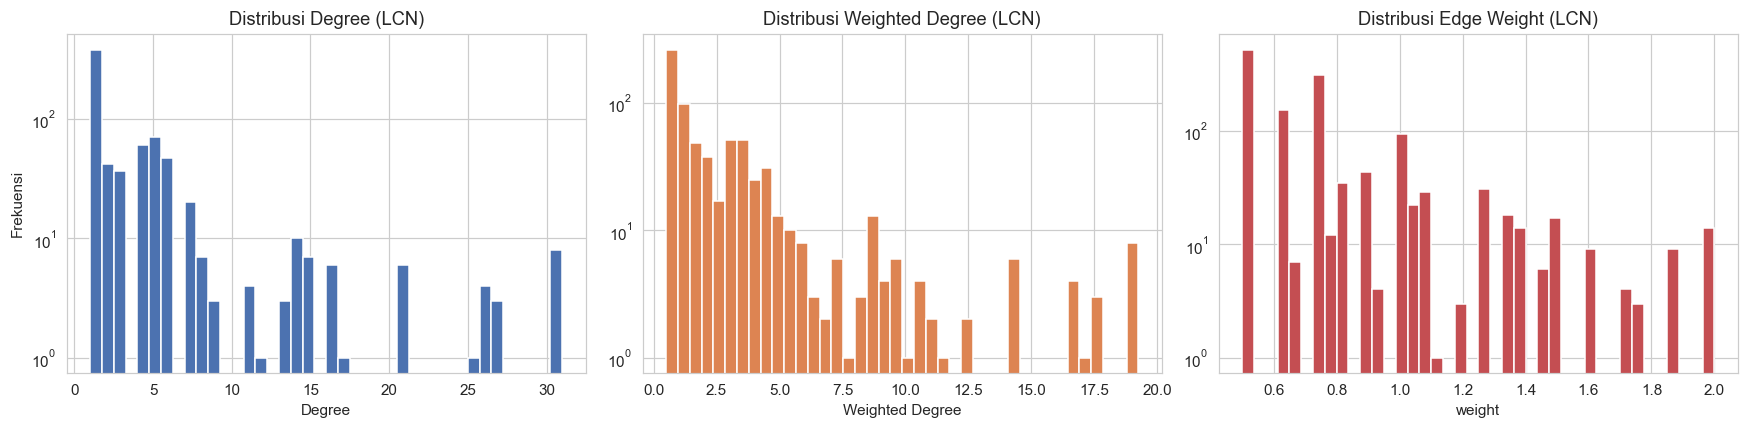

In [68]:
# ══════════════════════════════════════════════════════════════════════════════
# 18.1  Distribusi degree, weighted degree, edge weight
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(lcn_nodes['degree'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribusi Degree (LCN)')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frekuensi')
axes[0].set_yscale('log')

axes[1].hist(lcn_nodes['weighted_degree'], bins=40, color='#DD8452', edgecolor='white')
axes[1].set_title('Distribusi Weighted Degree (LCN)')
axes[1].set_xlabel('Weighted Degree')
axes[1].set_yscale('log')

axes[2].hist(lcn_edges['weight'], bins=40, color='#C44E52', edgecolor='white')
axes[2].set_title('Distribusi Edge Weight (LCN)')
axes[2].set_xlabel('weight')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()


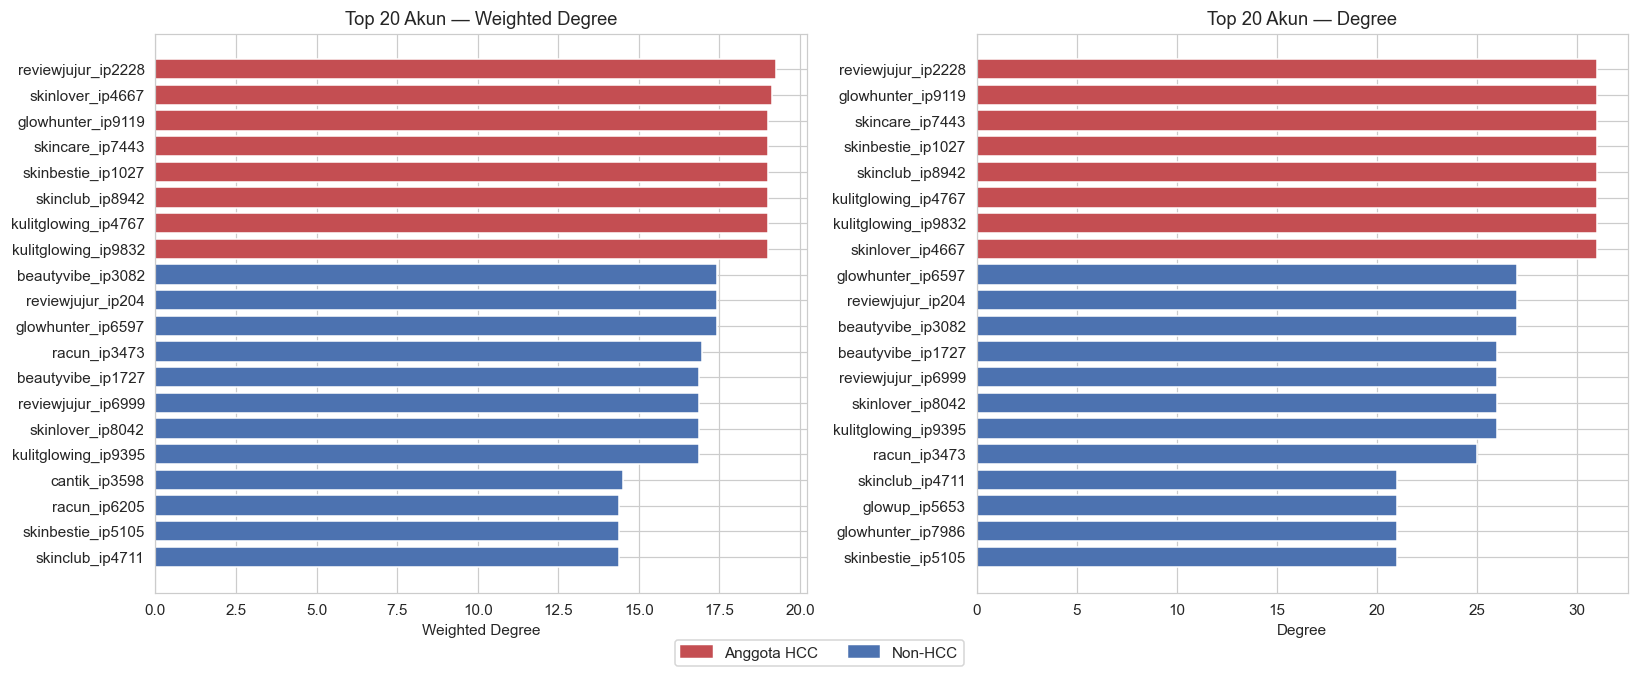

In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# 18.2  Top Coordinated Accounts
# ══════════════════════════════════════════════════════════════════════════════
top20_wd = lcn_nodes.head(20).copy()
top20_d  = lcn_nodes.sort_values('degree', ascending=False).head(20).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Warna: merah = anggota HCC
def bar_colors(df_sub, id_col, hcc_set):
    return ['#C44E52' if r in hcc_set else '#4C72B0'
            for r in df_sub[id_col]]

wd_c = bar_colors(top20_wd, 'id', hcc_members_global)
axes[0].barh(top20_wd['label'][::-1], top20_wd['weighted_degree'][::-1],
             color=wd_c[::-1])
axes[0].set_title('Top 20 Akun — Weighted Degree')
axes[0].set_xlabel('Weighted Degree')

d_c = bar_colors(top20_d, 'id', hcc_members_global)
axes[1].barh(top20_d['label'][::-1], top20_d['degree'][::-1], color=d_c[::-1])
axes[1].set_title('Top 20 Akun — Degree')
axes[1].set_xlabel('Degree')

red_p  = mpatches.Patch(color='#C44E52', label='Anggota HCC')
blue_p = mpatches.Patch(color='#4C72B0', label='Non-HCC')
fig.legend(handles=[red_p, blue_p], loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.show()


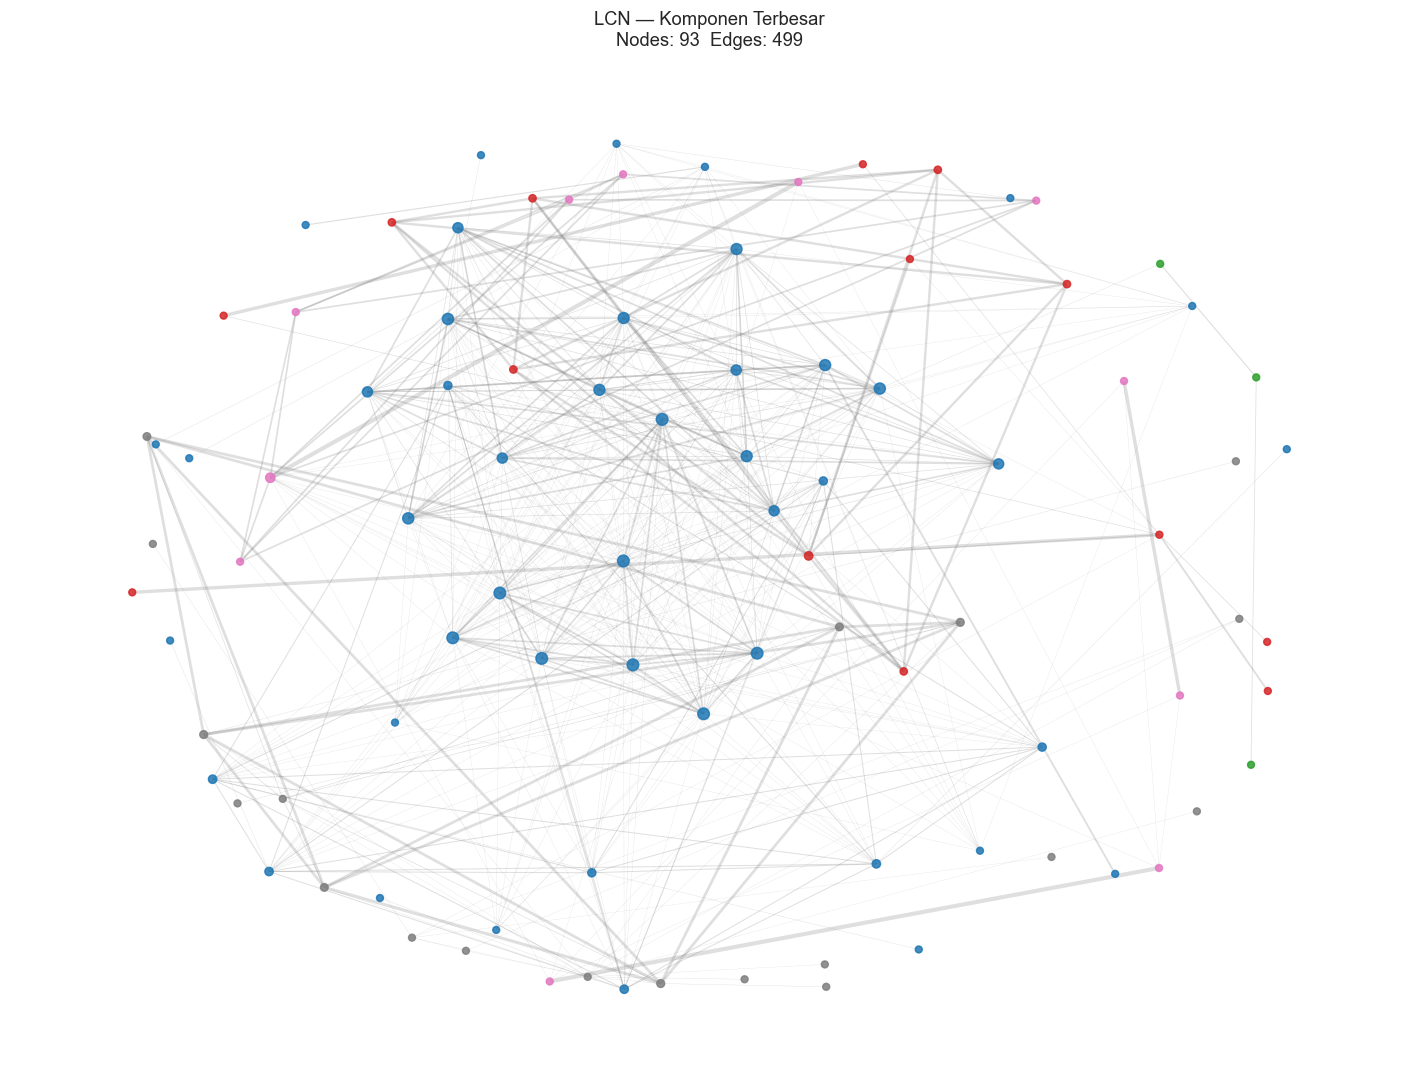

In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# 18.3  Visualisasi LCN Komponen Terbesar
# ══════════════════════════════════════════════════════════════════════════════
MAX_NODES_VIZ = 400

if G_main.number_of_nodes() > MAX_NODES_VIZ:
    top_ids = (lcn_nodes[lcn_nodes['id'].isin(G_main.nodes())]
               .head(MAX_NODES_VIZ)['id'].tolist())
    G_viz   = G_main.subgraph(top_ids).copy()
    suf     = f' (Top-{MAX_NODES_VIZ} Weighted Degree)'
else:
    G_viz   = G_main.copy()
    suf     = ''

# Layout
if G_viz.number_of_nodes() <= 150:
    pos = nx.spring_layout(G_viz, weight='weight', k=1.5, seed=42)
else:
    pos = nx.kamada_kawai_layout(G_viz, weight=None)

nc    = node_colors(G_viz, partition, comm_color)
ew    = np.array([G_viz[u][v].get('weight',1) for u,v in G_viz.edges()], dtype=float)
ew_n  = (0.2 + (ew - ew.min()) / (ew.max() - ew.min() + 1e-9) * 2.5
         if len(ew) > 0 else ew)
ns    = [min(300, max(20, w_degree_g.get(n,1)*3)) for n in G_viz.nodes()]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(G_viz, pos, ax=ax, node_color=nc, node_size=ns, alpha=0.85)
nx.draw_networkx_edges(G_viz, pos, ax=ax, width=ew_n, alpha=0.25, edge_color='gray')
ax.set_title(f'LCN — Komponen Terbesar{suf}\n'
             f'Nodes: {G_viz.number_of_nodes():,}  Edges: {G_viz.number_of_edges():,}',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


Komunitas terbesar: ID=5, anggota=46, edge=386


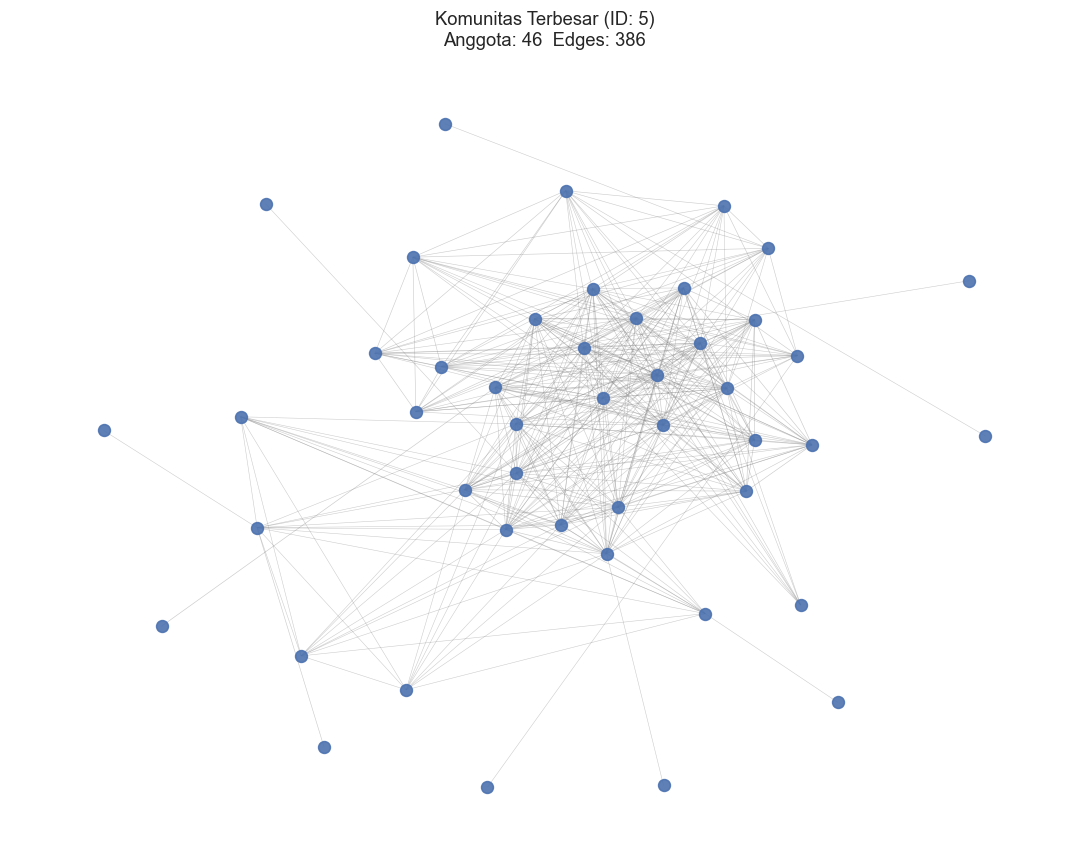

In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# 18.4  Komunitas Terbesar
# ══════════════════════════════════════════════════════════════════════════════
largest_comm_id = comm_size.index[0]
largest_members = [n for n, c in partition.items() if c == largest_comm_id]
G_largest       = G.subgraph(largest_members).copy()

print(f'Komunitas terbesar: ID={largest_comm_id}, '
      f'anggota={len(largest_members)}, '
      f'edge={G_largest.number_of_edges()}')

if G_largest.number_of_nodes() > 0:
    pos_lg = nx.spring_layout(G_largest, seed=42, k=1.2)
    ew_lg  = [G_largest[u][v].get('weight',1) for u,v in G_largest.edges()]

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_nodes(G_largest, pos_lg, ax=ax,
                            node_color='#4C72B0', node_size=60, alpha=0.9)
    nx.draw_networkx_edges(G_largest, pos_lg, ax=ax,
                            width=[0.3 + w*0.12 for w in ew_lg],
                            alpha=0.4, edge_color='gray')
    ax.set_title(f'Komunitas Terbesar (ID: {largest_comm_id})\n'
                 f'Anggota: {G_largest.number_of_nodes()}  '
                 f'Edges: {G_largest.number_of_edges()}', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


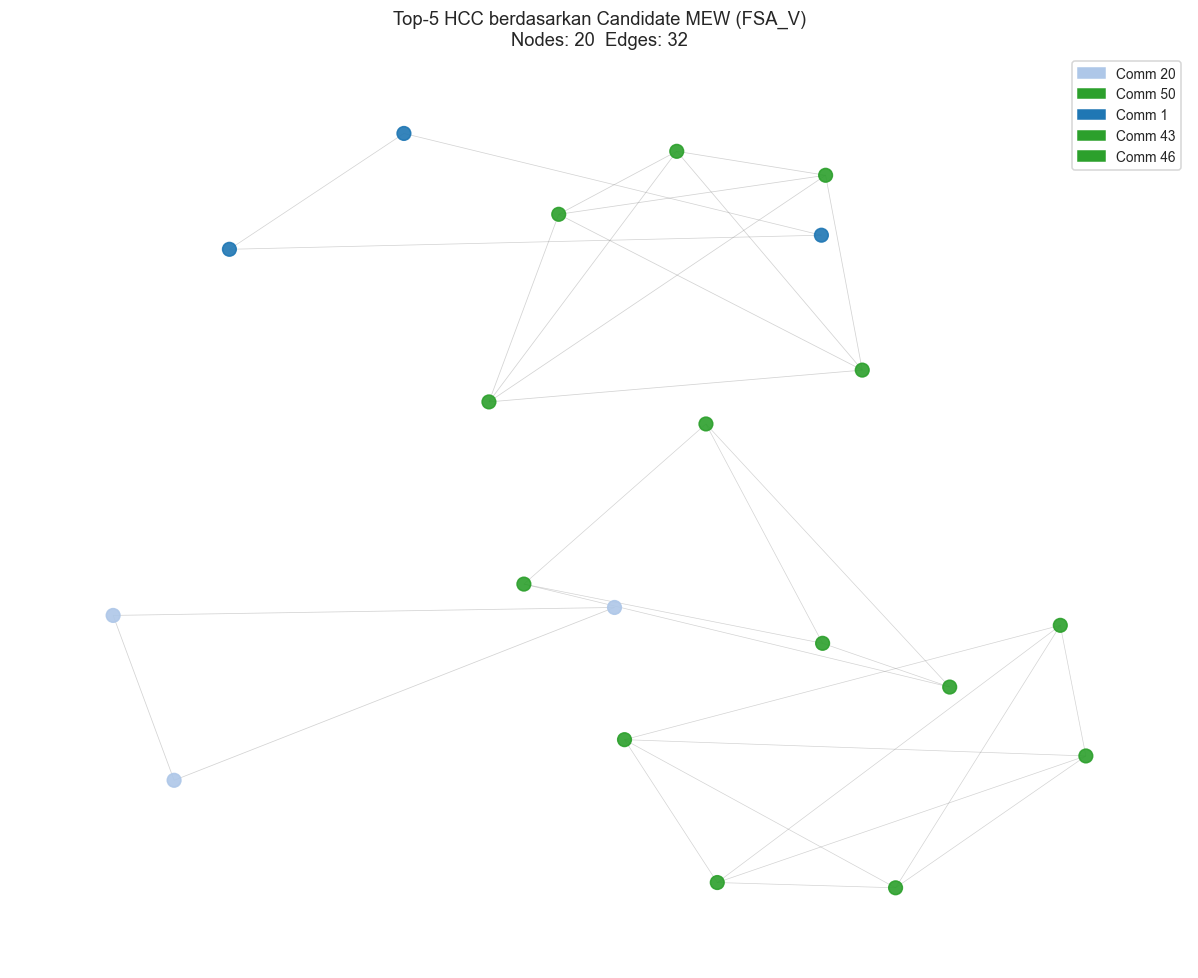

In [72]:
# ═══════════════════════════════════════════════════════════════════════════════════
# 18.5  Top-5 HCC (FSA_V)
# ═══════════════════════════════════════════════════════════════════════════════════
top5_rows = sorted(hcc_list, key=lambda r: r['candidate_mean_weight'], reverse=True)[:5]
top5_ids  = [r['community_id'] for r in top5_rows]

if len(top5_rows) >= 2:
    top5_members = set().union(*(r['candidate_members'] for r in top5_rows))
    G_top5       = G.subgraph(top5_members).copy()
    pos_t5       = nx.spring_layout(G_top5, seed=42, k=1.5)
    ew_t5        = [G_top5[u][v].get('weight',1) for u,v in G_top5.edges()]

    fig, ax = plt.subplots(figsize=(11, 9))
    nx.draw_networkx_nodes(G_top5, pos_t5, ax=ax,
                            node_color=node_colors(G_top5, partition, comm_color),
                            node_size=80, alpha=0.9)
    nx.draw_networkx_edges(G_top5, pos_t5, ax=ax,
                            width=[0.3 + w*0.1 for w in ew_t5],
                            alpha=0.35, edge_color='gray')
    handles = [mpatches.Patch(color=comm_color.get(cid,'#ccc'),
                               label=f'Comm {cid}') for cid in top5_ids]
    ax.legend(handles=handles, loc='upper right', fontsize=9)
    ax.set_title(f'Top-{len(top5_rows)} HCC berdasarkan Candidate MEW (FSA_V)\n'
                 f'Nodes: {G_top5.number_of_nodes()}  Edges: {G_top5.number_of_edges()}',
                 fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
elif len(top5_rows) == 1:
    members = top5_rows[0]['candidate_members']
    G_one   = G.subgraph(members).copy()
    pos_one = nx.spring_layout(G_one, seed=42)
    fig, ax = plt.subplots(figsize=(8, 7))
    nx.draw_networkx(G_one, pos_one, ax=ax, node_size=60, alpha=0.85,
                      node_color='#C44E52', edge_color='gray', width=0.5)
    ax.set_title(f'HCC Komunitas {top5_ids[0]} — {len(members)} anggota')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada komunitas yang memenuhi kriteria HCC (FSA_V) untuk divisualisasikan.')


---

## 19. Temporal Activity Profile (RM1)

**Tujuan:** Menambahkan analisis temporal seperlunya untuk RM1, yaitu membaca kapan aktivitas komentar pada struktur HCC/LCN teramati.

**Cakupan inti:** visual berbasis grafik garis untuk tiga cakupan: seluruh dataset, akun dalam LCN, dan akun dalam HCC. Pola ditampilkan menurut hari dalam pekan, jam lokal, dan kombinasi hari x jam. Analisis brand, sentiment, goal, recurrence rinci, dan Gephi temporal tidak dimasukkan ke bagian inti ini agar RM1 tetap ringkas.

**Zona waktu utama:** `Asia/Jakarta` / WIB.

**Batas interpretasi:** Konsentrasi aktivitas pada hari atau jam tertentu hanya menunjukkan pola waktu komentar yang teramati. Temuan ini tidak membuktikan jadwal kerja, hubungan komersial, koordinasi terencana, ataupun status akun sebagai buzzer.

In [73]:
from __future__ import annotations

import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

BASE_DIR = PROJECT_ROOT
TABLE_DIR = RM1_TEMPORAL_TABLES_DIR
VIS_DIR = RM1_TEMPORAL_VISUALIZATION_DIR
GEPHI_DIR = RM1_TEMPORAL_DIR / "gephi"

COMMENT_SENTIMENT_PATH = RM2_SENTIMENT_FINAL_DIR / "comment_sentiment_v2_observational.csv"
LCN_NODE_PATH = RM1_GEPHI_DIR / "gephi_lcn_nodes.csv"
HCC_NODE_PATH = RM1_GEPHI_DIR / "gephi_hcc_nodes.csv"
FOCAL_STRUCTURE_PATH = RM1_TABLES_DIR / "focal_structures.csv"

ANALYSIS_TIMEZONE = "Asia/Jakarta"
WEEKDAY_ORDER = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
WEEKDAY_NUMBER_TO_NAME = dict(enumerate(WEEKDAY_ORDER, start=1))
TEMPORAL_SCOPES = ["All Dataset", "LCN", "HCC"]
SCOPE_COLORS = {"All Dataset": "#4C78A8", "LCN": "#F58518", "HCC": "#54A24B"}
WEEKDAY_COLORS = {
    "Senin": "#4C78A8", "Selasa": "#F58518", "Rabu": "#E45756", "Kamis": "#72B7B2",
    "Jumat": "#54A24B", "Sabtu": "#B279A2", "Minggu": "#FF9DA6",
}


def _assert_inside_workspace(path: Path) -> Path:
    resolved = path.resolve()
    if resolved != BASE_DIR and BASE_DIR not in resolved.parents:
        raise ValueError(f"Path di luar workspace: {resolved}")
    return resolved


def _reset_output_dir(path: Path) -> None:
    path = _assert_inside_workspace(path)
    if path.exists():
        for child in path.iterdir():
            if child.is_dir():
                shutil.rmtree(child)
            else:
                child.unlink()
    else:
        path.mkdir(parents=True, exist_ok=True)


def _remove_optional_dir(path: Path) -> None:
    path = _assert_inside_workspace(path)
    if path.exists():
        shutil.rmtree(path)


def _weekday_name(number: int) -> str:
    return WEEKDAY_NUMBER_TO_NAME[int(number)]


def _hcc_id_list(series: pd.Series) -> str:
    ids = sorted(pd.unique(series.dropna().astype(int)))
    return ";".join(str(i) for i in ids)


def load_scope_mappings() -> tuple[set[str], dict[str, int], dict[int, int], list[int]]:
    lcn_nodes = pd.read_csv(LCN_NODE_PATH)
    hcc_nodes = pd.read_csv(HCC_NODE_PATH)

    lcn_usernames = set(lcn_nodes["id"].astype(str))
    hcc_nodes["community"] = pd.to_numeric(hcc_nodes["community"], errors="coerce").astype("Int64")
    hcc_nodes = hcc_nodes.dropna(subset=["community"]).copy()
    hcc_nodes["community"] = hcc_nodes["community"].astype(int)

    valid_hcc_ids = sorted(hcc_nodes["community"].unique().tolist())
    if FOCAL_STRUCTURE_PATH.exists():
        focal = pd.read_csv(FOCAL_STRUCTURE_PATH)
        hcc_mask = focal["HCC"].astype(str).str.lower().eq("true")
        focal_ids = set(pd.to_numeric(focal.loc[hcc_mask, "Community"], errors="coerce").dropna().astype(int))
        valid_hcc_ids = sorted(set(valid_hcc_ids) & focal_ids)
        hcc_nodes = hcc_nodes[hcc_nodes["community"].isin(valid_hcc_ids)].copy()

    user_to_hcc = dict(zip(hcc_nodes["id"].astype(str), hcc_nodes["community"].astype(int)))
    community_size = hcc_nodes.groupby("community")["id"].nunique().astype(int).to_dict()
    return lcn_usernames, user_to_hcc, community_size, valid_hcc_ids


def load_temporal_comments(lcn_usernames: set[str], user_to_hcc: dict[str, int]) -> pd.DataFrame:
    usecols = ["comment_id", "username", "video_id", "timestamp"]
    df = pd.read_csv(COMMENT_SENTIMENT_PATH, usecols=usecols, dtype=str)
    df["username"] = df["username"].astype(str)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert(ANALYSIS_TIMEZONE)
    df["has_valid_timestamp"] = df["timestamp_local"].notna()

    df["in_lcn"] = df["username"].isin(lcn_usernames)
    df["hcc_id"] = df["username"].map(user_to_hcc).astype("Int64")
    df["in_hcc"] = df["hcc_id"].notna()

    valid = df["has_valid_timestamp"]
    df.loc[valid, "weekday_number"] = df.loc[valid, "timestamp_local"].dt.weekday + 1
    df.loc[valid, "weekday_name_id"] = df.loc[valid, "weekday_number"].astype(int).map(_weekday_name)
    df.loc[valid, "hour_local"] = df.loc[valid, "timestamp_local"].dt.hour
    df.loc[valid, "date_local"] = df.loc[valid, "timestamp_local"].dt.date.astype(str)
    return df


def make_scope_long(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df["has_valid_timestamp"]].copy()
    frames = [
        valid.assign(scope="All Dataset"),
        valid[valid["in_lcn"]].assign(scope="LCN"),
        valid[valid["in_hcc"]].assign(scope="HCC"),
    ]
    return pd.concat(frames, ignore_index=True)


def _fill_counts(df: pd.DataFrame, count_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in count_cols:
        out[col] = out[col].fillna(0).astype(int)
    return out


def build_scope_weekday_summary(scope_long: pd.DataFrame) -> pd.DataFrame:
    grouped = (scope_long.groupby(["scope", "weekday_number", "weekday_name_id"], dropna=False)
               .agg(n_comments=("comment_id", "count"),
                    n_accounts=("username", "nunique"),
                    n_unique_videos=("video_id", "nunique"))
               .reset_index())
    grid = pd.MultiIndex.from_product(
        [TEMPORAL_SCOPES, range(1, 8)], names=["scope", "weekday_number"]
    ).to_frame(index=False)
    grid["weekday_name_id"] = grid["weekday_number"].map(_weekday_name)
    out = grid.merge(grouped, how="left", on=["scope", "weekday_number", "weekday_name_id"])
    out = _fill_counts(out, ["n_comments", "n_accounts", "n_unique_videos"])
    totals = out.groupby("scope")["n_comments"].transform("sum")
    out["comment_share_within_scope"] = (out["n_comments"] / totals.replace(0, pd.NA) * 100).fillna(0).round(3)
    return out


def build_scope_hour_summary(scope_long: pd.DataFrame) -> pd.DataFrame:
    grouped = (scope_long.groupby(["scope", "hour_local"], dropna=False)
               .agg(n_comments=("comment_id", "count"),
                    n_accounts=("username", "nunique"),
                    n_unique_videos=("video_id", "nunique"))
               .reset_index())
    grid = pd.MultiIndex.from_product(
        [TEMPORAL_SCOPES, range(24)], names=["scope", "hour_local"]
    ).to_frame(index=False)
    out = grid.merge(grouped, how="left", on=["scope", "hour_local"])
    out = _fill_counts(out, ["n_comments", "n_accounts", "n_unique_videos"])
    totals = out.groupby("scope")["n_comments"].transform("sum")
    out["comment_share_within_scope"] = (out["n_comments"] / totals.replace(0, pd.NA) * 100).fillna(0).round(3)
    return out


def build_scope_weekday_hour_summary(scope_long: pd.DataFrame) -> pd.DataFrame:
    grouped = (scope_long.groupby(["scope", "weekday_number", "weekday_name_id", "hour_local"], dropna=False)
               .agg(n_comments=("comment_id", "count"),
                    n_accounts=("username", "nunique"),
                    n_unique_videos=("video_id", "nunique"))
               .reset_index())
    grid = pd.MultiIndex.from_product(
        [TEMPORAL_SCOPES, range(1, 8), range(24)], names=["scope", "weekday_number", "hour_local"]
    ).to_frame(index=False)
    grid["weekday_name_id"] = grid["weekday_number"].map(_weekday_name)
    out = grid.merge(grouped, how="left", on=["scope", "weekday_number", "weekday_name_id", "hour_local"])
    return _fill_counts(out, ["n_comments", "n_accounts", "n_unique_videos"])


def build_hcc_weekday_summary(df: pd.DataFrame, total_hcc: int) -> pd.DataFrame:
    hcc = df[df["has_valid_timestamp"] & df["in_hcc"]].copy()
    grouped = (hcc.groupby(["weekday_number", "weekday_name_id"], dropna=False)
               .agg(n_active_hcc=("hcc_id", "nunique"),
                    n_comments=("comment_id", "count"),
                    n_community_actors=("username", "nunique"),
                    n_unique_videos=("video_id", "nunique"),
                    hcc_ids=("hcc_id", _hcc_id_list))
               .reset_index())
    grid = pd.DataFrame({"weekday_number": range(1, 8)})
    grid["weekday_name_id"] = grid["weekday_number"].map(_weekday_name)
    out = grid.merge(grouped, how="left", on=["weekday_number", "weekday_name_id"])
    out = _fill_counts(out, ["n_active_hcc", "n_comments", "n_community_actors", "n_unique_videos"])
    out["hcc_ids"] = out["hcc_ids"].fillna("")
    out["active_hcc_share"] = (out["n_active_hcc"] / max(total_hcc, 1) * 100).round(3)
    return out


def build_hcc_weekday_hour_matrix(df: pd.DataFrame) -> pd.DataFrame:
    hcc = df[df["has_valid_timestamp"] & df["in_hcc"]].copy()
    grouped = (hcc.groupby(["weekday_number", "hour_local"], dropna=False)
               .agg(n_active_hcc=("hcc_id", "nunique"),
                    n_comments=("comment_id", "count"),
                    n_community_actors=("username", "nunique"),
                    n_unique_videos=("video_id", "nunique"),
                    hcc_ids=("hcc_id", _hcc_id_list))
               .reset_index())
    grid = pd.MultiIndex.from_product(
        [range(1, 8), range(24)], names=["weekday_number", "hour_local"]
    ).to_frame(index=False)
    grid["weekday_name_id"] = grid["weekday_number"].map(_weekday_name)
    out = grid.merge(grouped, how="left", on=["weekday_number", "hour_local"])
    out = _fill_counts(out, ["n_active_hcc", "n_comments", "n_community_actors", "n_unique_videos"])
    out["hcc_ids"] = out["hcc_ids"].fillna("")
    return out[["weekday_number", "weekday_name_id", "hour_local", "n_active_hcc",
                "n_comments", "n_community_actors", "n_unique_videos", "hcc_ids"]]


def build_hcc_temporal_profile(df: pd.DataFrame, community_size: dict[int, int]) -> pd.DataFrame:
    hcc = df[df["has_valid_timestamp"] & df["in_hcc"]].copy()
    if hcc.empty:
        return pd.DataFrame(columns=[
            "hcc_id", "community_size", "n_comments", "n_community_actors", "n_unique_videos",
            "n_active_weekdays", "n_active_hours", "dominant_weekday_by_comments",
            "dominant_weekday_comments", "weekday_concentration_score", "weekend_comment_share"
        ])

    base = (hcc.groupby("hcc_id")
            .agg(n_comments=("comment_id", "count"),
                 n_community_actors=("username", "nunique"),
                 n_unique_videos=("video_id", "nunique"),
                 n_active_weekdays=("weekday_number", "nunique"),
                 n_active_hours=("hour_local", "nunique"))
            .reset_index())

    weekday_counts = (hcc.groupby(["hcc_id", "weekday_number", "weekday_name_id"])
                      .size().rename("weekday_comments").reset_index())
    dominant = (weekday_counts.sort_values(["hcc_id", "weekday_comments", "weekday_number"],
                                           ascending=[True, False, True])
                .drop_duplicates("hcc_id")
                .rename(columns={"weekday_name_id": "dominant_weekday_by_comments",
                                 "weekday_comments": "dominant_weekday_comments"}))
    weekend = hcc.assign(is_weekend=hcc["weekday_number"].isin([6, 7]).astype(int))
    weekend = weekend.groupby("hcc_id")["is_weekend"].mean().mul(100).round(3).rename("weekend_comment_share")

    out = base.merge(dominant[["hcc_id", "dominant_weekday_by_comments", "dominant_weekday_comments"]], on="hcc_id")
    out = out.merge(weekend, on="hcc_id", how="left")
    out["community_size"] = out["hcc_id"].astype(int).map(community_size).fillna(0).astype(int)
    out["weekday_concentration_score"] = (out["dominant_weekday_comments"] / out["n_comments"]).round(3)
    return out[["hcc_id", "community_size", "n_comments", "n_community_actors", "n_unique_videos",
                "n_active_weekdays", "n_active_hours", "dominant_weekday_by_comments",
                "dominant_weekday_comments", "weekday_concentration_score", "weekend_comment_share"]]


def write_method_and_quality(df: pd.DataFrame,
                             lcn_usernames: set[str],
                             valid_hcc_ids: list[int]) -> tuple[pd.DataFrame, pd.DataFrame]:
    quality = pd.DataFrame([
        {"metric": "analysis_timezone", "value": ANALYSIS_TIMEZONE, "notes": "Output utama menggunakan WIB."},
        {"metric": "total_comments", "value": len(df), "notes": "Semua komentar observasional pada comment_sentiment_v2_observational.csv."},
        {"metric": "valid_timestamp_comments", "value": int(df["has_valid_timestamp"].sum()), "notes": "Timestamp berhasil dibaca."},
        {"metric": "invalid_timestamp_comments", "value": int((~df["has_valid_timestamp"]).sum()), "notes": "Dikeluarkan dari agregasi temporal."},
        {"metric": "lcn_node_count", "value": len(lcn_usernames), "notes": "Jumlah akun pada gephi_lcn_nodes.csv."},
        {"metric": "lcn_comments", "value": int(df["in_lcn"].sum()), "notes": "Komentar dari akun yang masuk LCN."},
        {"metric": "hcc_comments", "value": int(df["in_hcc"].sum()), "notes": "Komentar dari akun yang masuk HCC."},
        {"metric": "valid_hcc_count", "value": len(valid_hcc_ids), "notes": "Jumlah HCC valid dari node Gephi dan focal_structures.csv."},
    ])

    params = pd.DataFrame([
        {"parameter": "analysis_scope", "value": "RM1 temporal essentials by All Dataset, LCN, and HCC"},
        {"parameter": "timezone", "value": ANALYSIS_TIMEZONE},
        {"parameter": "all_dataset_definition", "value": "semua komentar dengan timestamp valid"},
        {"parameter": "lcn_definition", "value": "username ada pada output/gephi/gephi_lcn_nodes.csv"},
        {"parameter": "hcc_definition", "value": "username ada pada output/gephi/gephi_hcc_nodes.csv"},
        {"parameter": "weekday_order", "value": ";".join(WEEKDAY_ORDER)},
        {"parameter": "visualization_type", "value": "line charts"},
        {"parameter": "omitted_from_compact_version", "value": "brand-context temporal, sentiment/goal temporal, recurrence detail, Gephi temporal export"},
    ])
    quality.to_csv(TABLE_DIR / "temporal_data_quality_audit.csv", index=False, encoding="utf-8-sig")
    params.to_csv(TABLE_DIR / "temporal_method_parameters.csv", index=False, encoding="utf-8-sig")
    return quality, params


def _style_axis(ax, title: str, xlabel: str, ylabel: str) -> None:
    ax.set_title(title, fontsize=12.5, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)


def save_visualizations(scope_weekday: pd.DataFrame,
                        scope_hour: pd.DataFrame,
                        scope_weekday_hour: pd.DataFrame,
                        hcc_weekday: pd.DataFrame) -> None:
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True)
    for ax, scope in zip(axes, TEMPORAL_SCOPES):
        data = scope_weekday[scope_weekday["scope"].eq(scope)].sort_values("weekday_number")
        ax.plot(data["weekday_number"], data["n_comments"], marker="o", linewidth=2.4,
                color=SCOPE_COLORS[scope])
        ax.set_xticks(range(1, 8))
        ax.set_xticklabels(WEEKDAY_ORDER, rotation=30, ha="right")
        _style_axis(ax, f"{scope}\nN={int(data['n_comments'].sum()):,} komentar", "Hari (WIB)", "Jumlah komentar")
    fig.suptitle("Aktivitas Komentar per Hari: All Dataset, LCN, dan HCC", fontsize=15, fontweight="bold", y=1.04)
    fig.tight_layout()
    fig.savefig(VIS_DIR / "temporal_scope_weekday_lines.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True)
    for ax, scope in zip(axes, TEMPORAL_SCOPES):
        data = scope_hour[scope_hour["scope"].eq(scope)].sort_values("hour_local")
        ax.plot(data["hour_local"], data["n_comments"], marker="o", linewidth=2.2,
                color=SCOPE_COLORS[scope])
        ax.set_xticks(range(0, 24, 2))
        _style_axis(ax, f"{scope}\nN={int(data['n_comments'].sum()):,} komentar", "Jam lokal (WIB)", "Jumlah komentar")
    fig.suptitle("Aktivitas Komentar per Jam: All Dataset, LCN, dan HCC", fontsize=15, fontweight="bold", y=1.04)
    fig.tight_layout()
    fig.savefig(VIS_DIR / "temporal_scope_hour_lines.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5.6), sharex=True)
    for ax, scope in zip(axes, TEMPORAL_SCOPES):
        scope_data = scope_weekday_hour[scope_weekday_hour["scope"].eq(scope)].copy()
        for weekday in WEEKDAY_ORDER:
            data = scope_data[scope_data["weekday_name_id"].eq(weekday)].sort_values("hour_local")
            ax.plot(data["hour_local"], data["n_comments"], linewidth=1.8, marker="o", markersize=3.2,
                    color=WEEKDAY_COLORS[weekday], label=weekday)
        ax.set_xticks(range(0, 24, 2))
        _style_axis(ax, scope, "Jam lokal (WIB)", "Jumlah komentar")
    axes[-1].legend(title="Hari", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Aktivitas Komentar menurut Hari x Jam: All Dataset, LCN, dan HCC", fontsize=15, fontweight="bold", y=1.04)
    fig.tight_layout()
    fig.savefig(VIS_DIR / "temporal_scope_weekday_hour_lines.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(hcc_weekday["weekday_number"], hcc_weekday["n_active_hcc"], marker="o", linewidth=2.4,
            color=SCOPE_COLORS["HCC"])
    for _, row in hcc_weekday.iterrows():
        ax.text(row["weekday_number"], row["n_active_hcc"] + 0.3, str(int(row["n_active_hcc"])),
                ha="center", va="bottom", fontsize=10)
    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(WEEKDAY_ORDER, rotation=30, ha="right")
    _style_axis(ax, "Jumlah HCC Aktif Unik per Hari", "Hari (WIB)", "Jumlah HCC aktif unik")
    fig.tight_layout()
    fig.savefig(VIS_DIR / "active_hcc_by_weekday_line.png", dpi=180, bbox_inches="tight")
    plt.close(fig)


def run_pipeline() -> dict[str, object]:
    _reset_output_dir(TABLE_DIR)
    _reset_output_dir(VIS_DIR)
    _remove_optional_dir(GEPHI_DIR)

    lcn_usernames, user_to_hcc, community_size, valid_hcc_ids = load_scope_mappings()
    comments = load_temporal_comments(lcn_usernames, user_to_hcc)
    scope_long = make_scope_long(comments)

    quality, params = write_method_and_quality(comments, lcn_usernames, valid_hcc_ids)
    scope_weekday = build_scope_weekday_summary(scope_long)
    scope_hour = build_scope_hour_summary(scope_long)
    scope_weekday_hour = build_scope_weekday_hour_summary(scope_long)
    hcc_weekday = build_hcc_weekday_summary(comments, total_hcc=len(valid_hcc_ids))
    hcc_hour = build_hcc_weekday_hour_matrix(comments)
    hcc_profile = build_hcc_temporal_profile(comments, community_size)

    scope_weekday.to_csv(TABLE_DIR / "temporal_scope_weekday_summary.csv", index=False, encoding="utf-8-sig")
    scope_hour.to_csv(TABLE_DIR / "temporal_scope_hour_summary.csv", index=False, encoding="utf-8-sig")
    scope_weekday_hour.to_csv(TABLE_DIR / "temporal_scope_weekday_hour_summary.csv", index=False, encoding="utf-8-sig")
    hcc_weekday.to_csv(TABLE_DIR / "hcc_weekday_summary.csv", index=False, encoding="utf-8-sig")
    hcc_hour.to_csv(TABLE_DIR / "hcc_weekday_hour_matrix.csv", index=False, encoding="utf-8-sig")
    hcc_profile.to_csv(TABLE_DIR / "hcc_temporal_profile.csv", index=False, encoding="utf-8-sig")
    save_visualizations(scope_weekday, scope_hour, scope_weekday_hour, hcc_weekday)

    dominant_rows = []
    for scope in TEMPORAL_SCOPES:
        day_row = (scope_weekday[scope_weekday["scope"].eq(scope)]
                   .sort_values(["n_comments", "weekday_number"], ascending=[False, True]).iloc[0])
        hour_row = (scope_hour[scope_hour["scope"].eq(scope)]
                    .sort_values(["n_comments", "hour_local"], ascending=[False, True]).iloc[0])
        dominant_rows.extend([
            {"metric": f"{scope}_dominant_weekday_by_comments", "value": day_row["weekday_name_id"], "notes": int(day_row["n_comments"])},
            {"metric": f"{scope}_peak_hour_by_comments", "value": int(hour_row["hour_local"]), "notes": int(hour_row["n_comments"])},
        ])
    dominant_by_hcc = hcc_weekday.sort_values(["n_active_hcc", "weekday_number"], ascending=[False, True]).iloc[0]
    dominant_rows.append({"metric": "HCC_dominant_weekday_by_active_hcc", "value": dominant_by_hcc["weekday_name_id"], "notes": int(dominant_by_hcc["n_active_hcc"])})

    n_tables_created = len(list(TABLE_DIR.glob("*.csv"))) + 1  # + temporal_final_summary.csv
    n_visualizations_created = len(list(VIS_DIR.glob("*.png")))
    final_summary = pd.DataFrame(dominant_rows + [
        {"metric": "n_tables_created", "value": n_tables_created, "notes": "Versi ringkas RM1."},
        {"metric": "n_visualizations_created", "value": n_visualizations_created, "notes": "PNG-only line charts."},
    ])
    final_summary.to_csv(TABLE_DIR / "temporal_final_summary.csv", index=False, encoding="utf-8-sig")

    print("=== RM1 TEMPORAL ACTIVITY PROFILE (RINGKAS) ===")
    print(f"Zona waktu utama                  : {ANALYSIS_TIMEZONE} / WIB")
    print(f"Komentar valid timestamp          : {int(comments['has_valid_timestamp'].sum()):,} dari {len(comments):,}")
    print(f"Komentar All Dataset / LCN / HCC  : {len(comments[comments['has_valid_timestamp']]):,} / {int((comments['has_valid_timestamp'] & comments['in_lcn']).sum()):,} / {int((comments['has_valid_timestamp'] & comments['in_hcc']).sum()):,}")
    print(f"Jumlah HCC valid                  : {len(valid_hcc_ids):,}")
    for scope in TEMPORAL_SCOPES:
        day = final_summary.loc[final_summary["metric"].eq(f"{scope}_dominant_weekday_by_comments")].iloc[0]
        hour = final_summary.loc[final_summary["metric"].eq(f"{scope}_peak_hour_by_comments")].iloc[0]
        print(f"{scope:<12} hari puncak / jam puncak : {day['value']} ({int(day['notes']):,}) / {int(hour['value']):02d}:00 ({int(hour['notes']):,})")
    print(f"Hari tertinggi by HCC aktif unik  : {dominant_by_hcc['weekday_name_id']} ({int(dominant_by_hcc['n_active_hcc']):,} HCC)")
    print(f"Tabel dibuat                      : {n_tables_created:,}")
    print(f"Visualisasi dibuat                : {n_visualizations_created:,}")
    print("Catatan: hasil temporal bersifat deskriptif dan tidak membuktikan afiliasi, jadwal kerja, atau koordinasi komersial.")

    return {
        "comments": comments,
        "scope_long": scope_long,
        "quality": quality,
        "parameters": params,
        "temporal_scope_weekday_summary": scope_weekday,
        "temporal_scope_hour_summary": scope_hour,
        "temporal_scope_weekday_hour_summary": scope_weekday_hour,
        "hcc_weekday_summary": hcc_weekday,
        "hcc_weekday_hour_matrix": hcc_hour,
        "hcc_temporal_profile": hcc_profile,
        "final_summary": final_summary,
    }


### 19.1 Jalankan Analisis Temporal RM1

Cell ini menghasilkan output ringkas di `output/rm1_temporal/tables/` dan visualisasi PNG berupa grafik garis di `output/rm1_temporal/visualisasi/`. Output lama yang tidak termasuk cakupan inti RM1 temporal dibersihkan saat pipeline berjalan.

In [74]:
results_rm1_temporal = run_pipeline()


=== RM1 TEMPORAL ACTIVITY PROFILE (RINGKAS) ===
Zona waktu utama                  : Asia/Jakarta / WIB
Komentar valid timestamp          : 33,004 dari 33,063
Komentar All Dataset / LCN / HCC  : 33,004 / 2,049 / 886
Jumlah HCC valid                  : 42
All Dataset  hari puncak / jam puncak : Selasa (6,489) / 10:00 (2,090)
LCN          hari puncak / jam puncak : Selasa (351) / 17:00 (139)
HCC          hari puncak / jam puncak : Kamis (160) / 17:00 (78)
Hari tertinggi by HCC aktif unik  : Kamis (28 HCC)
Tabel dibuat                      : 9
Visualisasi dibuat                : 4
Catatan: hasil temporal bersifat deskriptif dan tidak membuktikan afiliasi, jadwal kerja, atau koordinasi komersial.


---
## 20. Interpretation Guide

**Tujuan:** Menjelaskan cara membaca dan menginterpretasikan hasil analisis.
**Catatan:** Panduan ini bersifat metodologis. Hasil analisis hanya mengidentifikasi *evidence koordinasi*, *komunitas koordinatif*, dan *focal structures* -- **tidak menyimpulkan adanya astroturfing, buzzer, atau bot**.

---

### 19.1 Evidence Koordinasi (Pembangun LCN)

| Evidence | Definisi | Interpretasi |
|----------|----------|-------------|
| **Co-conv** | Pasangan akun muncul bersama pada ≥2 video berbeda | Kemunculan bersama yang berulang dapat mengindikasikan pola partisipasi yang tidak acak |
| **Co-reply** | Hubungan reply A→B terulang pada ≥2 video berbeda (bobot = `shared_videos`) | Keterulangan interaksi langsung lintas video menunjukkan pola relasi yang konsisten |
| **Co-temporal** | Pasangan akun berkomentar dalam window ≤`CO_TEMPORAL_WINDOW_MIN` menit (dikalibrasi dari distribusi data, lihat Section 7) pada ≥3 video berbeda | Keterulangan aktivitas temporal berdekatan di banyak video menunjukkan pola koordinasi waktu |

---

### 19.2 Normalisasi dan Bobot LCN

Ketiga evidence pembangun LCN dinormalisasi menggunakan Min-Max Normalization sebelum digabung
menggunakan penjumlahan sederhana, sesuai Eq. (1) Weber & Neumann (2021):

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

$$\text{weight} = co\_conv\_norm + co\_reply\_norm + co\_temporal\_norm$$

- `weight = 3.0` : pasangan akun memiliki semua tiga evidence pada nilai maksimum
- `weight = 1.0` : pasangan akun memiliki satu evidence pada nilai maksimum, atau kombinasi evidence lebih rendah
- Co-hashtag dan Co-similarity **tidak** termasuk dalam formula ini dan **tidak** mempengaruhi weight, edge, maupun Community Detection. Co-Mention dipensiunkan dari analisis aktif (lihat 19.11) dan sejak awal juga tidak pernah menjadi bagian formula ini.
- **`weight` (Final Weight) TIDAK memfilter LCN.** LCN memuat seluruh edge hasil Evidence Filtering apa pun nilai `weight`-nya (lihat Section 10). `weight` hanya dipakai sebagai bobot edge pada Louvain Community Detection (Section 11) dan sebagai dasar perhitungan Mean Edge Weight pada FSA_V (Section 12).

---

### 19.3 Metrik Jaringan

| Metrik | Definisi | Relevansi |
|--------|----------|-----------|
| **Degree** | Jumlah tetangga langsung dalam LCN | Luas jangkauan koordinasi |
| **Weighted Degree** | Jumlah total bobot edge yang terhubung | Intensitas kumulatif koordinasi |
| **Betweenness Centrality** | Proporsi jalur terpendek yang melewati node | Peran sebagai penghubung (*bridge*) antar komunitas |
| **Density** | Rasio edge aktual / edge maksimum komunitas | Kerapatan koneksi internal komunitas |

Komunitas dideteksi dengan algoritma Louvain (Blondel et al., 2008), yang memaksimalkan *modularity* -- ukuran seberapa padat koneksi internal komunitas dibandingkan jaringan acak.

---

### 19.4 Kriteria HCC -- FSA_V (Algorithm 2, Weber & Neumann 2021)

**HCC (Highly Coordinating Communities)** diekstraksi menggunakan **FSA_V**, algoritma non-rekursif
yang dijelaskan eksplisit oleh Weber & Neumann (2021, Algorithm 2) sebagai varian dari Focal Structures
Analysis (Sen et al., 2016):

1. Hitung **Global Mean Edge Weight** (`g_mean`) atas seluruh edge LCN (satu kali, sebelum iterasi
   per komunitas).
2. Untuk setiap komunitas hasil Louvain, bangun satu kandidat `h = (Vh, Eh)` mulai dari edge terberat
   di komunitas tersebut.
3. Tumbuhkan `h` secara iteratif dengan menambahkan edge terberat berikutnya yang bertetangga
   dengannya, **selama** Mean Edge Weight (MEW) kandidat tidak turun di bawah `g_mean` **dan** tidak
   turun di bawah `MEW_lama x theta`.
4. Kandidat final diterima sebagai HCC **hanya jika** MEW akhirnya `> g_mean`.

Parameter `theta = 0.3` (nilai yang sama dipakai Weber & Neumann pada eksperimen FSA_V mereka).
Komunitas tanpa edge internal (mis. node terisolasi hasil Louvain) tidak pernah menghasilkan
kandidat -- ini konsekuensi struktural langsung dari algoritma (tidak ada edge untuk memulai `h`),
bukan ambang batas buatan.

**Tidak ada** ranking, tidak ada parameter "ambil N komunitas teratas", tidak ada rekursi, dan tidak
ada penggabungan (*stitching*) antar kandidat -- jumlah HCC murni ditentukan oleh data, sesuai
metodologi paper apa adanya. Anggota HCC (`Vh`) bisa jadi merupakan **subset** dari komunitas Louvain
induknya, karena pertumbuhan kandidat dapat berhenti sebelum menyerap seluruh anggota komunitas.

**FSA** (Sen et al., 2016; Weber & Neumann, 2021) merangkum hasil ekstraksi ini -- ukuran kandidat,
Candidate Mean Edge Weight, dan status penerimaan -- untuk mengidentifikasi *focal structures*: subgraf
dengan koordinasi internal paling menonjol. **FSA_V bukan algoritma deteksi komunitas** -- ia beroperasi
di atas komunitas yang sudah dihasilkan Louvain (Section 11).

---

### 19.5 Threshold Filtering

Threshold `MIN_CO_CONV`, `MIN_CO_REPLY`, dan `MIN_CO_TEMPORAL` (Evidence Filtering, Section 9)
mengikuti distribusi empiris evidence dan merupakan proses seleksi utama edge LCN. **LCN tidak
memakai threshold Final Weight apa pun** -- seluruh edge hasil Evidence Filtering dipertahankan
(lihat Section 10). Parameter `theta` pada FSA_V (Section 12) **bukan** ambang batas edge
(`edge_weight > theta`) -- `theta` mengatur seberapa besar Mean Edge Weight kandidat boleh menurun
selama pertumbuhan (`MEW_baru < MEW_lama x theta`) sebelum pertumbuhan kandidat dihentikan.
Penerimaan akhir sebagai HCC ditentukan oleh perbandingan terhadap Global Mean Edge Weight
(`g_mean`), bukan oleh `theta` secara langsung.

---

### 19.6 Community Coordination Score (Section 15)

$$\text{CommunityScore} = \frac{CoConv + CoReply + CoTemporal + CoHashtag + CoSimilarity}{5}$$

Kelima skor evidence dinormalisasi (Min-Max, [0, 1]) sebelum dirata-ratakan. **Co-Mention tidak lagi
disertakan** dalam formula ini per keputusan metodologis terbaru (lihat Section 16.2 dan 19.11) --
sebelumnya formula ini memakai rata-rata enam skor termasuk CoMention; sekarang rata-rata lima skor.
Skor ini **tidak digunakan untuk membangun ulang LCN** -- hanya untuk mengkarakterisasi, membandingkan,
dan membantu interpretasi HCC yang telah diperoleh melalui Community Detection dan FSA_V.

---

### 19.7 Community Characterization (Section 16)

| Evidence | Cakupan | Parameter | Status |
|----------|---------|-----------|--------|
| **Co-hashtag** | Hashtag metadata video yang dikomentari anggota HCC -- **asosiasi konteks brand/video**, bukan bukti koordinasi langsung | Hashtag umum (fyp, viral, skincare, dll.) dikecualikan | Aktif |
| **Auto brand label** (Section 16.1.3) | Label brand HCC otomatis dari skor hashtag brand (`BRAND_HASHTAG_LEXICON`), murni data-driven | `top_brand_share` ≥0.60 → label brand tunggal; jika tidak, `Mixed_2_Brands`/`Mixed_3plus_Brands`/`Not identified` | Aktif (baru) |
| **Co-mention** | Akun/kreator yang disebut pada video yang dikomentari anggota HCC | -- | **Deprecated** -- tidak lagi dihitung ulang/dicetak, tidak masuk Community Coordination Score (19.6) |
| **Co-similarity** | Kesamaan narasi teks komentar (TF-IDF **char 5-gram** + cosine similarity, ala Weber & Neumann 2021) | Akun HCC dengan teks bersih ≥5 karakter; ringkasan per HCC & per brand | Aktif (metodologi diperbarui -- lihat Section 16.3, sebelumnya word 1-2 gram) |
| **Copypasta candidates** (Section 16.4) | Komentar identik/hampir identik antar akun dalam satu HCC | Exact = `normalized_comment` sama dari ≥2 akun; near = cosine ≥0.85 | Aktif (baru) — disebut sebagai *kandidat*, bukan bukti kampanye pasti |

Seluruhnya bersifat deskriptif dan tidak digunakan untuk membangun jaringan atau mempengaruhi
LCN/Community Detection/FSA_V. Lihat 19.11 untuk model interpretasi tiga lapis.

---

### 19.8 Atribut Edge & Node Gephi

Export Gephi (Section 17) **disederhanakan** agar ringkas untuk visualisasi -- detail lengkap tetap ada
di `output/tables/` (lihat markdown Section 17). Kolom final:

- `gephi_lcn_edges.csv`: `source`, `target`, `co_conv_weight`, `co_reply_weight`, `co_temporal_weight`,
  `norm_co_conv`, `norm_co_reply`, `norm_co_temporal`, `final_weight`, `n_evidence`, `co_hashtag`
- `gephi_hcc_edges.csv`: `source`, `target`, `weight`, `n_evidence`, `co_conv`, `co_reply`, `co_temporal`,
  `co_hashtag`, `co_similarity_char5`
- `gephi_lcn_nodes.csv`: `id`, `label`, `degree`, `weighted_degree`, `betweenness`, `community`,
  `brand_label_auto` (`"Non-HCC"` untuk node yang bukan anggota HCC manapun)
- `gephi_hcc_nodes.csv`: `id`, `label`, `degree`, `weighted_degree`, `betweenness`, `community`,
  `primary_brand`, `brand_label_auto`, `brand_combo`, `brand_confidence`, `narrative_similarity_level`

**Dihapus dari export Gephi** (bukan dihapus dari analisis -- tetap lengkap di `output/tables/`):
`co_mention` (deprecated, lihat 16.2 & 19.11, tidak lagi ditulis ke file Gephi mana pun), `co_similarity`
(word 1-2 gram lama, digantikan `co_similarity_char5`), `brand_color_hex`, `top_brand_share`,
`avg_cosine_similarity_hcc`, `median_cosine_similarity_hcc`, `max_cosine_similarity_hcc`,
`similar_pair_ratio_070`, `similar_pair_ratio_085` (detail lengkap ada di
`hcc_brand_profile_auto.csv`/`hcc_cosimilarity_summary.csv`).

- `co_conv_weight`/`co_reply_weight`/`co_temporal_weight`, `norm_co_conv`/`norm_co_reply`/`norm_co_temporal`,
  `final_weight` -- evidence pembangun LCN (lihat 19.1-19.2); `final_weight` disimpan sebagai atribut,
  **bukan filter** -- LCN memuat seluruh edge apa pun nilai `final_weight`-nya
- `co_hashtag` -- jumlah hashtag yang sama antara kedua akun pada video yang dikomentari; `0` jika tidak ada kesamaan
- `co_similarity_char5` -- cosine similarity char 5-gram ala Weber & Neumann (Section 16.3), dihitung
  khusus untuk akun HCC; `NaN` jika salah satu akun tidak punya teks bersih yang cukup

Untuk pewarnaan Gephi, gunakan kolom `brand_label_auto` (Appearance → Nodes → Partition →
`brand_label_auto`) -- warna **tidak** diekspor sebagai kolom CSV, ditentukan langsung di Gephi.
**Jangan** menjalankan modularity ulang di Gephi -- label brand sudah ditentukan otomatis dari hashtag
metadata video (Section 16.1.3). Atribut non-`final_weight` di atas hanya untuk filter/styling -- tidak
membentuk edge baru maupun mengubah `final_weight`, dan tidak mengubah struktur HCC/LCN manapun.

---

### 19.9 Panduan Import ke Gephi

1. **Gephi → File → Import Spreadsheet** → pilih `gephi_lcn_edges.csv` → *Edge Table* (LCN,
   dipakai untuk analisis SNA utama)
2. **Gephi → File → Import Spreadsheet** → pilih `gephi_lcn_nodes.csv` → *Node Table*
3. **Layout:** `ForceAtlas2` (dengan `LinLog Mode`, weight = `final_weight`) atau `Fruchterman Reingold`
4. **Node size:** mapped dari `weighted_degree`
5. **Node color:** Appearance → Nodes → Partition → `community` (struktural) **atau**
   `brand_label_auto` (konteks brand) -- **jangan** menjalankan modularity ulang di Gephi untuk
   mendapatkan pengelompokan brand
6. **Edge thickness:** mapped dari `final_weight`
7. **Filter/warna tambahan (opsional):** gunakan `co_hashtag` (LCN & HCC) atau `co_similarity_char5`
   (khusus HCC) sebagai atribut filter/*partition* di Gephi
8. Ulangi langkah 1-7 dengan `gephi_hcc_edges.csv` dan `gephi_hcc_nodes.csv` untuk jaringan HCC terpisah
   (hasil ekstraksi FSA_V dari LCN) -- node table HCC juga memuat `narrative_similarity_level`
   (Section 16.3) yang bisa dipakai sebagai filter/warna tambahan.

---

### 19.10 Batasan Analisis

- Analisis ini bersifat **deskriptif-eksploratif** -- mengidentifikasi *pola*, bukan membuktikan *niat* atau *koordinasi yang disengaja*
- Pola koordinasi yang terdeteksi dapat bersifat organik (pengguna aktif, fans produk, grup diskusi informal)
- Algoritma Louvain bersifat stokastik -- hasil komunitas dapat sedikit berbeda antar run (gunakan `seed=42` untuk reproduksibilitas)
- Kandidat copypasta (Section 16.4) dan narrative similarity (Section 16.3) adalah indikasi kesamaan teks,
  bukan bukti niat atau kampanye terkoordinasi yang disengaja -- lihat 19.11 untuk model interpretasi final

---

### 19.11 Model Interpretasi Final (Tiga Lapisan)

Pipeline ini memisahkan tiga lapisan analisis:
1. LCN/FSA_V = koordinasi struktural berbasis perilaku.
2. Hashtag metadata video = asosiasi konteks brand/video.
3. Co-Similarity komentar = kesamaan narasi antar akun.

Dengan demikian, HCC tidak langsung disebut sebagai bukti astroturfing. HCC menunjukkan indikasi
koordinasi struktural. Brand label menunjukkan konteks video yang dikomentari. Co-Similarity
menunjukkan apakah akun-akun dalam HCC juga menyampaikan narasi komentar yang mirip.

**Catatan:** Co-Mention dihapus dari analisis aktif karena tidak informatif pada dataset TikTok ini dan
tidak menjadi dasar interpretasi utama.

*(Kolom `co_mention` tidak lagi ditulis ke file Gephi mana pun (lihat 19.8) -- export Gephi telah
disederhanakan agar fokus untuk visualisasi; evidence co-mention mentah tetap dihitung secara internal
di Section 17 tapi tidak diekspor ke CSV apa pun. Ringkasan scope di Cell 0 di awal notebook telah
diperbarui agar konsisten dengan penghapusan Co-Mention di atas.)*